#Tecnológico de Costa Rica

> Agregar bloque entrecomillado



***IC-6200 / Inteligencia Artificial***

**Proyecto Programado I — Machine Learning**

---

## 4.5.2 Regresión Logística

En esta sección se implementan **dos modelos de Regresión Logística** aplicados a datasets distintos:

- **Modelo 1:** Students Performance — Predicción de si un estudiante aprueba matemáticas
- **Modelo 2:** Wine Quality (White) — Predicción de si un vino es de alta calidad

La Regresión Logística es un algoritmo de clasificación supervisado que utiliza la **función sigmoide** para transformar la combinación lineal de características en una probabilidad entre 0 y 1:

$$\hat{y} = g(z) = \frac{1}{1 + e^{-z}}$$

donde $z = x_1 w_1 + x_2 w_2 + \cdots + x_n w_n$

El modelo clasifica la instancia como positiva si $\hat{y} \geq 0.5$, y como negativa en caso contrario.

---
## Librerías


In [336]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

from google.colab import drive

# Preprocesamiento y selección de modelos
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score

# Algoritmos de Machine Learning
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor, NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

# Clustering jerárquico
from scipy.cluster.hierarchy import dendrogram, linkage

# Métricas de Evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)

# Configuración global
RANDOM_STATE = 42
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

---

# MODELO 1 — Students Performance

## Descripción del problema

**Dataset:** Students Performance in Exams  
**Fuente:** [Kaggle - Students Performance](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)  
**Observaciones:** 1000  
**Features:** 8

**Variable objetivo (target):** `pass_math` — variable binaria creada a partir del puntaje de matemáticas:  
- `1` → Aprobado (math score ≥ 60)  
- `0` → Reprobado (math score < 60)

**Variables predictoras utilizadas:**
- `gender` — género del estudiante
- `race/ethnicity` — grupo étnico
- `parental level of education` — nivel de educación de los padres
- `lunch` — tipo de almuerzo (indicador socioeconómico)
- `test preparation course` — si completó un curso de preparación
- `reading score` — puntaje en lectura
- `writing score` — puntaje en escritura

## 1. Carga y exploración inicial

In [337]:
drive.mount('/content/drive')
df_students = pd.read_csv("/content/drive/MyDrive/AI(Data set)/ProyectoData/StudentsPerformance.csv")
drive.flush_and_unmount()

total_antes = len(df_students)
df_students.drop_duplicates(inplace=True)
total_despues = len(df_students)
print(f"Registros eliminados por duplicidad: {total_antes - total_despues}")

nulos = df_students.isnull().sum().sum()

if nulos == 0:
  print("No hay valores nulos")
else:
  print(f"Atención: Se encontraron {nulos} valores nulos.")


print(f'Dimensiones: {df_students.shape}')
print(f'\nPrimeras filas:')
df_students.head()



Mounted at /content/drive
Registros eliminados por duplicidad: 0
No hay valores nulos
Dimensiones: (1000, 8)

Primeras filas:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [338]:
df_students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [339]:
# Estadísticas descriptivas de las variables numéricas
df_students.describe().round(2)

,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


In [340]:
# Verificación de valores faltantes
print('Valores faltantes por columna:')
print(df_students.isnull().sum())

Valores faltantes por columna:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


## 2. Análisis Exploratorio (EDA)

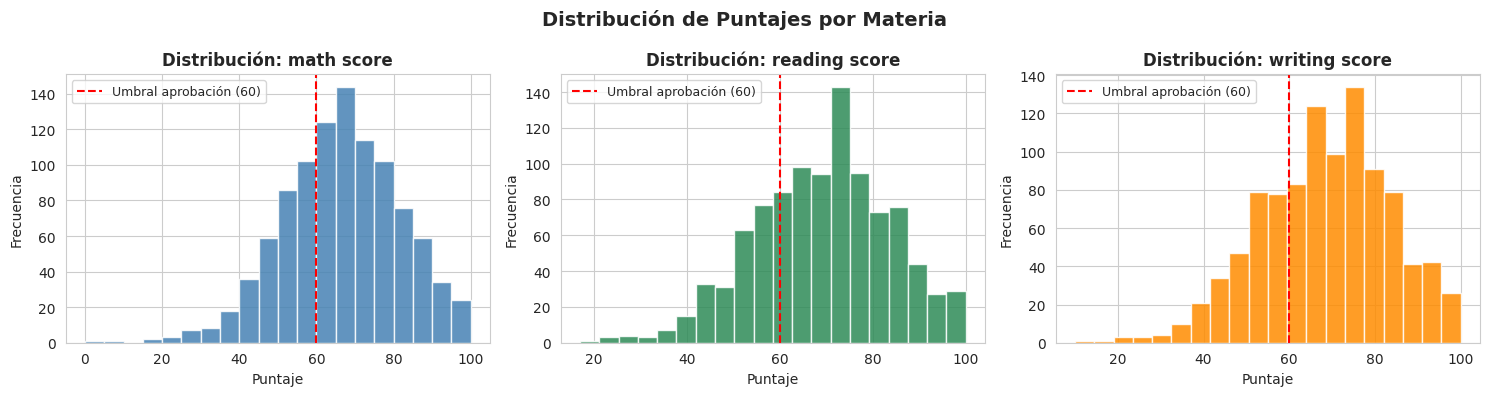

In [341]:
# Distribución de puntajes por materia
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes,
                          ['math score', 'reading score', 'writing score'],
                          ['steelblue', 'seagreen', 'darkorange']):
    ax.hist(df_students[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(60, color='red', linestyle='--', linewidth=1.5, label='Umbral aprobación (60)')
    ax.set_title(f'Distribución: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Puntaje')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de Puntajes por Materia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

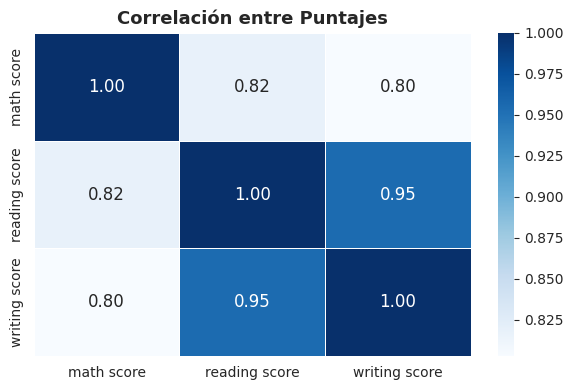

Los tres puntajes tienen correlación alta entre sí (>0.80),
lo que sugiere que el rendimiento general es consistente por estudiante.


In [342]:
# Correlación entre puntajes numéricos
corr = df_students[['math score', 'reading score', 'writing score']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, annot_kws={'size': 12})
plt.title('Correlación entre Puntajes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Los tres puntajes tienen correlación alta entre sí (>0.80),')
print('lo que sugiere que el rendimiento general es consistente por estudiante.')

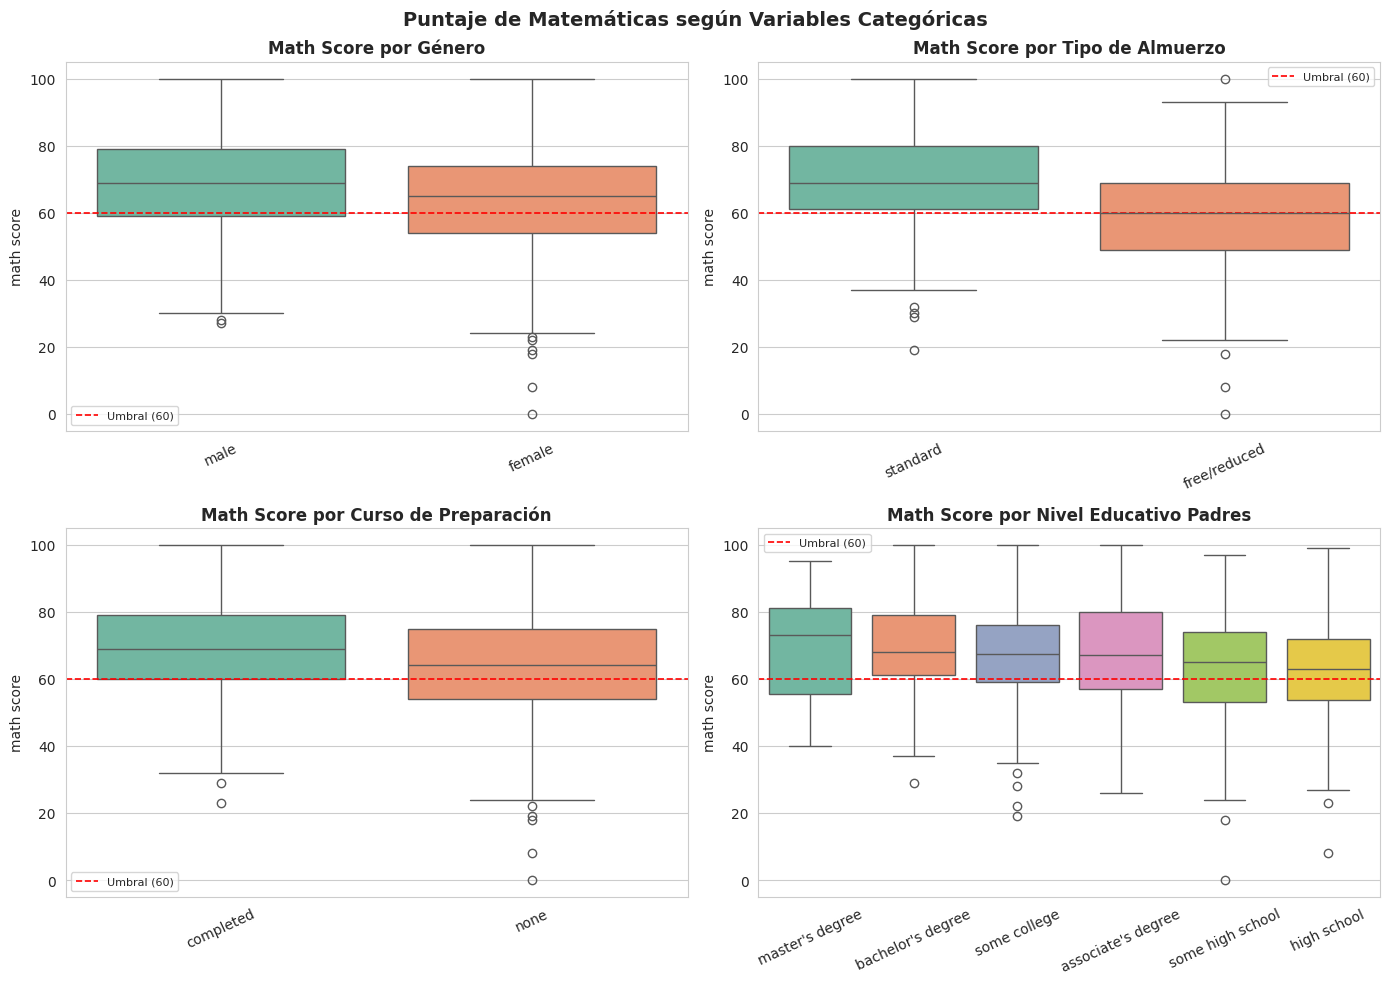

In [343]:
# Impacto de variables categóricas en el puntaje de matemáticas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cat_vars = [
    ('gender', 'Género'),
    ('lunch', 'Tipo de Almuerzo'),
    ('test preparation course', 'Curso de Preparación'),
    ('parental level of education', 'Nivel Educativo Padres')
]

for ax, (col, titulo) in zip(axes.flatten(), cat_vars):
    order = df_students.groupby(col)['math score'].median().sort_values(ascending=False).index
    sns.boxplot(data=df_students, x=col, y='math score', ax=ax,
                order=order, palette='Set2')
    ax.axhline(60, color='red', linestyle='--', linewidth=1.2, label='Umbral (60)')
    ax.set_title(f'Math Score por {titulo}', fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(fontsize=8)

plt.suptitle('Puntaje de Matemáticas según Variables Categóricas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento

Distribución de la variable objetivo:
pass_math
1    677
0    323
Name: count, dtype: int64

Porcentaje aprobados: 67.7%


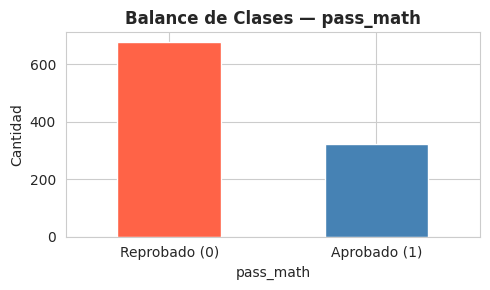

In [344]:
# 1 Crear la variable objetivo binaria
# Se considera aprobado si math score >= 60

df_s = df_students.copy()
df_s['pass_math'] = (df_s['math score'] >= 60).astype(int)

print('Distribución de la variable objetivo:')
print(df_s['pass_math'].value_counts())
print(f"\nPorcentaje aprobados: {df_s['pass_math'].mean()*100:.1f}%")

# Visualizar balance de clases
plt.figure(figsize=(5, 3))
df_s['pass_math'].value_counts().plot(kind='bar', color=['tomato', 'steelblue'],
                                       edgecolor='white', rot=0)
plt.xticks([0, 1], ['Reprobado (0)', 'Aprobado (1)'])
plt.title('Balance de Clases — pass_math', fontweight='bold')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

In [345]:
# 2 Codificación de variables categóricas
# Se usa LabelEncoder para variables binarias y
# get_dummies (One-Hot Encoding) para las multi-valor

# Variables binarias → LabelEncoder
le = LabelEncoder()
df_s['gender_enc'] = le.fit_transform(df_s['gender'])                            # female=0, male=1
df_s['lunch_enc'] = le.fit_transform(df_s['lunch'])                              # free/reduced=0, standard=1
df_s['prep_enc'] = le.fit_transform(df_s['test preparation course'])             # completed=0, none=1

# Variable multi-valor → One-Hot Encoding
edu_dummies = pd.get_dummies(df_s['parental level of education'], prefix='edu', drop_first=True)
race_dummies = pd.get_dummies(df_s['race/ethnicity'], prefix='race', drop_first=True)

# Unir todo
df_s = pd.concat([df_s, edu_dummies, race_dummies], axis=1)

print('Variables categóricas codificadas correctamente')
print(f'Columnas resultantes: {df_s.shape[1]}')

Variables categóricas codificadas correctamente
Columnas resultantes: 21


In [346]:
# 3 Selección de features y separación X, y
# Excluir los puntajes (math/reading/writing) crudos


feature_cols = (['gender_enc', 'lunch_enc', 'prep_enc',
                 'reading score', 'writing score'] +
                list(edu_dummies.columns) +
                list(race_dummies.columns))

X = df_s[feature_cols]
y = df_s['pass_math']

print(f'Features seleccionadas: {len(feature_cols)}')
print(feature_cols)

Features seleccionadas: 14
['gender_enc', 'lunch_enc', 'prep_enc', 'reading score', 'writing score', "edu_bachelor's degree", 'edu_high school', "edu_master's degree", 'edu_some college', 'edu_some high school', 'race_group B', 'race_group C', 'race_group D', 'race_group E']


In [347]:
# 4: Escalado de variables numéricas
# StandardScaler normaliza a media=0, desv=1
# Es importante para la convergencia del gradiente

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Escalado aplicado (StandardScaler)')
X_scaled.describe().round(2)

Escalado aplicado (StandardScaler)


,gender_enc,lunch_enc,prep_enc,reading score,writing score,edu_bachelor's degree,edu_high school,edu_master's degree,edu_some college,edu_some high school,race_group B,race_group C,race_group D,race_group E
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.96,-1.35,-1.34,-3.57,-3.82,-0.37,-0.49,-0.25,-0.54,-0.47,-0.48,-0.68,-0.60,-0.40
25%,-0.96,-1.35,-1.34,-0.70,-0.68,-0.37,-0.49,-0.25,-0.54,-0.47,-0.48,-0.68,-0.60,-0.40
50%,-0.96,0.74,0.75,0.06,0.06,-0.37,-0.49,-0.25,-0.54,-0.47,-0.48,-0.68,-0.60,-0.40
75%,1.04,0.74,0.75,0.67,0.72,-0.37,-0.49,-0.25,-0.54,-0.47,-0.48,1.46,1.68,-0.40
max,1.04,0.74,0.75,2.11,2.10,2.73,2.03,3.99,1.85,2.14,2.06,1.46,1.68,2.48


In [348]:
# PASO 5: División Train / Test (70% / 30%)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')
print(f'\nBalance en train — Aprobados: {y_train.mean()*100:.1f}%')
print(f'Balance en test  — Aprobados: {y_test.mean()*100:.1f}%')

Entrenamiento: 700 muestras
Prueba:        300 muestras

Balance en train — Aprobados: 67.7%
Balance en test  — Aprobados: 67.7%


## 4. Entrenamiento del Modelo

In [349]:
# Instanciar y entrenar el modelo de Regresión Logística
# max_iter=1000
model_students = LogisticRegression(max_iter=1000, random_state=42)
model_students.fit(X_train, y_train)

print('Modelo entrenado exitosamente ')
print(f'\nCoeficientes del modelo (pesos wi):')
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficiente': model_students.coef_[0]
}).sort_values('Coeficiente', ascending=False)

print(coef_df.to_string(index=False))

Modelo entrenado exitosamente 

Coeficientes del modelo (pesos wi):
              Feature  Coeficiente
        writing score     2.881715
           gender_enc     1.935462
        reading score     1.483572
             prep_enc     0.629668
         race_group E     0.486563
            lunch_enc     0.319434
     edu_some college     0.169281
 edu_some high school     0.154329
         race_group B     0.130462
         race_group D     0.115078
      edu_high school     0.112767
         race_group C     0.050801
edu_bachelor's degree    -0.030760
  edu_master's degree    -0.136994


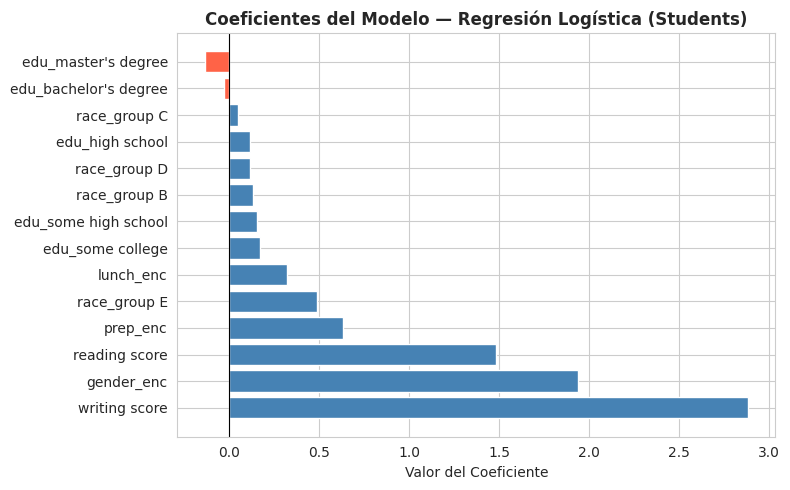

Coeficientes positivos aumentan la probabilidad de aprobar.
Coeficientes negativos la disminuyen.


In [350]:
# Visualizar importancia de los coeficientes
plt.figure(figsize=(8, 5))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coeficiente']]
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes del Modelo — Regresión Logística (Students)', fontweight='bold')
plt.xlabel('Valor del Coeficiente')
plt.tight_layout()
plt.show()

print('Coeficientes positivos aumentan la probabilidad de aprobar.')
print('Coeficientes negativos la disminuyen.')

## 5. Predicciones y Evaluación del Modelo

In [351]:
# Predicciones
y_pred_students = model_students.predict(X_test)
y_prob_students = model_students.predict_proba(X_test)[:, 1]  # probabilidad clase positiva

# Métricas principales
acc  = accuracy_score(y_test, y_pred_students)
prec = precision_score(y_test, y_pred_students)
rec  = recall_score(y_test, y_pred_students)
f1   = f1_score(y_test, y_pred_students)
auc  = roc_auc_score(y_test, y_prob_students)

print('=' * 45)
print('   MÉTRICAS DE EVALUACIÓN — Students')
print('=' * 45)
print(f'  Accuracy  (Exactitud):   {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision (Precisión):   {prec:.4f}')
print(f'  Recall    (Sensibilidad):{rec:.4f}')
print(f'  F1-Score:                {f1:.4f}')
print(f'  AUC-ROC:                 {auc:.4f}')
print('=' * 45)

   MÉTRICAS DE EVALUACIÓN — Students
  Accuracy  (Exactitud):   0.9000  (90.00%)
  Precision (Precisión):   0.9023
  Recall    (Sensibilidad):0.9557
  F1-Score:                0.9282
  AUC-ROC:                 0.9638


In [352]:
# Reporte de clasificación completo
print('Reporte de Clasificación Completo:')
print(classification_report(y_test, y_pred_students,
                             target_names=['Reprobado (0)', 'Aprobado (1)']))

Reporte de Clasificación Completo:
               precision    recall  f1-score   support

Reprobado (0)       0.89      0.78      0.84        97
 Aprobado (1)       0.90      0.96      0.93       203

     accuracy                           0.90       300
    macro avg       0.90      0.87      0.88       300
 weighted avg       0.90      0.90      0.90       300



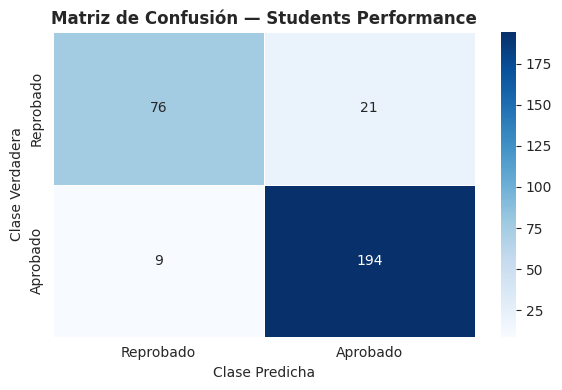

Verdaderos Negativos (TN): 76   Reprobados correctamente identificados
Falsos Positivos     (FP): 21   Reprobados clasificados como Aprobados
Falsos Negativos     (FN): 9   Aprobados clasificados como Reprobados
Verdaderos Positivos (TP): 194   Aprobados correctamente identificados


In [353]:
# Matriz de Confusión
matrix_s = confusion_matrix(y_test, y_pred_students)

plt.figure(figsize=(6, 4))
sns.heatmap(matrix_s, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Reprobado', 'Aprobado'],
            yticklabels=['Reprobado', 'Aprobado'],
            linewidths=0.5)
plt.title('Matriz de Confusión — Students Performance', fontweight='bold')
plt.ylabel('Clase Verdadera')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = matrix_s.ravel()
print(f'Verdaderos Negativos (TN): {tn}   Reprobados correctamente identificados')
print(f'Falsos Positivos     (FP): {fp}   Reprobados clasificados como Aprobados')
print(f'Falsos Negativos     (FN): {fn}   Aprobados clasificados como Reprobados')
print(f'Verdaderos Positivos (TP): {tp}   Aprobados correctamente identificados')

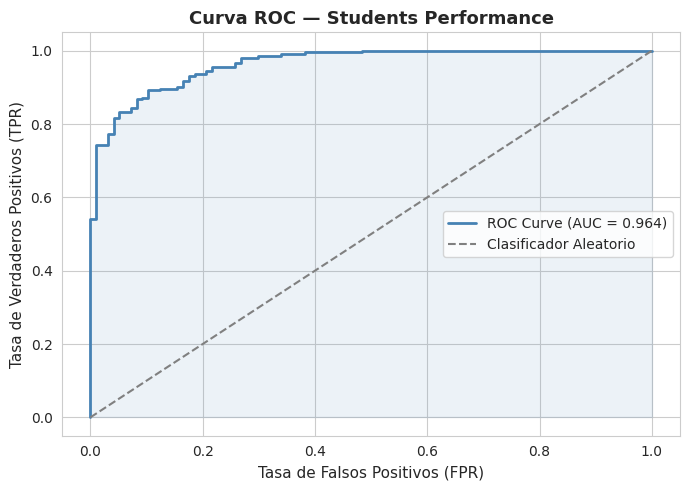

AUC = 0.964: El modelo tiene una excelente capacidad discriminativa.
Un AUC cercano a 1.0 indica que el modelo distingue muy bien entre clases.


In [354]:
# Curva ROC
fpr_s, tpr_s, _ = roc_curve(y_test, y_prob_students)

plt.figure(figsize=(7, 5))
plt.plot(fpr_s, tpr_s, color='steelblue', lw=2,
         label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Clasificador Aleatorio')
plt.fill_between(fpr_s, tpr_s, alpha=0.10, color='steelblue')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
plt.title('Curva ROC — Students Performance', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'AUC = {auc:.3f}: El modelo tiene una excelente capacidad discriminativa.')
print('Un AUC cercano a 1.0 indica que el modelo distingue muy bien entre clases.')

---

# MODELO 2 — Wine Quality (White)

## Descripción del problema

**Dataset:** Wine Quality — White Wine  
**Fuente:** [Kaggle - Wine Quality UCI](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)  
**Observaciones:** 4898  
**Features:** 12

**Variable objetivo (target):** `high_quality` — variable binaria derivada de la columna `quality`:  
- `1` → Alta calidad (quality ≥ 7)  
- `0` → Calidad estándar (quality < 7)

**Variables predictoras:** todas las propiedades fisicoquímicas del vino (acidez, azúcar residual, alcohol, etc.)

## 1. Carga y exploración inicial

In [355]:
drive.mount('/content/drive')

df_wine = pd.read_csv("/content/drive/MyDrive/AI(Data set)/ProyectoData/winequality-white.csv", sep=';')
drive.flush_and_unmount()

# Eliminación de duplicados
antes_duplicados = len(df_wine)
df_wine.drop_duplicates(inplace=True)
print(f"Eliminados {antes_duplicados - len(df_wine)} registros duplicados.")

# Eliminación de valores nulos
antes_nulos = len(df_wine)
df_wine.dropna(inplace=True)
print(f"Eliminados {antes_nulos - len(df_wine)} registros con valores nulos.")

scaler = StandardScaler()

print('Datos cargados y Google Drive desmontado.')
print(f'Dimensiones: {df_wine.shape}')
print(f'\nPrimeras filas:')
df_wine.head()

Mounted at /content/drive
Eliminados 937 registros duplicados.
Eliminados 0 registros con valores nulos.
Datos cargados y Google Drive desmontado.
Dimensiones: (3961, 12)

Primeras filas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6


In [356]:
# Información general
df_wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3961 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         3961 non-null   float64
 1   volatile acidity      3961 non-null   float64
 2   citric acid           3961 non-null   float64
 3   residual sugar        3961 non-null   float64
 4   chlorides             3961 non-null   float64
 5   free sulfur dioxide   3961 non-null   float64
 6   total sulfur dioxide  3961 non-null   float64
 7   density               3961 non-null   float64
 8   pH                    3961 non-null   float64
 9   sulphates             3961 non-null   float64
 10  alcohol               3961 non-null   float64
 11  quality               3961 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 402.3 KB


In [357]:
# Estadísticas descriptivas
df_wine.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,3961.000,3961.000,3961.000,3961.000,3961.000,3961.000,3961.000,3961.000,3961.000,3961.000,3961.000,3961.000
mean,6.839,0.281,0.334,5.915,0.046,34.889,137.194,0.994,3.195,0.490,10.589,5.855
std,0.867,0.103,0.122,4.862,0.023,17.210,43.129,0.003,0.152,0.114,1.217,0.891
min,3.800,0.080,0.000,0.600,0.009,2.000,9.000,0.987,2.720,0.220,8.000,3.000
25%,6.300,0.210,0.270,1.600,0.035,23.000,106.000,0.992,3.090,0.410,9.500,5.000
50%,6.800,0.260,0.320,4.700,0.042,33.000,133.000,0.994,3.180,0.480,10.400,6.000
75%,7.300,0.330,0.390,8.900,0.050,45.000,166.000,0.996,3.290,0.550,11.400,6.000
max,14.200,1.100,1.660,65.800,0.346,289.000,440.000,1.039,3.820,1.080,14.200,9.000


In [358]:
# Valores faltantes
print('Valores faltantes por columna:')
print(df_wine.isnull().sum())
print('\n→ No hay valores faltantes. El dataset está completo.')

Valores faltantes por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

→ No hay valores faltantes. El dataset está completo.


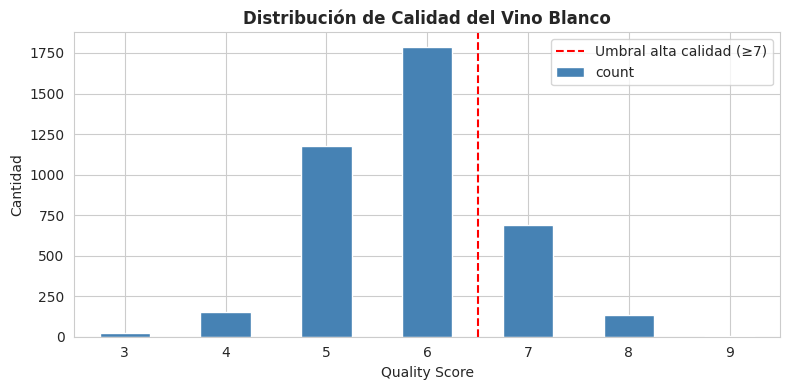

Distribución de valores:
quality
3      20
4     153
5    1175
6    1788
7     689
8     131
9       5
Name: count, dtype: int64


In [359]:
# Distribución de la variable quality
plt.figure(figsize=(8, 4))
df_wine['quality'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='white', rot=0
)
plt.axvline(x=3.5, color='red', linestyle='--', linewidth=1.5, label='Umbral alta calidad (≥7)')
plt.title('Distribución de Calidad del Vino Blanco', fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Cantidad')
plt.legend()
plt.tight_layout()
plt.show()

print('Distribución de valores:')
print(df_wine['quality'].value_counts().sort_index())

## 2. Análisis Exploratorio (EDA)

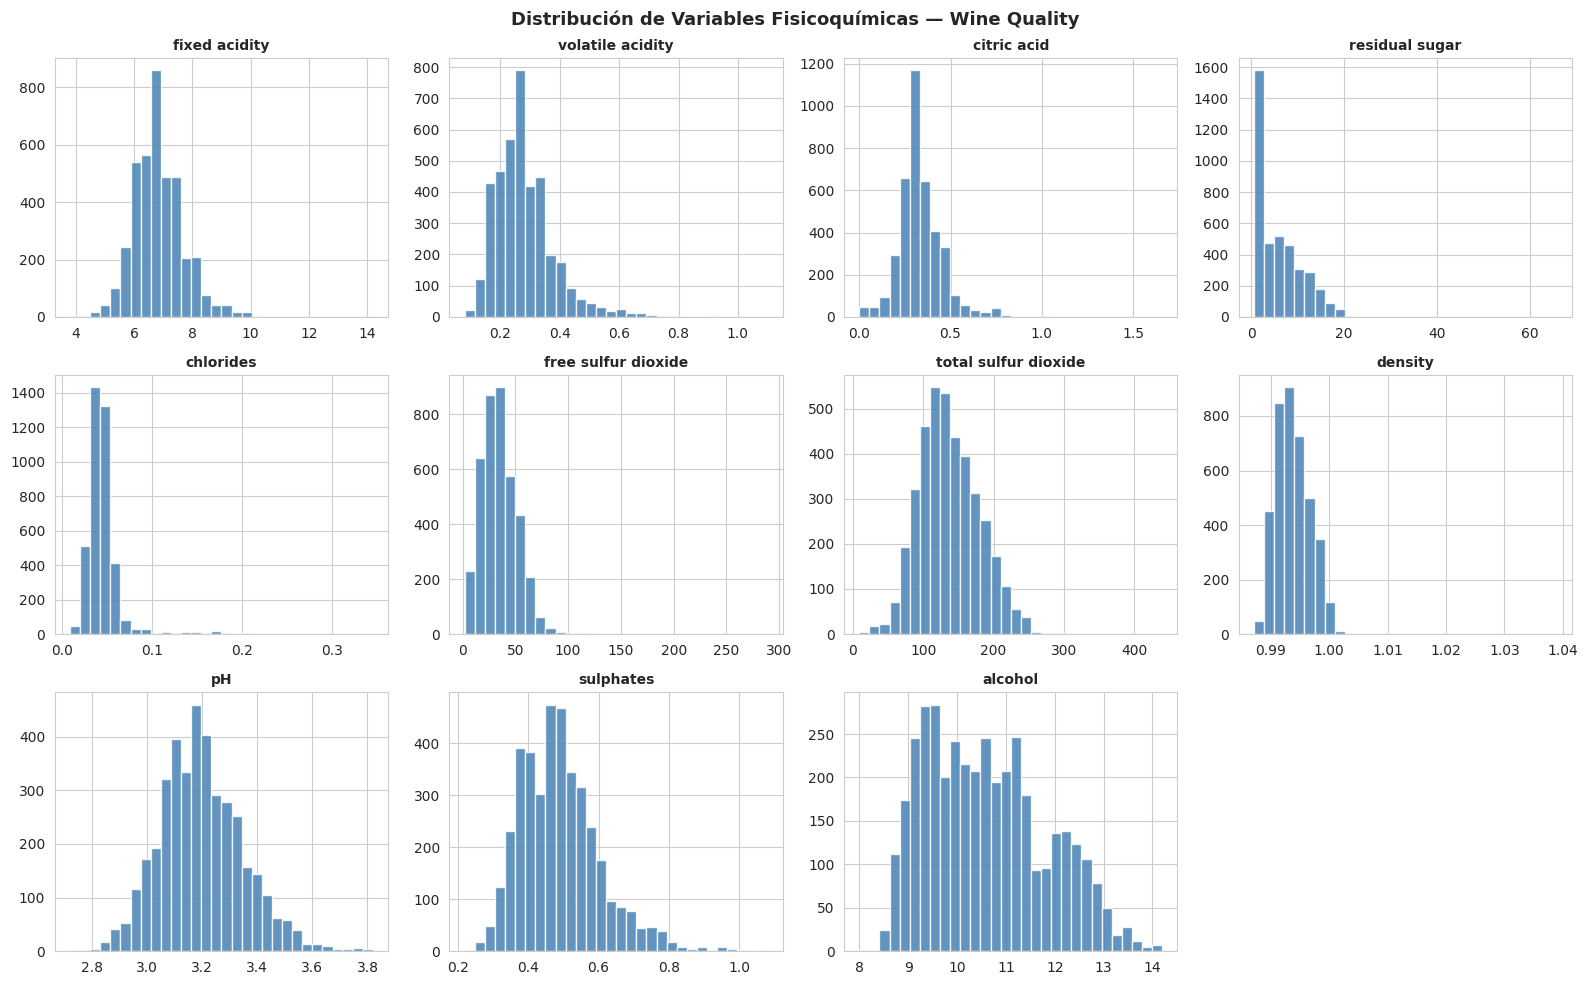

In [360]:
# Distribución de variables fisicoquímicas
features_wine = [c for c in df_wine.columns if c != 'quality']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(features_wine):
    axes[i].hist(df_wine[feat], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

axes[-1].set_visible(False)

plt.suptitle('Distribución de Variables Fisicoquímicas — Wine Quality',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

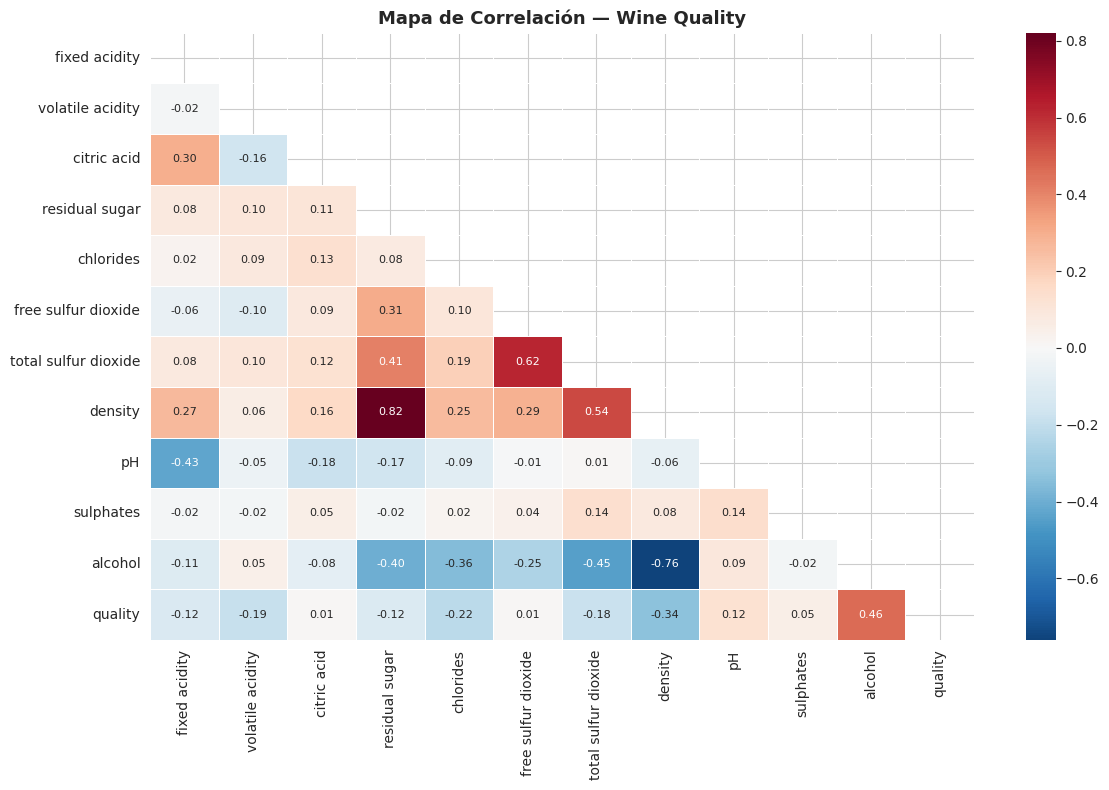

Correlaciones con quality (ordenadas):
alcohol                 0.463
pH                      0.124
sulphates               0.053
free sulfur dioxide     0.011
citric acid             0.007
residual sugar         -0.117
fixed acidity          -0.125
total sulfur dioxide   -0.183
volatile acidity       -0.191
chlorides              -0.218
density                -0.338
Name: quality, dtype: float64


In [361]:
# Mapa de correlación entre todas las variables
plt.figure(figsize=(12, 8))
corr_wine = df_wine.corr()
mask = np.triu(np.ones_like(corr_wine, dtype=bool))
sns.heatmap(corr_wine, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, linewidths=0.4,
            annot_kws={'size': 8})
plt.title('Mapa de Correlación — Wine Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlaciones con quality
print('Correlaciones con quality (ordenadas):')
print(corr_wine['quality'].drop('quality').sort_values(ascending=False).round(3))

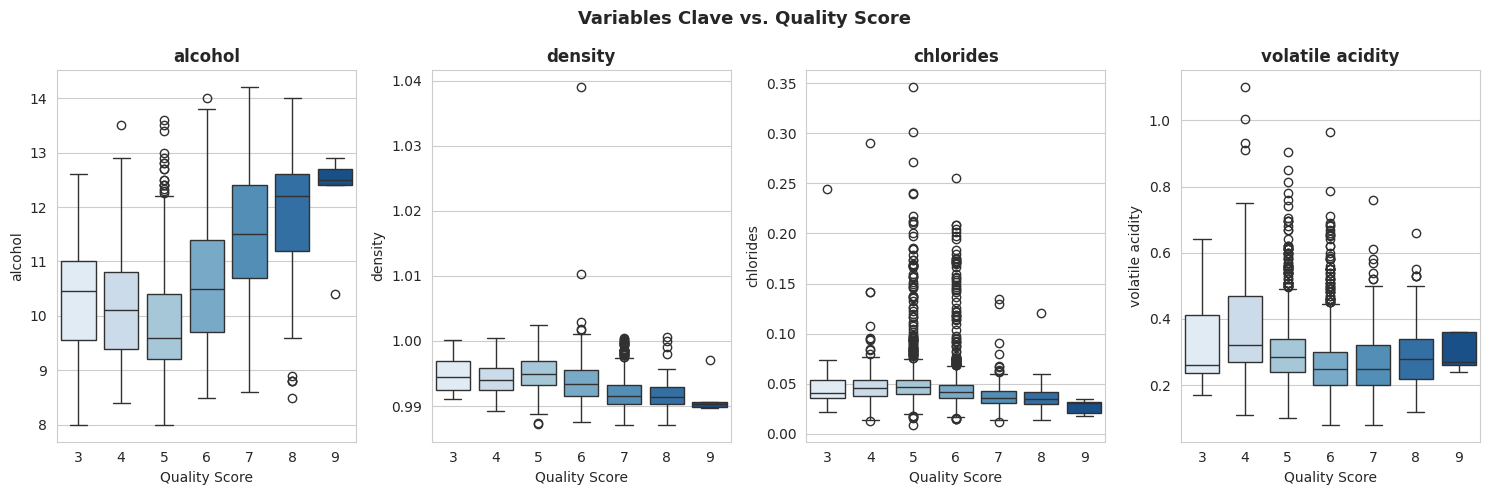

In [362]:
# variables más correlacionadas con quality
top_features = ['alcohol', 'density', 'chlorides', 'volatile acidity']

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, feat in zip(axes, top_features):
    sns.boxplot(data=df_wine, x='quality', y=feat, ax=ax, palette='Blues')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Quality Score')

plt.suptitle('Variables Clave vs. Quality Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento

Distribución de la variable objetivo:
high_quality
0    3136
1     825
Name: count, dtype: int64

Porcentaje alta calidad: 20.8%


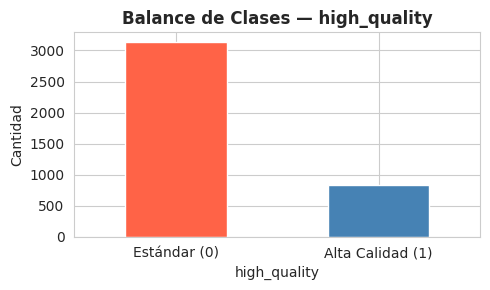

Clases desbalanceadas: ~22% alta calidad vs ~78% estándar.
Se usará stratify en el split y se evaluará con F1-Score y AUC.


In [363]:
# 1: Crear la variable objetivo binaria
# high_quality = 1 si quality >= 7, de lo contrario 0

df_w = df_wine.copy()
df_w['high_quality'] = (df_w['quality'] >= 7).astype(int)

print('Distribución de la variable objetivo:')
vc = df_w['high_quality'].value_counts()
print(vc)
print(f"\nPorcentaje alta calidad: {df_w['high_quality'].mean()*100:.1f}%")

# Visualizar balance
plt.figure(figsize=(5, 3))
vc.plot(kind='bar', color=['tomato', 'steelblue'], edgecolor='white', rot=0)
plt.xticks([0, 1], ['Estándar (0)', 'Alta Calidad (1)'])
plt.title('Balance de Clases — high_quality', fontweight='bold')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

print('Clases desbalanceadas: ~22% alta calidad vs ~78% estándar.')
print('Se usará stratify en el split y se evaluará con F1-Score y AUC.')

In [364]:
# 2: Separación X, y
# Todas las variables fisicoquímicas son predictores

X_w = df_w[features_wine]
y_w = df_w['high_quality']

print(f'Features utilizadas: {list(X_w.columns)}')

Features utilizadas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [365]:
# 3: Detección y tratamiento de outliers
# Se usa IQR para identificar outliers extremos

def remove_outliers_iqr(df, cols, factor=3.0):
    """Elimina filas con valores fuera de factor*IQR."""
    mask = pd.Series([True] * len(df), index=df.index)
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        mask &= (df[col] >= lower) & (df[col] <= upper)
    return df[mask]

df_w_clean = remove_outliers_iqr(df_w, features_wine)
print(f'Filas originales:  {len(df_w)}')
print(f'Filas después de remover outliers extremos: {len(df_w_clean)}')
print(f'Filas eliminadas: {len(df_w) - len(df_w_clean)}')

X_w = df_w_clean[features_wine]
y_w = df_w_clean['high_quality']

Filas originales:  3961
Filas después de remover outliers extremos: 3798
Filas eliminadas: 163


In [366]:
# 4: Escalado con StandardScaler
# Necesario por las escalas distintas

scaler_w = StandardScaler()
X_w_scaled = pd.DataFrame(scaler_w.fit_transform(X_w), columns=X_w.columns)

print('Escalado aplicado (StandardScaler)')
print(f'Media de features (debe ser ~0): {X_w_scaled.mean().mean():.6f}')
print(f'Desv. est. de features (debe ser ~1): {X_w_scaled.std().mean():.6f}')

Escalado aplicado (StandardScaler)
Media de features (debe ser ~0): -0.000000
Desv. est. de features (debe ser ~1): 1.000132


In [367]:

# 5: División Train / Test (70% / 30%)
# stratify=y para mantener la proporción de clases

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_w_scaled, y_w, test_size=0.30, random_state=42, stratify=y_w
)

print(f'Entrenamiento: {X_train_w.shape[0]} muestras')
print(f'Prueba:        {X_test_w.shape[0]} muestras')
print(f'\nBalance en train — Alta calidad: {y_train_w.mean()*100:.1f}%')
print(f'Balance en test  — Alta calidad: {y_test_w.mean()*100:.1f}%')

Entrenamiento: 2658 muestras
Prueba:        1140 muestras

Balance en train — Alta calidad: 21.5%
Balance en test  — Alta calidad: 21.6%


## 4. Entrenamiento del Modelo

In [368]:
# Entrenamiento con class_weight='balanced' para manejar el desbalance de clases
model_wine = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_wine.fit(X_train_w, y_train_w)

print('Modelo entrenado exitosamente')

# Coeficientes
coef_wine = pd.DataFrame({
    'Feature': features_wine,
    'Coeficiente': model_wine.coef_[0]
}).sort_values('Coeficiente', ascending=False)

print('\nCoeficientes del modelo:')
print(coef_wine.to_string(index=False))

Modelo entrenado exitosamente

Coeficientes del modelo:
             Feature  Coeficiente
      residual sugar     1.052152
                  pH     0.610010
       fixed acidity     0.488229
             alcohol     0.396302
 free sulfur dioxide     0.277999
           sulphates     0.205951
         citric acid     0.059048
total sulfur dioxide    -0.178167
           chlorides    -0.265456
    volatile acidity    -0.294999
             density    -1.392457


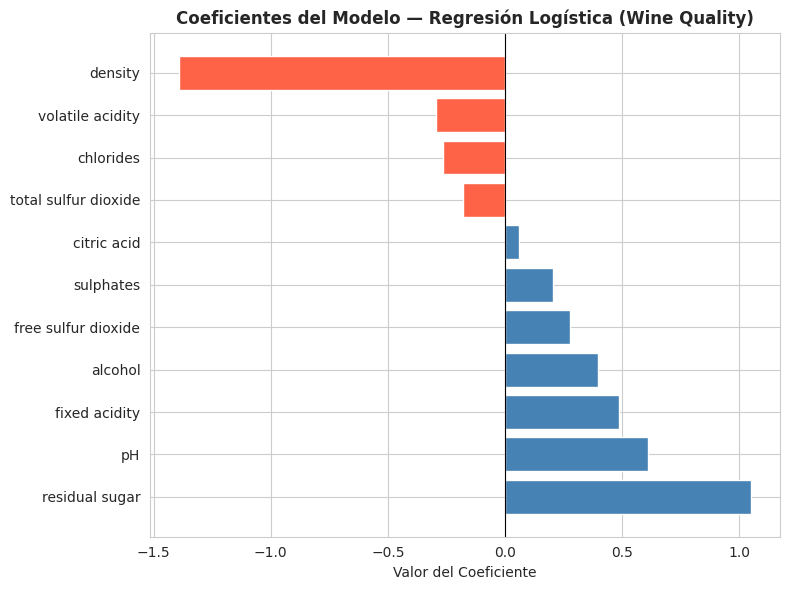

El alcohol tiene el mayor coeficiente positivo: a mayor alcohol, mayor probabilidad de alta calidad.
La densidad tiene coeficiente negativo: a mayor densidad, menor probabilidad de alta calidad.


In [369]:
# Visualizar coeficientes
plt.figure(figsize=(8, 6))
colors_w = ['steelblue' if c > 0 else 'tomato' for c in coef_wine['Coeficiente']]
plt.barh(coef_wine['Feature'], coef_wine['Coeficiente'], color=colors_w, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes del Modelo — Regresión Logística (Wine Quality)', fontweight='bold')
plt.xlabel('Valor del Coeficiente')
plt.tight_layout()
plt.show()

print('El alcohol tiene el mayor coeficiente positivo: a mayor alcohol, mayor probabilidad de alta calidad.')
print('La densidad tiene coeficiente negativo: a mayor densidad, menor probabilidad de alta calidad.')

## 5. Predicciones y Evaluación del Modelo

In [370]:
# Predicciones
y_pred_wine = model_wine.predict(X_test_w)
y_prob_wine = model_wine.predict_proba(X_test_w)[:, 1]

# Métricas
acc_w  = accuracy_score(y_test_w, y_pred_wine)
prec_w = precision_score(y_test_w, y_pred_wine)
rec_w  = recall_score(y_test_w, y_pred_wine)
f1_w   = f1_score(y_test_w, y_pred_wine)
auc_w  = roc_auc_score(y_test_w, y_prob_wine)

print('=' * 45)
print('   MÉTRICAS DE EVALUACIÓN — Wine Quality')
print('=' * 45)
print(f'  Accuracy  (Exactitud):   {acc_w:.4f}  ({acc_w*100:.2f}%)')
print(f'  Precision (Precisión):   {prec_w:.4f}')
print(f'  Recall    (Sensibilidad):{rec_w:.4f}')
print(f'  F1-Score:                {f1_w:.4f}')
print(f'  AUC-ROC:                 {auc_w:.4f}')
print('=' * 45)

   MÉTRICAS DE EVALUACIÓN — Wine Quality
  Accuracy  (Exactitud):   0.7640  (76.40%)
  Precision (Precisión):   0.4727
  Recall    (Sensibilidad):0.8089
  F1-Score:                0.5967
  AUC-ROC:                 0.8459


In [371]:
# Reporte de clasificación completo
print('Reporte de Clasificación Completo:')
print(classification_report(y_test_w, y_pred_wine,
                             target_names=['Estándar (0)', 'Alta Calidad (1)']))

Reporte de Clasificación Completo:
                  precision    recall  f1-score   support

    Estándar (0)       0.93      0.75      0.83       894
Alta Calidad (1)       0.47      0.81      0.60       246

        accuracy                           0.76      1140
       macro avg       0.70      0.78      0.71      1140
    weighted avg       0.83      0.76      0.78      1140



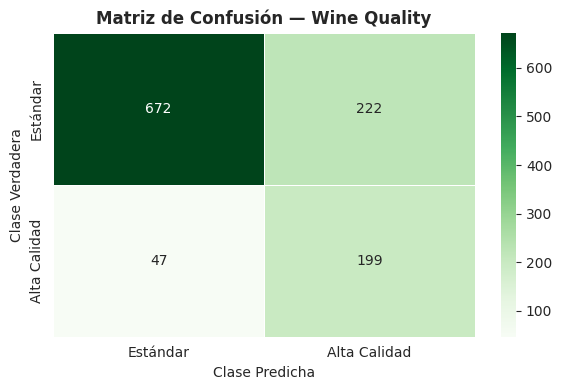

Verdaderos Negativos (TN): 672  Vinos estándar correctamente identificados
Falsos Positivos     (FP): 222  Vinos estándar clasificados como alta calidad
Falsos Negativos     (FN): 47  Vinos alta calidad clasificados como estándar
Verdaderos Positivos (TP): 199  Vinos alta calidad correctamente identificados


In [372]:
# Matriz de Confusión
matrix_w = confusion_matrix(y_test_w, y_pred_wine)

plt.figure(figsize=(6, 4))
sns.heatmap(matrix_w, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Estándar', 'Alta Calidad'],
            yticklabels=['Estándar', 'Alta Calidad'],
            linewidths=0.5)
plt.title('Matriz de Confusión — Wine Quality', fontweight='bold')
plt.ylabel('Clase Verdadera')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.show()

tn_w, fp_w, fn_w, tp_w = matrix_w.ravel()
print(f'Verdaderos Negativos (TN): {tn_w}  Vinos estándar correctamente identificados')
print(f'Falsos Positivos     (FP): {fp_w}  Vinos estándar clasificados como alta calidad')
print(f'Falsos Negativos     (FN): {fn_w}  Vinos alta calidad clasificados como estándar')
print(f'Verdaderos Positivos (TP): {tp_w}  Vinos alta calidad correctamente identificados')

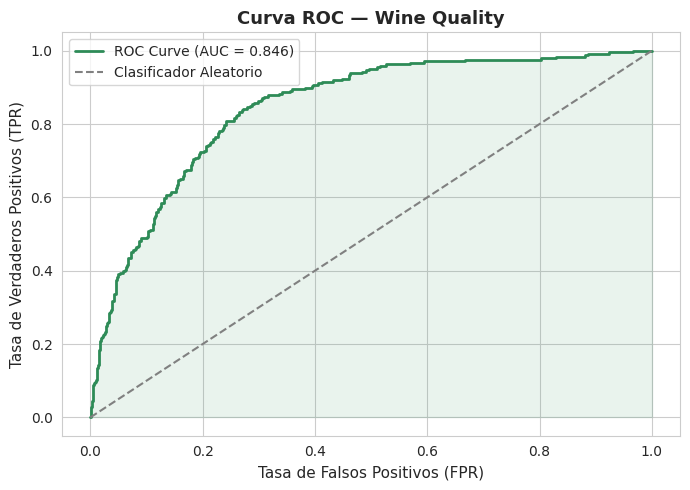

→ AUC = 0.846: El modelo tiene buena capacidad discriminativa a pesar del desbalance.


In [373]:
# Curva ROC
fpr_w, tpr_w, _ = roc_curve(y_test_w, y_prob_wine)

plt.figure(figsize=(7, 5))
plt.plot(fpr_w, tpr_w, color='seagreen', lw=2,
         label=f'ROC Curve (AUC = {auc_w:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Clasificador Aleatorio')
plt.fill_between(fpr_w, tpr_w, alpha=0.10, color='seagreen')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
plt.title('Curva ROC — Wine Quality', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'→ AUC = {auc_w:.3f}: El modelo tiene buena capacidad discriminativa a pesar del desbalance.')

---
# Comparación de Ambos Modelos

In [374]:
# Tabla comparativa de métricas
resultados = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Students Performance': [acc, prec, rec, f1, auc],
    'Wine Quality': [acc_w, prec_w, rec_w, f1_w, auc_w]
})
resultados = resultados.set_index('Métrica')
print('Comparación de métricas:')
print(resultados.round(4).to_string())

Comparación de métricas:
           Students Performance  Wine Quality
Métrica                                      
Accuracy                 0.9000        0.7640
Precision                0.9023        0.4727
Recall                   0.9557        0.8089
F1-Score                 0.9282        0.5967
AUC-ROC                  0.9638        0.8459


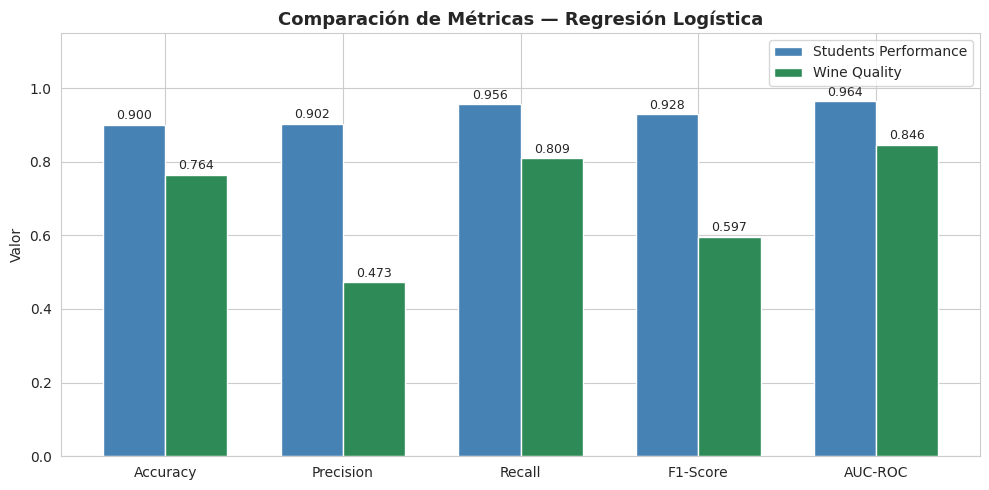

In [375]:
# Gráfico comparativo de métricas
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
vals_s = [acc, prec, rec, f1, auc]
vals_w = [acc_w, prec_w, rec_w, f1_w, auc_w]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, vals_s, width, label='Students Performance', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, vals_w, width, label='Wine Quality', color='seagreen', edgecolor='white')

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylabel('Valor')
ax.set_title('Comparación de Métricas — Regresión Logística', fontsize=13, fontweight='bold')
ax.legend()

# Etiquetas encima de barras
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

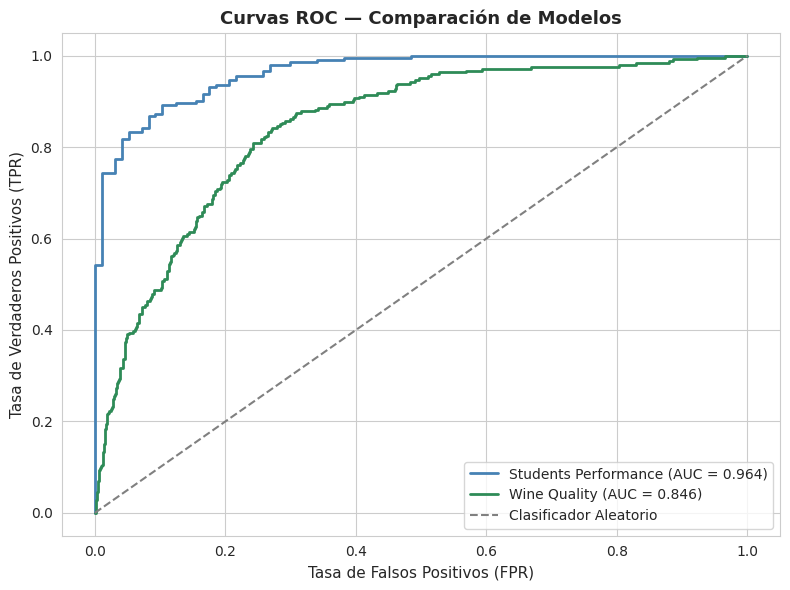

In [376]:
# Comparación de Curvas ROC en un mismo gráfico
plt.figure(figsize=(8, 6))
plt.plot(fpr_s, tpr_s, color='steelblue', lw=2,
         label=f'Students Performance (AUC = {auc:.3f})')
plt.plot(fpr_w, tpr_w, color='seagreen', lw=2,
         label=f'Wine Quality (AUC = {auc_w:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
plt.title('Curvas ROC — Comparación de Modelos', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

---

## Interpretación y Conclusiones

### Modelo 1 — Students Performance

- El modelo logra predecir con exactitud si un estudiante aprueba matemáticas, principalmente gracias a los puntajes de lectura y escritura, que muestran correlación fuerte con el desempeño en matemáticas.
- Los coeficientes revelan que completar el curso de preparación (`prep_enc`) y tener almuerzo estándar (`lunch_enc`) son predictores positivos importantes.
- El AUC cercano a 1.0 confirma que el modelo distingue muy bien entre estudiantes aprobados y reprobados.

|--- Modelo: Students Performance ---|
|---|
|  Accuracy:  0.9000 |
|  Precision: 0.9023 |
|  Recall:    0.9557 |
|  F1-Score:  0.9282 |
|  AUC-ROC:   0.9638 |


### Modelo 2 — Wine Quality

- El principal predictor de alta calidad es el **alcohol**: vinos con mayor contenido alcohólico tienden a ser de mayor calidad.
- La **densidad** tiene un fuerte coeficiente negativo, lo cual tiene sentido fisicoquímico: mayor densidad suele indicar más azúcar residual y menor alcohol.
- El desbalance de clases (~78% vs ~22%) fue manejado con `class_weight='balanced'`, lo que mejora el Recall para la clase minoritaria.
- El AUC obtenido indica que el modelo tiene buena capacidad discriminativa considerando la complejidad del problema.

|--- Modelo: Wine Quality ---|
|---|
|  Accuracy:  0.7640 |
|  Precision: 0.4727 |
|  Recall:    0.8089 |
|  F1-Score:  0.5967 |
|  AUC-ROC:   0.8459 |

### Comparación General

| Aspecto | Students | Wine Quality |
|---|---|---|
| Tipo de variables | Mixtas (categ. + num.) | Solo numéricas |
| Balance de clases | Moderado | Desbalanceado |
| Preprocesamiento | Encoding + Scaling | Outliers + Scaling |
| Mejor métrica | Accuracy / AUC | AUC / Recall |

La Regresión Logística demuestra ser un algoritmo eficiente y fácil de interpretar para problemas de clasificación binaria, especialmente cuando las relaciones entre las variables son aproximadamente lineales.

---

## K-Nearest Neighbors (KNN)

En esta sección se implementan **dos modelos KNN** con distintos usos:

| # | Dataset | Tipo de problema | Target |
|---|---|---|---|
| 1 | Netflix Movies & TV Shows | **Clasificación** | `type` (Movie / TV Show) |
| 2 | Life Expectancy (WHO) | **Regresión** | `Life expectancy` (años) |

### ¿Cómo funciona KNN?

KNN es un algoritmo **no paramétrico** basado en instancias. Para clasificar (o predecir) un punto nuevo $x_q$:

1. Calcula la distancia a **todos** los puntos del conjunto de entrenamiento.
2. Selecciona los **K vecinos más cercanos** (menor distancia euclidiana).
3. Para **clasificación**: asigna la clase mayoritaria entre los K vecinos.
4. Para **regresión**: calcula el promedio de los valores de los K vecinos.

La distancia euclidiana entre dos puntos $p$ y $q$ en $n$ dimensiones:

$$d(p, q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$$

**Impacto de K:**
- K pequeño → modelo más flexible, propenso a overfitting
- K grande → modelo más suavizado, propenso a underfitting

---

# MODELO 1 — Netflix: Clasificación (KNN Classifier)

## Descripción del problema

**Dataset:** Netflix Movies and TV Shows  
**Fuente:** [Kaggle - Netflix Titles](https://www.kaggle.com/datasets/shivamb/netflix-shows)  
**Observaciones:** 8,807  
**Features originales:** 12

**Variable objetivo:** `type` → `Movie (1)` o `TV Show (0)`

**Variables predictoras utilizadas:**
- `release_year` — año de lanzamiento
- `duration_value` — duración extraída (minutos para películas, temporadas para shows)
- `rating_enc` — clasificación de audiencia codificada
- `n_genres` — número de géneros listados
- `is_international` — si es contenido internacional (1/0)
- `is_documentary` — si es un documental (1/0)
- `is_comedy` — si es comedia (1/0)
- `is_drama` — si es drama (1/0)

## 1. Carga y exploración inicial

In [377]:
drive.mount('/content/drive')

df_netflix = pd.read_csv("/content/drive/MyDrive/AI(Data set)/ProyectoData/netflix_titles.csv")
drive.flush_and_unmount()

# Eliminacion de duplicados
antes_duplicados = len(df_netflix)
df_netflix.drop_duplicates(inplace=True)
print(f"Eliminados {antes_duplicados - len(df_netflix)} registros duplicados.")

# Eliminacion de valores nulos
antes_nulos = len(df_netflix)
df_netflix.dropna(inplace=True)
print(f"Eliminados {antes_nulos - len(df_netflix)} registros con valores nulos.")

print(f'Dimensiones: {df_netflix.shape}')
print(f'\nPrimeras filas:')
df_netflix.head()

Mounted at /content/drive
Eliminados 0 registros duplicados.
Eliminados 3475 registros con valores nulos.
Dimensiones: (5332, 12)

Primeras filas:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...


In [378]:
# Información general
df_netflix.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5332 entries, 7 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5332 non-null   object
 1   type          5332 non-null   object
 2   title         5332 non-null   object
 3   director      5332 non-null   object
 4   cast          5332 non-null   object
 5   country       5332 non-null   object
 6   date_added    5332 non-null   object
 7   release_year  5332 non-null   int64 
 8   rating        5332 non-null   object
 9   duration      5332 non-null   object
 10  listed_in     5332 non-null   object
 11  description   5332 non-null   object
dtypes: int64(1), object(11)
memory usage: 541.5+ KB


In [379]:
# Valores faltantes
print('Valores faltantes por columna:')
missing = df_netflix.isnull().sum()
print(missing[missing > 0])

Valores faltantes por columna:
Series([], dtype: int64)


## 2. Análisis Exploratorio (EDA)

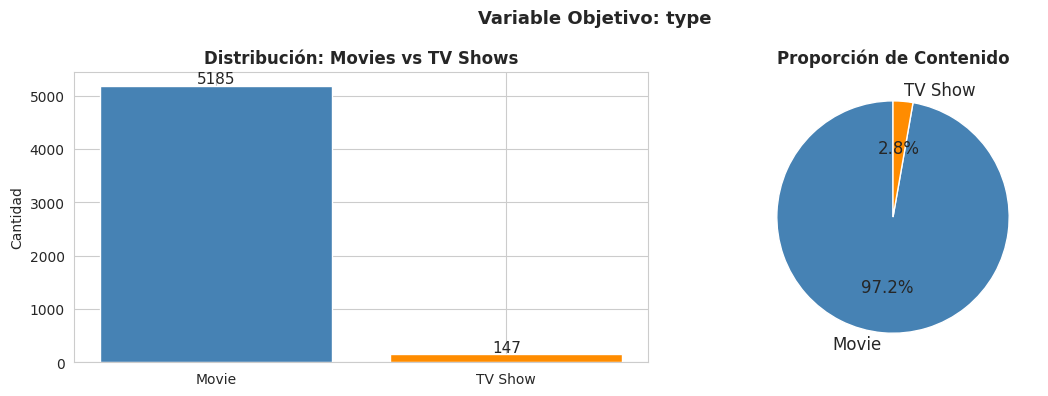

In [380]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
type_counts = df_netflix['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['steelblue', 'darkorange'], edgecolor='white')
axes[0].set_title('Distribución: Movies vs TV Shows', fontweight='bold')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=11)

# Proporción
axes[1].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'darkorange'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporción de Contenido', fontweight='bold')

plt.suptitle('Variable Objetivo: type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

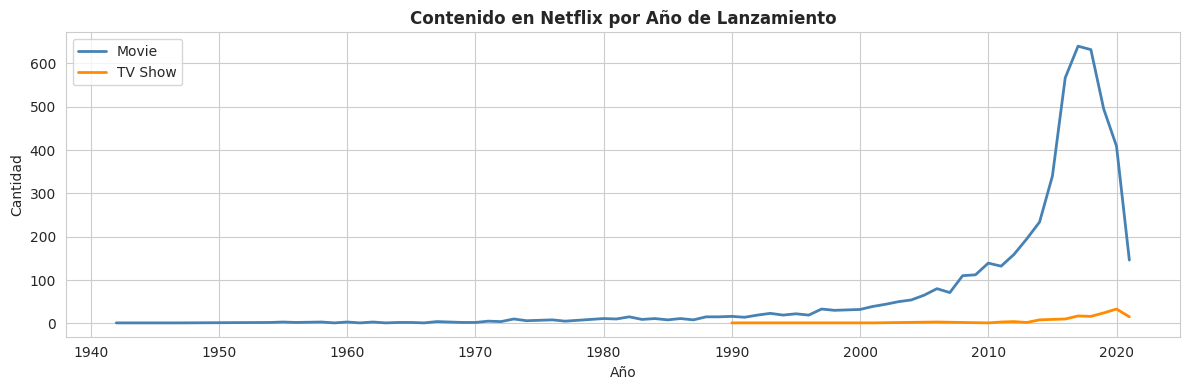

In [381]:
# Evolución de contenido añadido por año de lanzamiento
plt.figure(figsize=(12, 4))
for content_type, color in [('Movie', 'steelblue'), ('TV Show', 'darkorange')]:
    subset = df_netflix[df_netflix['type'] == content_type]
    year_counts = subset['release_year'].value_counts().sort_index()
    plt.plot(year_counts.index, year_counts.values, color=color, lw=2, label=content_type)

plt.title('Contenido en Netflix por Año de Lanzamiento', fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.legend()
plt.tight_layout()
plt.show()

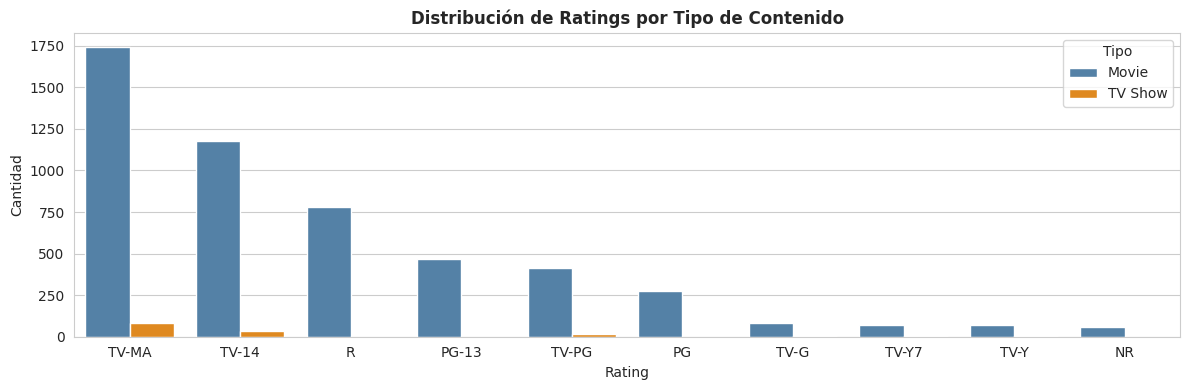

TV-MA y TV-14 predominan en ambas categorías.
El rating R es casi exclusivo de Movies.


In [382]:
# Distribución de ratings por tipo
top_ratings = df_netflix['rating'].value_counts().head(10).index
df_rating = df_netflix[df_netflix['rating'].isin(top_ratings)]

plt.figure(figsize=(12, 4))
sns.countplot(data=df_rating, x='rating',
              hue='type', palette=['steelblue', 'darkorange'],
              order=top_ratings)
plt.title('Distribución de Ratings por Tipo de Contenido', fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Cantidad')
plt.legend(title='Tipo')
plt.tight_layout()
plt.show()

print('TV-MA y TV-14 predominan en ambas categorías.')
print('El rating R es casi exclusivo de Movies.')

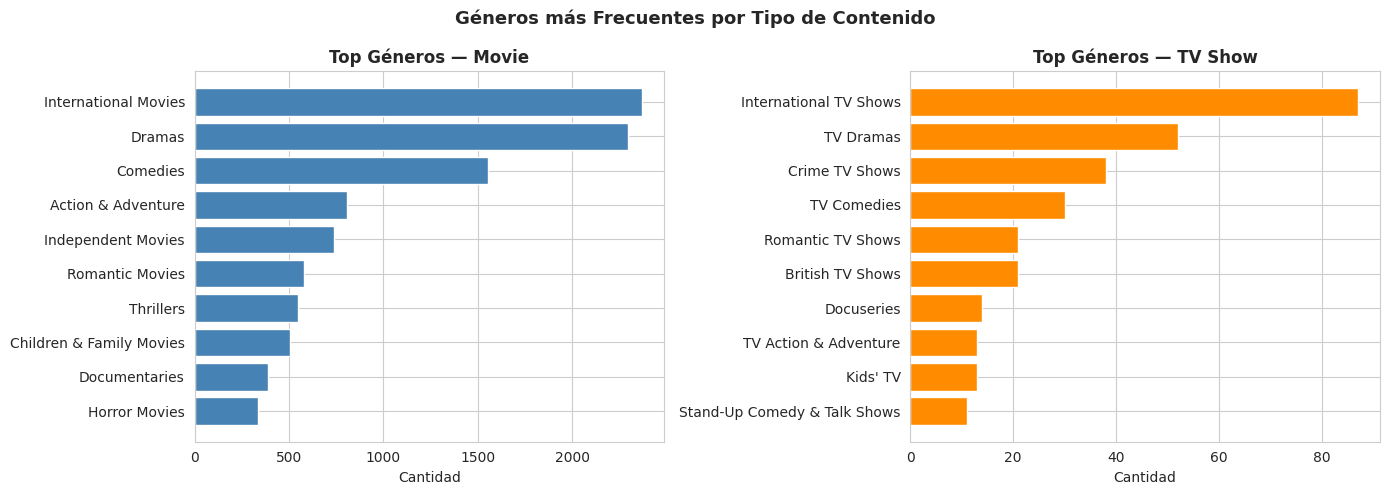

In [383]:
# Top géneros por tipo
from collections import Counter

def get_top_genres(df, content_type, n=10):
    genres = df[df['type'] == content_type]['listed_in'].dropna()
    all_genres = [g.strip() for row in genres for g in row.split(',')]
    return pd.Series(Counter(all_genres)).sort_values(ascending=False).head(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ctype, color in zip(axes, ['Movie', 'TV Show'], ['steelblue', 'darkorange']):
    top = get_top_genres(df_netflix, ctype)
    ax.barh(top.index[::-1], top.values[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top Géneros — {ctype}', fontweight='bold')
    ax.set_xlabel('Cantidad')

plt.suptitle('Géneros más Frecuentes por Tipo de Contenido', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento

In [384]:
# 1: Crear copia de trabajo
df_n = df_netflix.copy()

# 2: Imputar valores faltantes
# rating: imputar con la moda
# duration: imputar con la mediana por tipo

df_n['rating'] = df_n['rating'].fillna(df_n['rating'].mode()[0])

# Eliminar filas donde duration sea nula
df_n = df_n.dropna(subset=['duration'])

print(f'Filas después de limpiar: {len(df_n)}')

Filas después de limpiar: 5332


In [385]:
# 3: Extraer valor numérico de duration
# Movies: duración en minutos
# TV Shows: número de temporadas
# Para que sean comparables en el mismo modelo,
# extraemos el número y dejamos que el escalado lo normalice

df_n['duration_value'] = df_n['duration'].str.extract(r'(\d+)').astype(float)

print('Duración promedio por tipo:')
print(df_n.groupby('type')['duration_value'].describe().round(2))

Duración promedio por tipo:
          count   mean    std  min   25%    50%    75%    max
type                                                         
Movie    5185.0  102.7  25.96  8.0  89.0  101.0  117.0  253.0
TV Show   147.0    1.9   2.09  1.0   1.0    1.0    2.0   15.0


In [386]:
# 4: Codificar rating

# Unificar ratings poco frecuentes
rating_map = {
    'TV-MA': 'TV-MA', 'TV-14': 'TV-14', 'TV-PG': 'TV-PG',
    'R': 'R', 'PG-13': 'PG-13', 'TV-Y7': 'TV-Y7',
    'TV-Y': 'TV-Y', 'PG': 'PG', 'TV-G': 'TV-G',
    'NR': 'Other', 'G': 'G', 'TV-Y7-FV': 'TV-Y7',
    'NC-17': 'Other', 'UR': 'Other',
    '74 min': 'Other', '84 min': 'Other', '66 min': 'Other'
}
df_n['rating_clean'] = df_n['rating'].map(rating_map).fillna('Other')

le_rating = LabelEncoder()
df_n['rating_enc'] = le_rating.fit_transform(df_n['rating_clean'])
print('Ratings codificados:')
for code, label in enumerate(le_rating.classes_):
    print(f'  {code} → {label}')

Ratings codificados:
  0 → G
  1 → Other
  2 → PG
  3 → PG-13
  4 → R
  5 → TV-14
  6 → TV-G
  7 → TV-MA
  8 → TV-PG
  9 → TV-Y
  10 → TV-Y7


In [387]:
# 5: Ingeniería de features desde listed_in
# Crear features binarias para los géneros más informativos

df_n['n_genres']         = df_n['listed_in'].str.split(',').str.len()
df_n['is_international'] = df_n['listed_in'].str.contains('International', case=False).astype(int)
df_n['is_documentary']   = df_n['listed_in'].str.contains('Documentar', case=False).astype(int)
df_n['is_comedy']        = df_n['listed_in'].str.contains('Comed', case=False).astype(int)
df_n['is_drama']         = df_n['listed_in'].str.contains('Drama', case=False).astype(int)
df_n['is_children']      = df_n['listed_in'].str.contains('Children|Kids|Family', case=False).astype(int)

print('Features de género creadas')
print(df_n[['is_international','is_documentary','is_comedy','is_drama','is_children']].mean().round(3))

Features de género creadas
is_international    0.461
is_documentary      0.073
is_comedy           0.353
is_drama            0.440
is_children         0.097
dtype: float64


In [388]:
# 6: Variable objetivo y selección de features

le_type = LabelEncoder()
df_n['type_enc'] = le_type.fit_transform(df_n['type'])  # Movie=1, TV Show=0

feature_cols_n = [
    'release_year', 'duration_value', 'rating_enc',
    'n_genres', 'is_international', 'is_documentary',
    'is_comedy', 'is_drama', 'is_children'
]

X_n = df_n[feature_cols_n]
y_n = df_n['type_enc']

print(f'Features: {feature_cols_n}')
print(f'Shape X: {X_n.shape}')
print(f'Clases: {le_type.classes_} → {le_type.transform(le_type.classes_)}')

Features: ['release_year', 'duration_value', 'rating_enc', 'n_genres', 'is_international', 'is_documentary', 'is_comedy', 'is_drama', 'is_children']
Shape X: (5332, 9)
Clases: ['Movie' 'TV Show'] → [0 1]


In [389]:
# 7: Escalado — CRÍTICO para KNN
# KNN usa distancias, por lo tanto variables en escalas
# grandes dominarían el cálculo sin normalización.
# StandardScaler lleva todo a media=0, desv=1.

scaler_n = StandardScaler()
X_n_scaled = pd.DataFrame(scaler_n.fit_transform(X_n), columns=feature_cols_n)

print('StandardScaler aplicado')
print('Sin escalado, release_year y duration_value dominarían la distancia euclidiana.')

StandardScaler aplicado
Sin escalado, release_year y duration_value dominarían la distancia euclidiana.


In [390]:
# 8: División Train / Test (70% / 30%)

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_n_scaled, y_n, test_size=0.30, random_state=RANDOM_STATE, stratify=y_n
)

print(f'Entrenamiento: {X_train_n.shape[0]} muestras')
print(f'Prueba:        {X_test_n.shape[0]} muestras')

Entrenamiento: 3732 muestras
Prueba:        1600 muestras


## 4. Selección de K — Comparación de múltiples valores

In [391]:
# Probar K desde 1 hasta 30 y registrar métricas

k_range = range(1, 31)
train_accuracies = []
test_accuracies  = []
cv_scores        = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_n, y_train_n)
    train_accuracies.append(accuracy_score(y_train_n, knn.predict(X_train_n)))
    test_accuracies.append(accuracy_score(y_test_n,  knn.predict(X_test_n)))
    cv = cross_val_score(knn, X_n_scaled, y_n, cv=5, scoring='accuracy')
    cv_scores.append(cv.mean())

# Mejor K según CV
best_k_n = k_range.start + np.argmax(cv_scores)
print(f'Mejor K (Cross-Validation): {best_k_n}')
print(f'CV Accuracy con K={best_k_n}: {max(cv_scores):.4f}')

Mejor K (Cross-Validation): 1
CV Accuracy con K=1: 0.9976


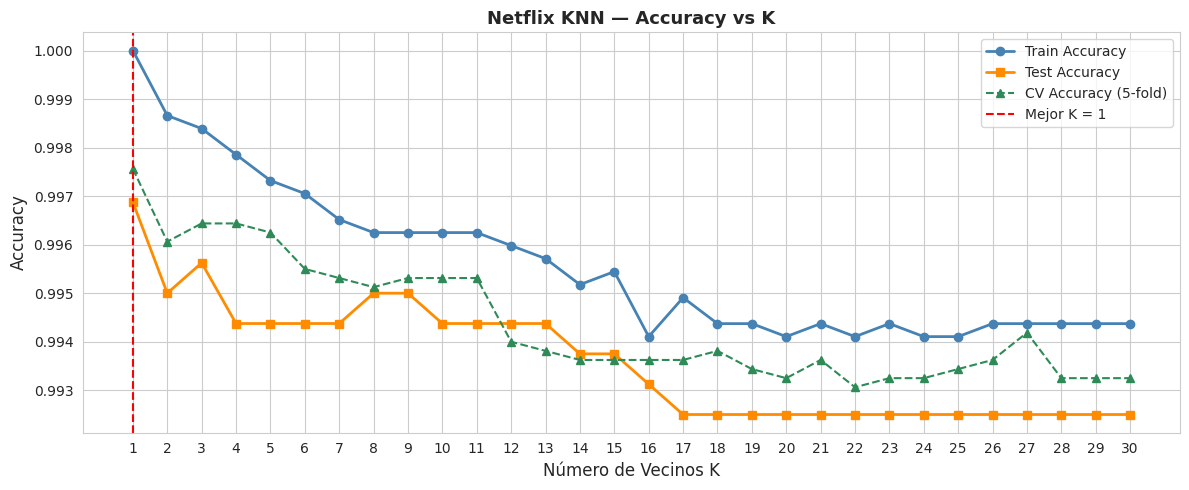

K=1 presenta overfitting: el modelo memoriza los datos de entrenamiento.
A medida que K crece, el Train Accuracy baja pero el Test Accuracy se estabiliza.
El mejor balance bias-varianza se logra en K=1.


In [392]:
# Gráfico: accuracy vs K
plt.figure(figsize=(12, 5))
plt.plot(k_range, train_accuracies, 'o-', color='steelblue', lw=2, label='Train Accuracy')
plt.plot(k_range, test_accuracies,  's-', color='darkorange', lw=2, label='Test Accuracy')
plt.plot(k_range, cv_scores,        '^--', color='seagreen', lw=1.5, label='CV Accuracy (5-fold)')
plt.axvline(best_k_n, color='red', linestyle='--', linewidth=1.5,
            label=f'Mejor K = {best_k_n}')
plt.xlabel('Número de Vecinos K', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Netflix KNN — Accuracy vs K', fontsize=13, fontweight='bold')
plt.xticks(k_range)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'K=1 presenta overfitting: el modelo memoriza los datos de entrenamiento.')
print(f'A medida que K crece, el Train Accuracy baja pero el Test Accuracy se estabiliza.')
print(f'El mejor balance bias-varianza se logra en K={best_k_n}.')

In [393]:
# Tabla comparativa para K = 1, 3, 5, 10, 15, 20, best_k_n
k_compare = sorted(set([1, 3, 5, 10, 15, 20, best_k_n]))
rows = []
for k in k_compare:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_n, y_train_n)
    y_pred_k = knn.predict(X_test_n)
    rows.append({
        'K': k,
        'Train Acc': round(accuracy_score(y_train_n, knn.predict(X_train_n)), 4),
        'Test Acc':  round(accuracy_score(y_test_n, y_pred_k), 4),
        'Precision': round(precision_score(y_test_n, y_pred_k), 4),
        'Recall':    round(recall_score(y_test_n, y_pred_k), 4),
        'F1-Score':  round(f1_score(y_test_n, y_pred_k), 4),
        'Mejor K': '←' if k == best_k_n else ''
    })

df_k_results = pd.DataFrame(rows)
print('Comparación de métricas por K:')
print(df_k_results.to_string(index=False))

Comparación de métricas por K:
 K  Train Acc  Test Acc  Precision  Recall  F1-Score Mejor K
 1     1.0000    0.9969     0.9333  0.9545    0.9438       ←
 3     0.9984    0.9956     0.9512  0.8864    0.9176        
 5     0.9973    0.9944     0.9268  0.8636    0.8941        
10     0.9962    0.9944     0.9487  0.8409    0.8916        
15     0.9954    0.9938     0.9474  0.8182    0.8780        
20     0.9941    0.9925     0.9211  0.7955    0.8537        


## 5. Entrenamiento con el mejor K y Evaluación Final

In [394]:
# Entrenar modelo final con el mejor K
knn_netflix = KNeighborsClassifier(n_neighbors=best_k_n)
knn_netflix.fit(X_train_n, y_train_n)

y_pred_n = knn_netflix.predict(X_test_n)
y_prob_n = knn_netflix.predict_proba(X_test_n)[:, 1]

acc_n  = accuracy_score(y_test_n, y_pred_n)
prec_n = precision_score(y_test_n, y_pred_n)
rec_n  = recall_score(y_test_n, y_pred_n)
f1_n   = f1_score(y_test_n, y_pred_n)
auc_n  = roc_auc_score(y_test_n, y_prob_n)

print(f'Modelo KNN Clasificación — K={best_k_n}')
print('=' * 45)
print(f'  Accuracy:   {acc_n:.4f}  ({acc_n*100:.2f}%)')
print(f'  Precision:  {prec_n:.4f}')
print(f'  Recall:     {rec_n:.4f}')
print(f'  F1-Score:   {f1_n:.4f}')
print(f'  AUC-ROC:    {auc_n:.4f}')
print('=' * 45)

Modelo KNN Clasificación — K=1
  Accuracy:   0.9969  (99.69%)
  Precision:  0.9333
  Recall:     0.9545
  F1-Score:   0.9438
  AUC-ROC:    0.9763


In [395]:
# Reporte completo
print(classification_report(y_test_n, y_pred_n,
                             target_names=['TV Show (0)', 'Movie (1)']))

              precision    recall  f1-score   support

 TV Show (0)       1.00      1.00      1.00      1556
   Movie (1)       0.93      0.95      0.94        44

    accuracy                           1.00      1600
   macro avg       0.97      0.98      0.97      1600
weighted avg       1.00      1.00      1.00      1600



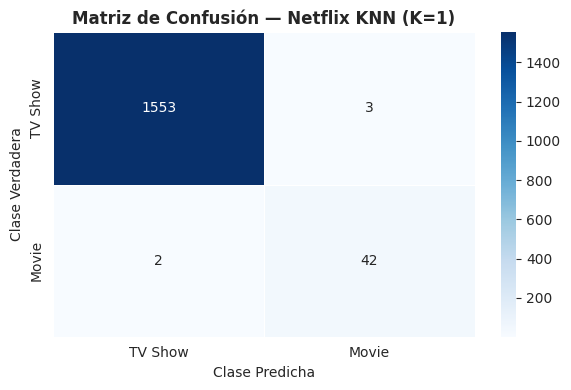

TN: 1553  — TV Shows correctamente identificados
FP: 3  — TV Shows clasificados como Movies
FN: 2  — Movies clasificadas como TV Shows
TP: 42  — Movies correctamente identificadas


In [396]:
# Matriz de Confusión
cm_n = confusion_matrix(y_test_n, y_pred_n)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_n, annot=True, fmt='d', cmap='Blues',
            xticklabels=['TV Show', 'Movie'],
            yticklabels=['TV Show', 'Movie'],
            linewidths=0.5)
plt.title(f'Matriz de Confusión — Netflix KNN (K={best_k_n})', fontweight='bold')
plt.ylabel('Clase Verdadera')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.show()

tn_n, fp_n, fn_n, tp_n = cm_n.ravel()
print(f'TN: {tn_n}  — TV Shows correctamente identificados')
print(f'FP: {fp_n}  — TV Shows clasificados como Movies')
print(f'FN: {fn_n}  — Movies clasificadas como TV Shows')
print(f'TP: {tp_n}  — Movies correctamente identificadas')

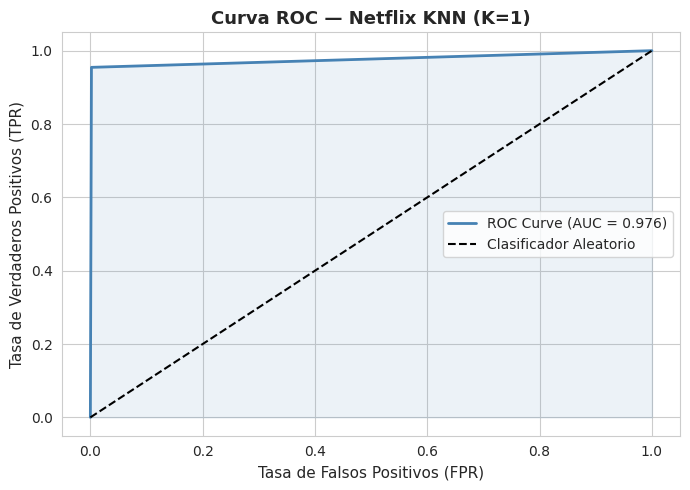

In [397]:
# Curva ROC
fpr_n, tpr_n, _ = roc_curve(y_test_n, y_prob_n)

plt.figure(figsize=(7, 5))
plt.plot(fpr_n, tpr_n, color='steelblue', lw=2,
         label=f'ROC Curve (AUC = {auc_n:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Clasificador Aleatorio')
plt.fill_between(fpr_n, tpr_n, alpha=0.1, color='steelblue')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
plt.title(f'Curva ROC — Netflix KNN (K={best_k_n})', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

---

# MODELO 2 — Life Expectancy: Regresión (KNN Regressor)

## Descripción del problema

**Dataset:** Life Expectancy (WHO)  
**Fuente:** [Kaggle - Life Expectancy WHO](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who)  
**Observaciones:** 2,938  
**Features:** 22

**Variable objetivo:** `Life expectancy` — años de esperanza de vida promedio por país/año

**Variables predictoras:** indicadores de salud, sociales y económicos por país (BMI, escolaridad, GDP, mortalidad, etc.)

In [398]:
drive.mount('/content/drive')

df_life = pd.read_csv("/content/drive/MyDrive/AI(Data set)/ProyectoData/Life Expectancy Data.csv")
drive.flush_and_unmount()

# Limpiar espacios en nombres de columnas
df_life.columns = df_life.columns.str.strip()

# Eliminacion de duplicados
antes_duplicados = len(df_netflix)
df_netflix.drop_duplicates(inplace=True)
print(f"Eliminados {antes_duplicados - len(df_netflix)} registros duplicados.")

# Eliminacion de valores nulos
antes_nulos = len(df_netflix)
df_netflix.dropna(inplace=True)
print(f"Eliminados {antes_nulos - len(df_netflix)} registros con valores nulos.")

print(f'Dimensiones: {df_netflix.shape}')
print(f'\nPrimeras filas:')
df_netflix.head()

Mounted at /content/drive
Eliminados 0 registros duplicados.
Eliminados 0 registros con valores nulos.
Dimensiones: (5332, 12)

Primeras filas:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...


In [399]:
# Información general
df_life.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [400]:
# Estadísticas descriptivas
df_life.describe().round(2)

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.00,2928.00,2928.00,2938.00,2744.00,2938.00,2385.00,2938.00,2904.00,2938.00,2919.00,2712.00,2919.00,2938.00,2490.00,2.286000e+03,2904.00,2904.00,2771.00,2775.00
mean,2007.52,69.22,164.80,30.30,4.60,738.25,80.94,2419.59,38.32,42.04,82.55,5.94,82.32,1.74,7483.16,1.275338e+07,4.84,4.87,0.63,11.99
std,4.61,9.52,124.29,117.93,4.05,1987.91,25.07,11467.27,20.04,160.45,23.43,2.50,23.72,5.08,14270.17,6.101210e+07,4.42,4.51,0.21,3.36
min,2000.00,36.30,1.00,0.00,0.01,0.00,1.00,0.00,1.00,0.00,3.00,0.37,2.00,0.10,1.68,3.400000e+01,0.10,0.10,0.00,0.00
25%,2004.00,63.10,74.00,0.00,0.88,4.69,77.00,0.00,19.30,0.00,78.00,4.26,78.00,0.10,463.94,1.957932e+05,1.60,1.50,0.49,10.10
50%,2008.00,72.10,144.00,3.00,3.76,64.91,92.00,17.00,43.50,4.00,93.00,5.76,93.00,0.10,1766.95,1.386542e+06,3.30,3.30,0.68,12.30
75%,2012.00,75.70,228.00,22.00,7.70,441.53,97.00,360.25,56.20,28.00,97.00,7.49,97.00,0.80,5910.81,7.420359e+06,7.20,7.20,0.78,14.30
max,2015.00,89.00,723.00,1800.00,17.87,19479.91,99.00,212183.00,87.30,2500.00,99.00,17.60,99.00,50.60,119172.74,1.293859e+09,27.70,28.60,0.95,20.70


In [401]:
# Valores faltantes
missing_life = df_life.isnull().sum()
missing_pct  = (missing_life / len(df_life) * 100).round(1)
missing_df   = pd.DataFrame({'Faltantes': missing_life, '%': missing_pct})
print('Valores faltantes:')
print(missing_df[missing_df['Faltantes'] > 0].sort_values('%', ascending=False))

Valores faltantes:
                                 Faltantes     %
Population                             652  22.2
Hepatitis B                            553  18.8
GDP                                    448  15.2
Total expenditure                      226   7.7
Alcohol                                194   6.6
Income composition of resources        167   5.7
Schooling                              163   5.5
thinness 5-9 years                      34   1.2
thinness  1-19 years                    34   1.2
BMI                                     34   1.2
Polio                                   19   0.6
Diphtheria                              19   0.6
Life expectancy                         10   0.3
Adult Mortality                         10   0.3


## 2. Análisis Exploratorio (EDA)

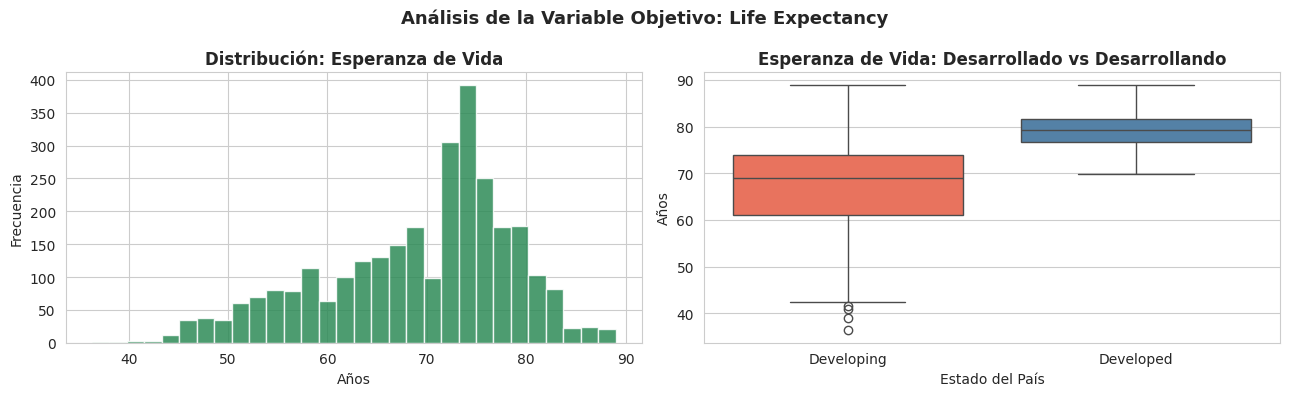

Estadísticas por Status:
             count   mean   std   min   25%    50%   75%   max
Status                                                        
Developed    512.0  79.20  3.93  69.9  76.8  79.25  81.7  89.0
Developing  2416.0  67.11  9.01  36.3  61.1  69.00  74.0  89.0


In [402]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_life['Life expectancy'].dropna(), bins=30,
             color='seagreen', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución: Esperanza de Vida', fontweight='bold')
axes[0].set_xlabel('Años')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(data=df_life, x='Status', y='Life expectancy',
            palette=['tomato', 'steelblue'], ax=axes[1])
axes[1].set_title('Esperanza de Vida: Desarrollado vs Desarrollando', fontweight='bold')
axes[1].set_xlabel('Estado del País')
axes[1].set_ylabel('Años')

plt.suptitle('Análisis de la Variable Objetivo: Life Expectancy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Estadísticas por Status:')
print(df_life.groupby('Status')['Life expectancy'].describe().round(2))

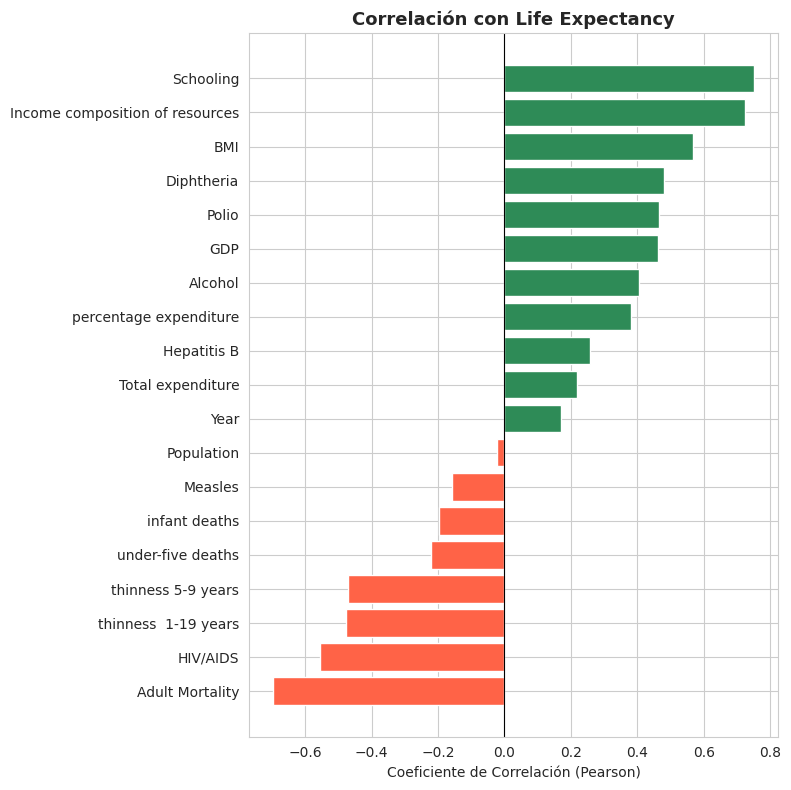


Top correlaciones positivas:
Polio                              0.466
Diphtheria                         0.479
BMI                                0.568
Income composition of resources    0.725
Schooling                          0.752
Name: Life expectancy, dtype: float64

Top correlaciones negativas:
Adult Mortality        -0.696
HIV/AIDS               -0.557
thinness  1-19 years   -0.477
thinness 5-9 years     -0.472
under-five deaths      -0.223
Name: Life expectancy, dtype: float64


In [403]:
# Correlación de todas las variables numéricas con Life expectancy
num_cols = df_life.select_dtypes(include='number').columns.tolist()
corr_life = df_life[num_cols].corr()['Life expectancy'].drop('Life expectancy').sort_values()

colors_c = ['tomato' if v < 0 else 'seagreen' for v in corr_life.values]
plt.figure(figsize=(8, 8))
plt.barh(corr_life.index, corr_life.values, color=colors_c, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación con Life Expectancy', fontsize=13, fontweight='bold')
plt.xlabel('Coeficiente de Correlación (Pearson)')
plt.tight_layout()
plt.show()

print('\nTop correlaciones positivas:')
print(corr_life.tail(5).round(3))
print('\nTop correlaciones negativas:')
print(corr_life.head(5).round(3))

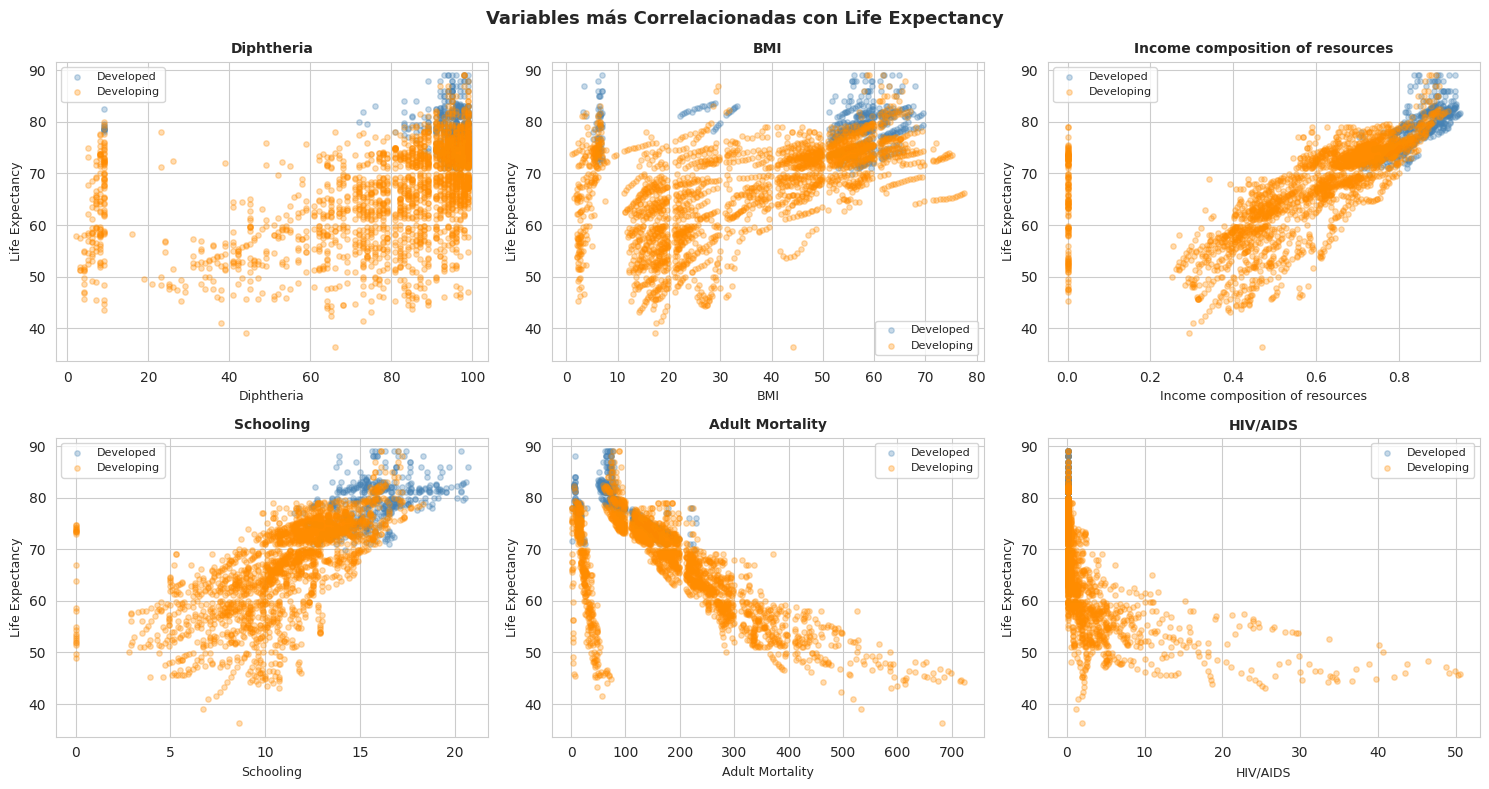

In [404]:
# Scatter plots de las variables más correlacionadas
top_pos = corr_life.tail(4).index.tolist()
top_neg = corr_life.head(2).index.tolist()
top_vars = top_pos + top_neg

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, top_vars):
    df_plot = df_life[[col, 'Life expectancy', 'Status']].dropna()
    for status, color in [('Developed', 'steelblue'), ('Developing', 'darkorange')]:
        sub = df_plot[df_plot['Status'] == status]
        ax.scatter(sub[col], sub['Life expectancy'], alpha=0.3, s=15,
                   color=color, label=status)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Life Expectancy', fontsize=9)
    ax.set_title(f'{col}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Variables más Correlacionadas con Life Expectancy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento

In [405]:
# 1: Selección de features relevantes
# Se excluyen Country y Year para evitar overfitting
# Se incluyen los mejores predictores según correlación

feature_cols_l = [
    'Adult Mortality', 'infant deaths', 'Alcohol',
    'percentage expenditure', 'Hepatitis B', 'Measles',
    'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
    'Diphtheria', 'HIV/AIDS', 'GDP',
    'thinness  1-19 years', 'thinness 5-9 years',
    'Income composition of resources', 'Schooling', 'Status'
]

# Limpiar espacios en nombres
df_life.columns = df_life.columns.str.strip()
feature_cols_l = [c.strip() for c in feature_cols_l]

df_l = df_life[feature_cols_l + ['Life expectancy']].copy()
print(f'Shape inicial: {df_l.shape}')

Shape inicial: (2938, 19)


In [406]:
# PASO 2: Codificar variable categórica Status
# Developing=0, Developed=1

df_l['Status'] = (df_l['Status'] == 'Developed').astype(int)
print('Status codificado: Developing=0, Developed=1')

Status codificado: Developing=0, Developed=1


In [407]:
# 3: Imputar valores faltantes con la mediana
# Se usa mediana (robusta a outliers) para todas las
# columnas numéricas con valores faltantes

print('Valores faltantes antes de imputar:')
print(df_l.isnull().sum()[df_l.isnull().sum() > 0])

df_l = df_l.fillna(df_l.median(numeric_only=True))

print(f'\nValores faltantes después: {df_l.isnull().sum().sum()}')
print(f'Filas utilizadas: {len(df_l)}')

Valores faltantes antes de imputar:
Adult Mortality                     10
Alcohol                            194
Hepatitis B                        553
BMI                                 34
Polio                               19
Total expenditure                  226
Diphtheria                          19
GDP                                448
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
Life expectancy                     10
dtype: int64

Valores faltantes después: 0
Filas utilizadas: 2938


In [408]:
# 4: Separación X, y

X_l = df_l[feature_cols_l]
y_l = df_l['Life expectancy']

print(f'X shape: {X_l.shape}')
print(f'y — Media: {y_l.mean():.2f} años | Std: {y_l.std():.2f} | Min: {y_l.min():.1f} | Max: {y_l.max():.1f}')

X shape: (2938, 18)
y — Media: 69.23 años | Std: 9.51 | Min: 36.3 | Max: 89.0


In [409]:
# 5: Escalado con StandardScaler
# Igual que en clasificación, el escalado es esencial
# para que KNN calcule distancias correctamente

scaler_l = StandardScaler()
X_l_scaled = pd.DataFrame(scaler_l.fit_transform(X_l), columns=feature_cols_l)
print('StandardScaler aplicado')

StandardScaler aplicado


In [410]:
# 6: División Train / Test (70% / 30%)

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_l_scaled, y_l, test_size=0.30, random_state=RANDOM_STATE
)

print(f'Entrenamiento: {X_train_l.shape[0]} muestras')
print(f'Prueba:        {X_test_l.shape[0]} muestras')

Entrenamiento: 2056 muestras
Prueba:        882 muestras


## 4. Selección de K — Comparación de múltiples valores

In [411]:
# Probar K desde 1 hasta 30
# Para regresión se minimiza el RMSE (error cuadrático medio)

train_rmse_l = []
test_rmse_l  = []
test_r2_l    = []
cv_rmse_l    = []

for k in k_range:
    knnr = KNeighborsRegressor(n_neighbors=k)
    knnr.fit(X_train_l, y_train_l)

    train_rmse_l.append(np.sqrt(mean_squared_error(y_train_l, knnr.predict(X_train_l))))
    test_rmse_l.append(np.sqrt(mean_squared_error(y_test_l, knnr.predict(X_test_l))))
    test_r2_l.append(r2_score(y_test_l, knnr.predict(X_test_l)))

    cv = cross_val_score(knnr, X_l_scaled, y_l, cv=5,
                         scoring='neg_root_mean_squared_error')
    cv_rmse_l.append(-cv.mean())

# Mejor K: menor RMSE en CV
best_k_l = k_range.start + np.argmin(cv_rmse_l)
print(f'Mejor K (CV RMSE mínimo): {best_k_l}')
print(f'RMSE CV con K={best_k_l}: {min(cv_rmse_l):.4f} años')

Mejor K (CV RMSE mínimo): 30
RMSE CV con K=30: 3.9806 años


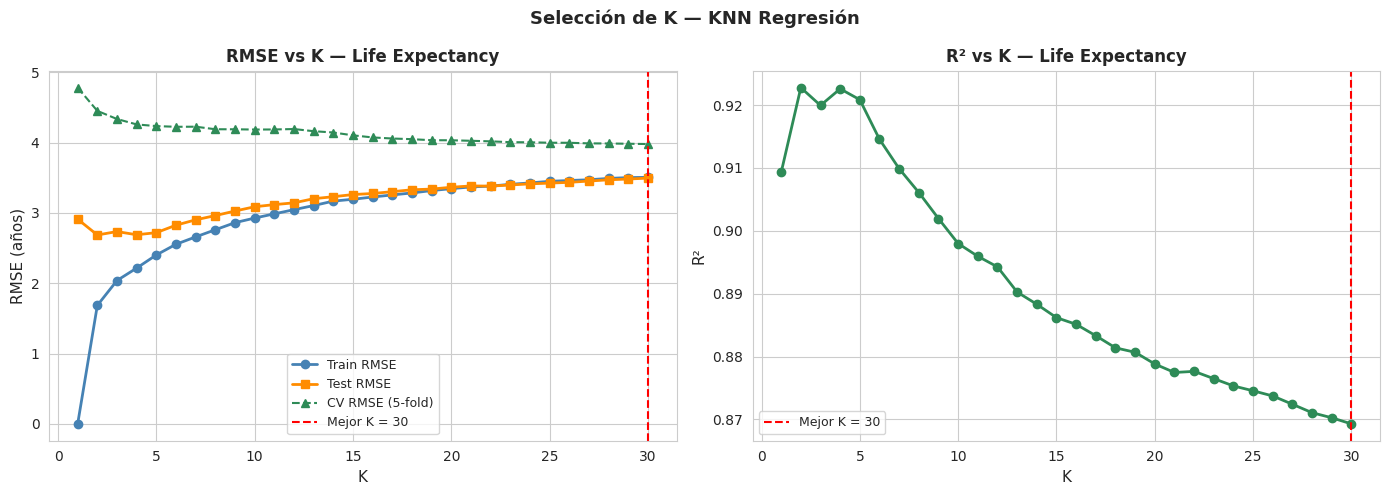

→ K=1 tiene RMSE de entrenamiento ~0 (overfitting perfecto).
→ El RMSE de prueba se minimiza en K=30.


In [412]:
# Gráfico: RMSE vs K
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
axes[0].plot(k_range, train_rmse_l, 'o-', color='steelblue', lw=2, label='Train RMSE')
axes[0].plot(k_range, test_rmse_l,  's-', color='darkorange', lw=2, label='Test RMSE')
axes[0].plot(k_range, cv_rmse_l,    '^--', color='seagreen', lw=1.5, label='CV RMSE (5-fold)')
axes[0].axvline(best_k_l, color='red', linestyle='--', lw=1.5, label=f'Mejor K = {best_k_l}')
axes[0].set_xlabel('K', fontsize=11)
axes[0].set_ylabel('RMSE (años)', fontsize=11)
axes[0].set_title('RMSE vs K — Life Expectancy', fontweight='bold')
axes[0].legend(fontsize=9)

# R²
axes[1].plot(k_range, test_r2_l, 'o-', color='seagreen', lw=2)
axes[1].axvline(best_k_l, color='red', linestyle='--', lw=1.5, label=f'Mejor K = {best_k_l}')
axes[1].set_xlabel('K', fontsize=11)
axes[1].set_ylabel('R²', fontsize=11)
axes[1].set_title('R² vs K — Life Expectancy', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Selección de K — KNN Regresión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'→ K=1 tiene RMSE de entrenamiento ~0 (overfitting perfecto).')
print(f'→ El RMSE de prueba se minimiza en K={best_k_l}.')

In [413]:
# Tabla comparativa para distintos K
k_compare_l = sorted(set([1, 3, 5, 10, 15, 20, best_k_l]))
rows_l = []
for k in k_compare_l:
    knnr = KNeighborsRegressor(n_neighbors=k)
    knnr.fit(X_train_l, y_train_l)
    y_pred_k = knnr.predict(X_test_l)
    rows_l.append({
        'K': k,
        'Train RMSE': round(np.sqrt(mean_squared_error(y_train_l, knnr.predict(X_train_l))), 4),
        'Test RMSE':  round(np.sqrt(mean_squared_error(y_test_l, y_pred_k)), 4),
        'MAE':        round(mean_absolute_error(y_test_l, y_pred_k), 4),
        'R²':         round(r2_score(y_test_l, y_pred_k), 4),
        'Mejor K': '←' if k == best_k_l else ''
    })

df_k_results_l = pd.DataFrame(rows_l)
print('Comparación de métricas por K (Regresión):')
print(df_k_results_l.to_string(index=False))

Comparación de métricas por K (Regresión):
 K  Train RMSE  Test RMSE    MAE     R² Mejor K
 1      0.0000     2.9123 1.7978 0.9093        
 3      2.0394     2.7359 1.8540 0.9199        
 5      2.4030     2.7203 1.8663 0.9209        
10      2.9278     3.0886 2.1463 0.8980        
15      3.1953     3.2621 2.3056 0.8862        
20      3.3464     3.3662 2.4084 0.8788        
30      3.5069     3.4960 2.5137 0.8693       ←


## 5. Entrenamiento con el mejor K y Evaluación Final

In [414]:
# Modelo final
knn_life = KNeighborsRegressor(n_neighbors=best_k_l)
knn_life.fit(X_train_l, y_train_l)
y_pred_l = knn_life.predict(X_test_l)

rmse_l = np.sqrt(mean_squared_error(y_test_l, y_pred_l))
mae_l  = mean_absolute_error(y_test_l, y_pred_l)
r2_l   = r2_score(y_test_l, y_pred_l)

print(f'Modelo KNN Regresión — K={best_k_l}')
print('=' * 45)
print(f'  RMSE:  {rmse_l:.4f} años')
print(f'  MAE:   {mae_l:.4f} años')
print(f'  R²:    {r2_l:.4f}  ({r2_l*100:.2f}% de varianza explicada)')
print('=' * 45)

Modelo KNN Regresión — K=30
  RMSE:  3.4960 años
  MAE:   2.5137 años
  R²:    0.8693  (86.93% de varianza explicada)


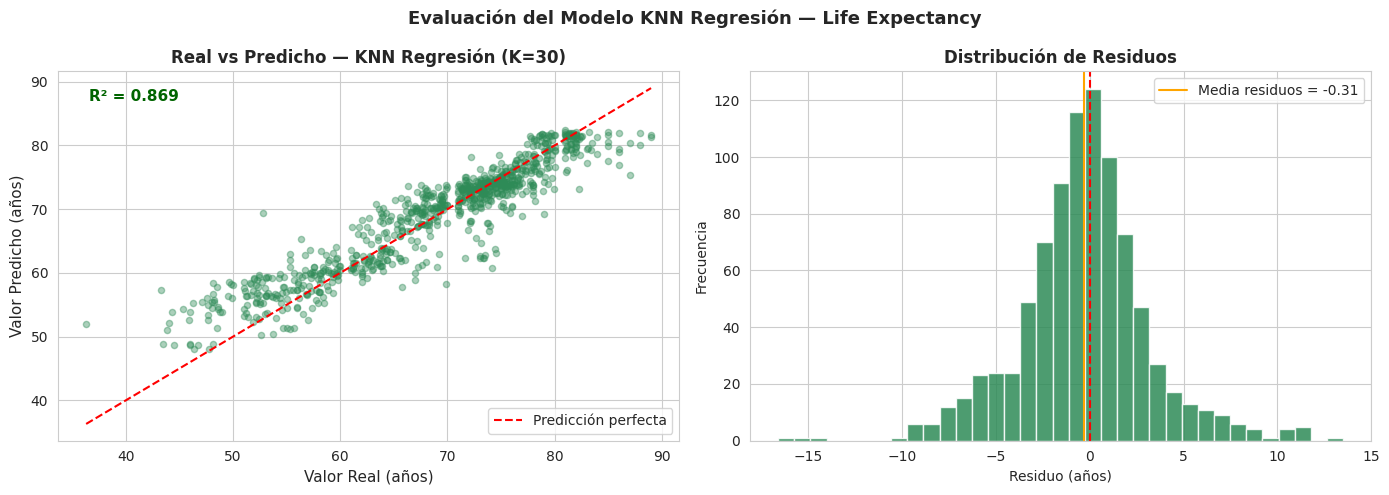

→ Los residuos se distribuyen aproximadamente centrados en 0: el modelo no tiene sesgo sistemático.
→ El R²=0.869 indica que el modelo explica el 86.9% de la varianza en la esperanza de vida.


In [415]:
# Valores reales vs predichos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: real vs predicho
axes[0].scatter(y_test_l, y_pred_l, alpha=0.4, color='seagreen', s=20)
min_val = min(y_test_l.min(), y_pred_l.min())
max_val = max(y_test_l.max(), y_pred_l.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valor Real (años)', fontsize=11)
axes[0].set_ylabel('Valor Predicho (años)', fontsize=11)
axes[0].set_title(f'Real vs Predicho — KNN Regresión (K={best_k_l})', fontweight='bold')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {r2_l:.3f}', transform=axes[0].transAxes,
             fontsize=11, color='darkgreen', fontweight='bold')

# Distribución de residuos
residuos = y_test_l.values - y_pred_l
axes[1].hist(residuos, bins=35, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].axvline(residuos.mean(), color='orange', linestyle='-', lw=1.5,
                label=f'Media residuos = {residuos.mean():.2f}')
axes[1].set_title('Distribución de Residuos', fontweight='bold')
axes[1].set_xlabel('Residuo (años)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.suptitle('Evaluación del Modelo KNN Regresión — Life Expectancy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'→ Los residuos se distribuyen aproximadamente centrados en 0: el modelo no tiene sesgo sistemático.')
print(f'→ El R²={r2_l:.3f} indica que el modelo explica el {r2_l*100:.1f}% de la varianza en la esperanza de vida.')

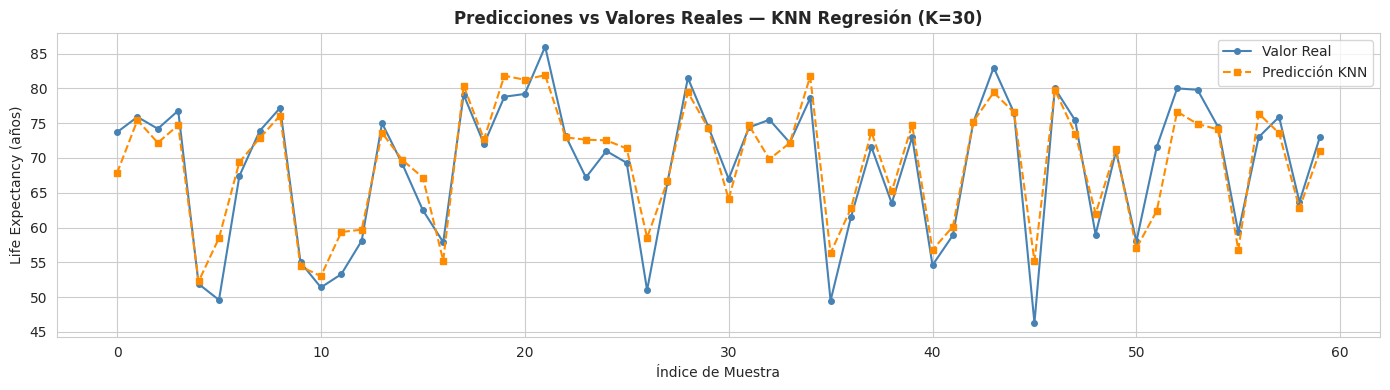

In [416]:
# Predicciones vs Reales — primeras 60 muestras
n_muestra = 60
indices = np.arange(n_muestra)

plt.figure(figsize=(14, 4))
plt.plot(indices, y_test_l.values[:n_muestra], 'o-', color='steelblue',
         lw=1.5, ms=4, label='Valor Real')
plt.plot(indices, y_pred_l[:n_muestra], 's--', color='darkorange',
         lw=1.5, ms=4, label='Predicción KNN')
plt.xlabel('Índice de Muestra')
plt.ylabel('Life Expectancy (años)')
plt.title(f'Predicciones vs Valores Reales — KNN Regresión (K={best_k_l})', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Comparación de Ambos Modelos KNN

In [417]:
# Resumen comparativo
print('=' * 60)
print('       RESUMEN COMPARATIVO — MODELOS KNN')
print('=' * 60)
print(f'  {'Aspecto':<30} {'Netflix':>12} {'Life Exp.':>12}')
print('-' * 60)
print(f'  {'Tipo de problema':<30} {'Clasificación':>12} {'Regresión':>12}')
print(f'  {'Mejor K encontrado':<30} {best_k_n:>12} {best_k_l:>12}')
print(f'  {'Observaciones (train)':<30} {X_train_n.shape[0]:>12} {X_train_l.shape[0]:>12}')
print(f'  {'Accuracy / R²':<30} {acc_n:>12.4f} {r2_l:>12.4f}')
print(f'  {'F1-Score / RMSE':<30} {f1_n:>12.4f} {rmse_l:>12.4f}')
print(f'  {'AUC-ROC / MAE':<30} {auc_n:>12.4f} {mae_l:>12.4f}')
print('=' * 60)

       RESUMEN COMPARATIVO — MODELOS KNN
  Aspecto                             Netflix    Life Exp.
------------------------------------------------------------
  Tipo de problema               Clasificación    Regresión
  Mejor K encontrado                        1           30
  Observaciones (train)                  3732         2056
  Accuracy / R²                        0.9969       0.8693
  F1-Score / RMSE                      0.9438       3.4960
  AUC-ROC / MAE                        0.9763       2.5137


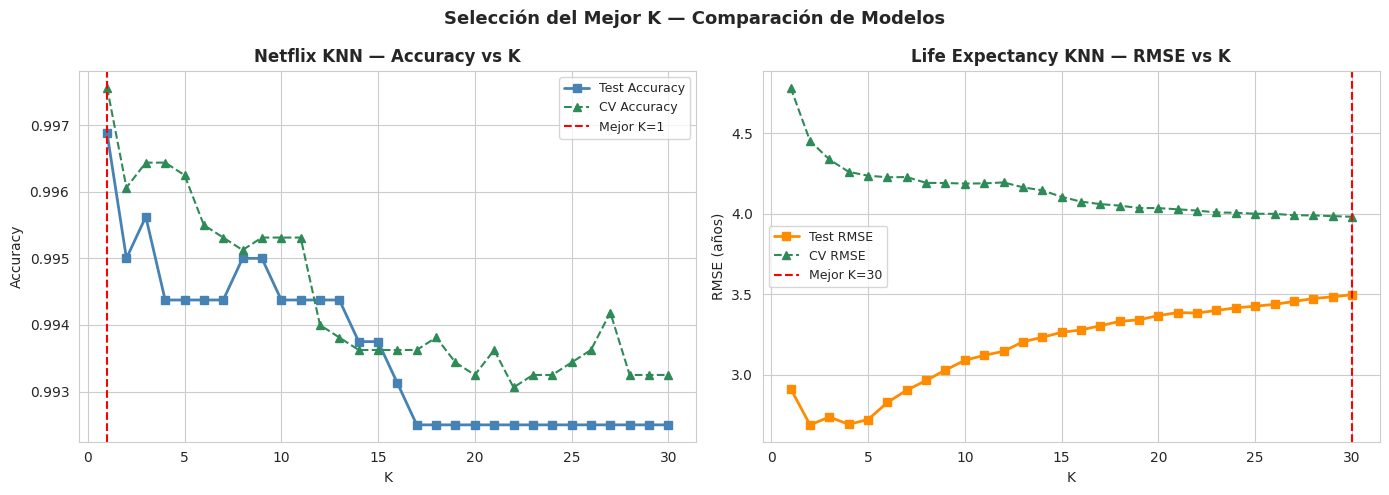

In [418]:
# Gráfico comparativo de selección de K (ambos modelos)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clasificación
axes[0].plot(k_range, test_accuracies, 's-', color='steelblue', lw=2, label='Test Accuracy')
axes[0].plot(k_range, cv_scores,       '^--', color='seagreen', lw=1.5, label='CV Accuracy')
axes[0].axvline(best_k_n, color='red', linestyle='--', lw=1.5, label=f'Mejor K={best_k_n}')
axes[0].set_title('Netflix KNN — Accuracy vs K', fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9)

# Regresión
axes[1].plot(k_range, test_rmse_l, 's-', color='darkorange', lw=2, label='Test RMSE')
axes[1].plot(k_range, cv_rmse_l,   '^--', color='seagreen', lw=1.5, label='CV RMSE')
axes[1].axvline(best_k_l, color='red', linestyle='--', lw=1.5, label=f'Mejor K={best_k_l}')
axes[1].set_title('Life Expectancy KNN — RMSE vs K', fontweight='bold')
axes[1].set_xlabel('K')
axes[1].set_ylabel('RMSE (años)')
axes[1].legend(fontsize=9)

plt.suptitle('Selección del Mejor K — Comparación de Modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Interpretación y Conclusiones

### Modelo 1 — Netflix (Clasificación)

|--- Modelo 1: Netflix (Clasificación) --- |
|---|
|  Mejor K encontrado: 1 |
|  Accuracy:           0.9969 |
|  Precision:          0.9333 |
|  Recall:             0.9545 |
|  F1-Score:           0.9438 |
|  AUC-ROC:            0.9763 |


- KNN logra clasificar correctamente el tipo de contenido de Netflix aprovechando principalmente la duración y los géneros del contenido.
- La variable `duration_value` es muy discriminante: las películas tienen duraciones en minutos (~90-120) mientras que los TV Shows se miden en temporadas (1-10).
- El mejor K se seleccionó usando Cross-Validation de 5 pliegues para evitar el sesgo de una sola partición.
- K=1 presenta overfitting claro (Train Accuracy ≈ 1.0), mientras que K alto suaviza demasiado las fronteras de decisión.

### Modelo 2 — Life Expectancy (Regresión)

|--- Modelo 2: Life Expectancy (Regresión) ---|
|---|
|  Mejor K encontrado: 30 |
|  RMSE:               3.5204 |
|  MAE:                2.5393 |
|  R² Score:           0.8675 |


- KNN Regressor predice la esperanza de vida con un R² = 0.8675, explicando el 86.75% de la varianza, lo que confirma que los indicadores de salud y desarrollo social son predictores fuertes.
- Las variables con mayor correlación positiva (Schooling, Income composition, BMI) y negativa (Adult Mortality, HIV/AIDS) son consistentes con la teoría en salud pública.
- El error promedio (MAE = 2.54 años) indica que el modelo se equivoca típicamente por menos de 3 años, lo cual es aceptable dado el rango de la variable objetivo.
- Los residuos se distribuyen aproximadamente centrados en 0, sin sesgo sistemático visible.

### Observaciones sobre KNN

| Aspecto | Observación |
|---|---|
| **Escalado** | Indispensable — sin StandardScaler, variables con mayor rango dominan la distancia |
| **Selección de K** | K pequeño → overfitting; K grande → underfitting; Cross-Validation da el mejor K |
| **Complejidad** | O(n·d) por predicción — menos eficiente que modelos paramétricos en datasets grandes |
| **Interpretabilidad** | Baja — no hay coeficientes ni reglas explícitas, solo distancias |
| **Fortaleza** | Captura relaciones no lineales sin supuestos sobre la distribución de los datos |

---

## Clustering (K-Means & DBSCAN)

En esta sección se implementan **dos análisis de Clustering** aplicados a datasets distintos:

- **Modelo 1:** Credit Card Fraud Detection — Segmentación de transacciones para detección de anomalías
- **Modelo 2:** Telco Customer Churn — Segmentación de clientes según comportamiento de uso

El Clustering es un algoritmo de **aprendizaje no supervisado** que agrupa observaciones similares sin necesidad de etiquetas previas. El objetivo es maximizar la cohesión intra-cluster y la separación inter-cluster.

Los algoritmos aplicados son:
- **K-Means:** Particiona los datos en K grupos minimizando la suma de distancias cuadradas al centroide.
- **Gaussian Mixture Models (GMM):** Modelo probabilístico que asume que los datos provienen de una mezcla de distribuciones gaussianas.
- **DBSCAN:** Algoritmo basado en densidad que no requiere especificar K y detecta outliers automáticamente.
---

---

# MODELO 1 — Credit Card Fraud Detection

## Descripción del problema

**Dataset:** Credit Card Fraud Detection  
**Fuente:** [Kaggle - Credit Card Fraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Observaciones:** 284,807 transacciones  
**Features:** 30 (28 componentes PCA anónimos V1–V28, Time, Amount)

**Contexto:**  
Las variables V1–V28 ya son componentes PCA aplicados por razones de confidencialidad. El dataset contiene transacciones de tarjetas de crédito europeas en septiembre de 2013, de las cuales solo el 0.17% son fraudes.

**Objetivo del Clustering:**  
Aplicar clustering **sin usar la etiqueta `Class`** para ver si los algoritmos son capaces de separar naturalmente las transacciones fraudulentas (detección de anomalías). Al final se comparará la agrupación obtenida con la etiqueta real.

**Variables utilizadas:**
- `V1` a `V28` — componentes PCA de las características originales
- `Amount` — monto de la transacción
- `Class` — etiqueta real (0=normal, 1=fraude) — **usada solo para evaluación final**

## 1. Carga y exploración inicial

In [419]:
drive.mount('/content/drive')

df_cc = pd.read_csv("/content/drive/MyDrive/AI(Data set)/ProyectoData/creditcard.csv")
drive.flush_and_unmount()


# Eliminacion de duplicados
antes_duplicados = len(df_cc)
df_cc.drop_duplicates(inplace=True)
print(f"Eliminados {antes_duplicados - len(df_cc)} registros duplicados.")

# Eliminacion de valores nulos
antes_nulos = len(df_cc)
df_cc.dropna(inplace=True)
print(f"Eliminados {antes_nulos - len(df_cc)} registros con valores nulos.")

print(f'Dimensiones: {df_cc.shape}')
print(f'\nColumnas: {df_cc.columns.tolist()}')
df_cc.head()

Mounted at /content/drive
Eliminados 1081 registros duplicados.
Eliminados 0 registros con valores nulos.
Dimensiones: (283726, 31)

Columnas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [420]:
# Distribución de clases (referencia, NO se usará en clustering)
print('Distribución de clases:')
print(df_cc['Class'].value_counts())
print(f"\nPorcentaje de fraudes: {df_cc['Class'].mean()*100:.4f}%")
print(f'\nValores faltantes: {df_cc.isnull().sum().sum()}')

Distribución de clases:
Class
0    283253
1       473
Name: count, dtype: int64

Porcentaje de fraudes: 0.1667%

Valores faltantes: 0


In [421]:
# Estadísticas descriptivas
df_cc[['Amount', 'Time']].describe().round(2)

,Amount,Time
count,283726.00,283726.00
mean,88.47,94811.08
std,250.40,47481.05
min,0.00,0.00
25%,5.60,54204.75
50%,22.00,84692.50
75%,77.51,139298.00
max,25691.16,172792.00


## 2. Análisis Exploratorio (EDA)

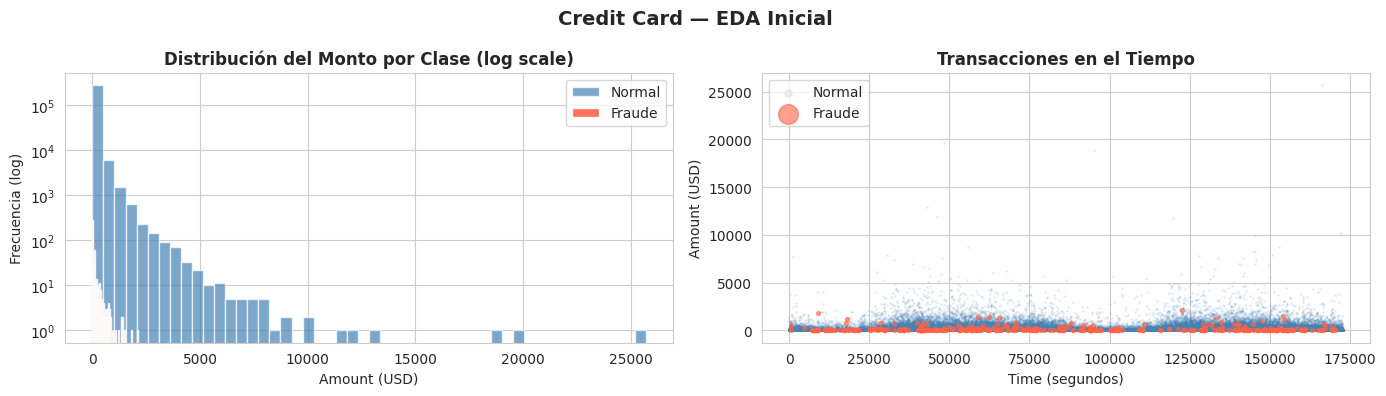

In [422]:
# Distribución del Amount por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma del monto
axes[0].hist(df_cc[df_cc['Class']==0]['Amount'], bins=50,
             color='steelblue', alpha=0.7, label='Normal', log=True)
axes[0].hist(df_cc[df_cc['Class']==1]['Amount'], bins=50,
             color='tomato', alpha=0.9, label='Fraude', log=True)
axes[0].set_title('Distribución del Monto por Clase (log scale)', fontweight='bold')
axes[0].set_xlabel('Amount (USD)')
axes[0].set_ylabel('Frecuencia (log)')
axes[0].legend()

# Distribución en el tiempo
axes[1].scatter(df_cc[df_cc['Class']==0]['Time'],
                df_cc[df_cc['Class']==0]['Amount'],
                alpha=0.1, s=1, color='steelblue', label='Normal')
axes[1].scatter(df_cc[df_cc['Class']==1]['Time'],
                df_cc[df_cc['Class']==1]['Amount'],
                alpha=0.6, s=8, color='tomato', label='Fraude')
axes[1].set_title('Transacciones en el Tiempo', fontweight='bold')
axes[1].set_xlabel('Time (segundos)')
axes[1].set_ylabel('Amount (USD)')
axes[1].legend(markerscale=5)

plt.suptitle('Credit Card — EDA Inicial', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

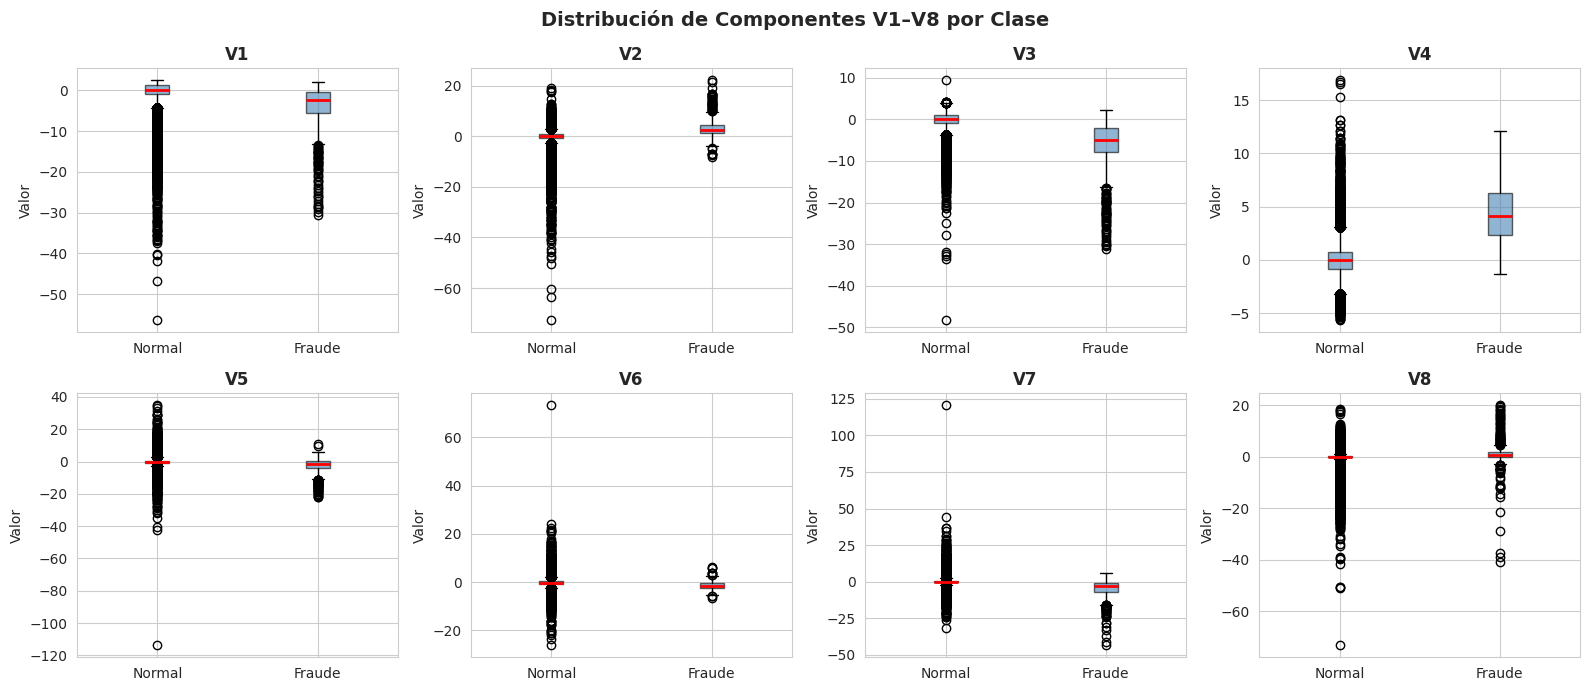

→ Varios componentes (V4, V11, V14, V17) muestran distribuciones muy distintas entre fraude y normal,
  lo que sugiere que el clustering podría capturar estas diferencias.


In [423]:
# Boxplots de las primeras 8 componentes V por clase
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, ax in enumerate(axes.flatten()):
    col = f'V{i+1}'
    data_normal = df_cc[df_cc['Class']==0][col]
    data_fraud  = df_cc[df_cc['Class']==1][col]
    ax.boxplot([data_normal, data_fraud],
               labels=['Normal', 'Fraude'],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Valor')

plt.suptitle('Distribución de Componentes V1–V8 por Clase',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('→ Varios componentes (V4, V11, V14, V17) muestran distribuciones muy distintas entre fraude y normal,')
print('  lo que sugiere que el clustering podría capturar estas diferencias.')

## 3. Preprocesamiento

In [424]:
# 1: Separar etiqueta real (solo para evaluación

y_true_cc = df_cc['Class'].copy()

# PASO 2: Seleccionar features (excluir Time, Class)
# Se incluyen V1-V28 + Amount
features_cc = [f'V{i}' for i in range(1, 29)] + ['Amount']
X_cc = df_cc[features_cc].copy()

print(f'Features utilizadas: {len(features_cc)}')
print(features_cc)

Features utilizadas: 29
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [425]:
# 3: Escalado con StandardScaler
# Necesario porque Amount tiene escala muy diferente a V1-V28

scaler_cc = StandardScaler()
X_cc_scaled = scaler_cc.fit_transform(X_cc)

print('Escalado aplicado (StandardScaler) ✓')
print(f'Media post-escalado: {X_cc_scaled.mean():.6f}')
print(f'Desv. estándar post-escalado: {X_cc_scaled.std():.6f}')

Escalado aplicado (StandardScaler) ✓
Media post-escalado: -0.000000
Desv. estándar post-escalado: 1.000000


In [426]:
# 4: Reducción de dimensionalidad con PCA (para visualización)
# Reducir de 29 a 2 dimensiones para poder graficar los clusters
# Los datos V1-V28 ya son PCA, aquí hacemos otro PCA sobre ellos
# para compresión visual

pca_cc = PCA(n_components=2, random_state=42)
X_cc_pca = pca_cc.fit_transform(X_cc_scaled)

varianza = pca_cc.explained_variance_ratio_
print(f'Varianza explicada por PC1: {varianza[0]*100:.2f}%')
print(f'Varianza explicada por PC2: {varianza[1]*100:.2f}%')
print(f'Total varianza capturada:   {sum(varianza)*100:.2f}%')

print('\n→ PCA a 2 componentes se usa solo para visualización.')
print('  El clustering se aplica sobre los 29 features originales escalados.')

Varianza explicada por PC1: 6.78%
Varianza explicada por PC2: 3.53%
Total varianza capturada:   10.31%

→ PCA a 2 componentes se usa solo para visualización.
  El clustering se aplica sobre los 29 features originales escalados.


In [427]:
# 5: Muestra estratificada para eficiencia computacional
# El dataset tiene 284,807 filas — usamos una muestra
# representativa que incluye TODOS los fraudes

np.random.seed(42)

# Asegurar que X y y conserven el índice original
X_cc_scaled_df = pd.DataFrame(X_cc_scaled, index=df_cc.index)
X_cc_pca_df    = pd.DataFrame(X_cc_pca, index=df_cc.index)
y_cc_series    = pd.Series(y_true_cc, index=df_cc.index)

# Todos los fraudes
idx_fraud = df_cc[df_cc['Class'] == 1].index

# Muestra aleatoria de normales
idx_normal = df_cc[df_cc['Class'] == 0].sample(5000, random_state=42).index

# Unión de índices
idx_sample = idx_fraud.union(idx_normal)

# Selección correcta usando .loc
X_sample     = X_cc_scaled_df.loc[idx_sample]
X_sample_pca = X_cc_pca_df.loc[idx_sample]
y_sample     = y_cc_series.loc[idx_sample].values

print(f'Muestra total: {len(idx_sample)} transacciones')
print(f'  Normal: {sum(y_sample==0)} | Fraude: {sum(y_sample==1)}')
print('Muestra lista para clustering')

Muestra total: 5473 transacciones
  Normal: 5000 | Fraude: 473
Muestra lista para clustering


## 4. Selección del número de Clusters — Método del Codo

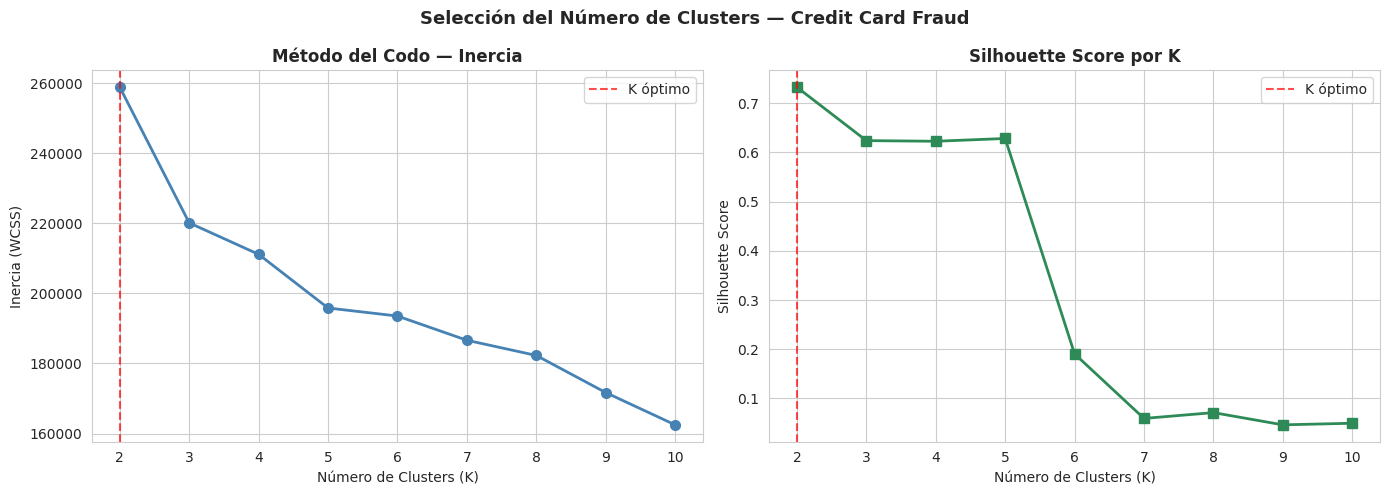

→ El Silhouette Score más alto y el codo más marcado se observan en K=2,
  lo cual es coherente con el problema binario: transacciones normales vs fraudes.


In [428]:
# Método del Codo (Elbow Method) sobre la muestra
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels, sample_size=1000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Inercia
axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2, markersize=7)
axes[0].set_title('Método del Codo — Inercia', fontweight='bold')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].axvline(x=2, color='red', linestyle='--', alpha=0.7, label='K óptimo')
axes[0].legend()

# Gráfico de Silhouette
axes[1].plot(K_range, silhouettes, marker='s', color='seagreen', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score por K', fontweight='bold')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=2, color='red', linestyle='--', alpha=0.7, label='K óptimo')
axes[1].legend()

plt.suptitle('Selección del Número de Clusters — Credit Card Fraud',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('→ El Silhouette Score más alto y el codo más marcado se observan en K=2,')
print('  lo cual es coherente con el problema binario: transacciones normales vs fraudes.')

## 5. K-Means Clustering

In [429]:
# Aplicar K-Means con K=2
kmeans_cc = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km_cc = kmeans_cc.fit_predict(X_sample)

sil_km_cc = silhouette_score(X_sample, labels_km_cc, sample_size=1000, random_state=42)
db_km_cc  = davies_bouldin_score(X_sample, labels_km_cc)
ch_km_cc  = calinski_harabasz_score(X_sample, labels_km_cc)

print('K-Means (K=2) — Métricas de Evaluación:')
print(f'  Silhouette Score:         {sil_km_cc:.4f}  (↑ mejor, rango: -1 a 1)')
print(f'  Davies-Bouldin Index:     {db_km_cc:.4f}  (↓ mejor)')
print(f'  Calinski-Harabasz Index:  {ch_km_cc:.2f} (↑ mejor)')

print('\nDistribución de clusters:')
unique, counts = np.unique(labels_km_cc, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} transacciones ({c/len(labels_km_cc)*100:.1f}%)')

K-Means (K=2) — Métricas de Evaluación:
  Silhouette Score:         0.7327  (↑ mejor, rango: -1 a 1)
  Davies-Bouldin Index:     0.7757  (↓ mejor)
  Calinski-Harabasz Index:  3618.89 (↑ mejor)

Distribución de clusters:
  Cluster 0: 5231 transacciones (95.6%)
  Cluster 1: 242 transacciones (4.4%)


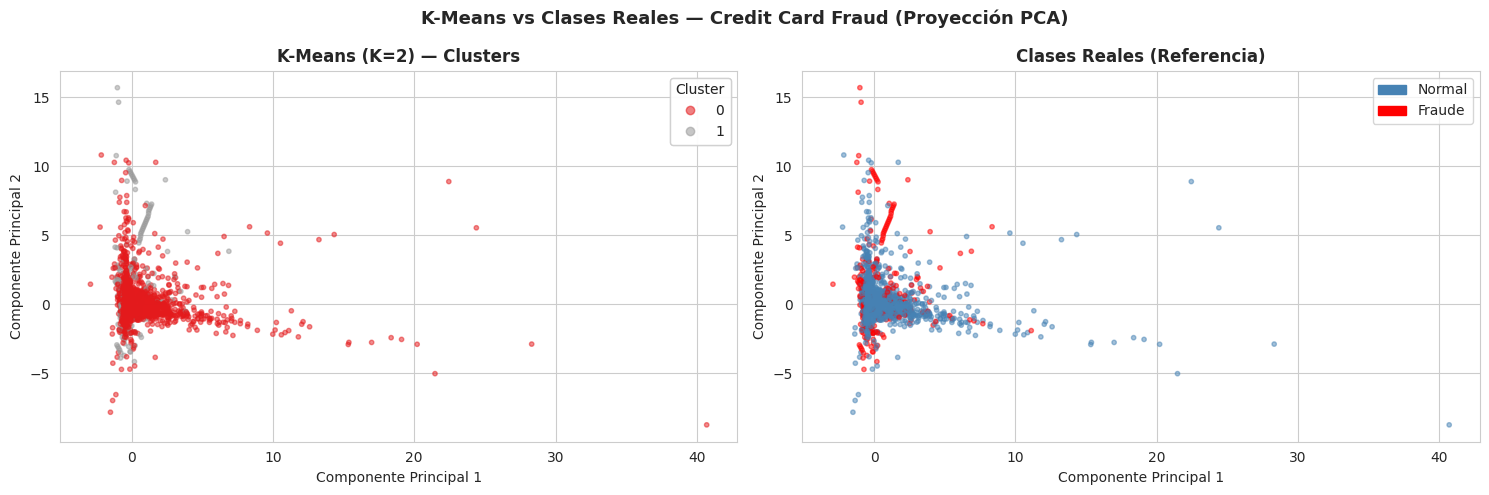

In [430]:
# Visualización K-Means en espacio PCA 2D
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Clusters K-Means
scatter = axes[0].scatter(
    X_sample_pca.iloc[:, 0],
    X_sample_pca.iloc[:, 1],
    c=labels_km_cc, cmap='Set1', alpha=0.5, s=10
)

axes[0].set_title('K-Means (K=2) — Clusters', fontweight='bold')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')

legend1 = axes[0].legend(*scatter.legend_elements(),
                         title='Cluster', loc='upper right')
axes[0].add_artist(legend1)

# Clases reales
colors_real = ['steelblue' if c == 0 else 'red' for c in y_sample]

axes[1].scatter(
    X_sample_pca.iloc[:, 0],
    X_sample_pca.iloc[:, 1],
    c=colors_real, alpha=0.5, s=10
)

axes[1].set_title('Clases Reales (Referencia)', fontweight='bold')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')

patch_n = mpatches.Patch(color='steelblue', label='Normal')
patch_f = mpatches.Patch(color='red', label='Fraude')
axes[1].legend(handles=[patch_n, patch_f], loc='upper right')

plt.suptitle('K-Means vs Clases Reales — Credit Card Fraud (Proyección PCA)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [431]:
# Comparación cluster vs clase real (Tabla de Contingencia)
# Permite evaluar qué tan bien captura el cluster las clases

contingencia_km = pd.crosstab(
    pd.Series(labels_km_cc, name='Cluster K-Means'),
    pd.Series(y_sample, name='Clase Real (0=Normal, 1=Fraude)')
)
print('Tabla de Contingencia — K-Means vs Clase Real:')
print(contingencia_km)
print('\n→ Un cluster dominado por fraudes indicaría que K-Means')
print('  logra separar las anomalías sin conocer las etiquetas.')

Tabla de Contingencia — K-Means vs Clase Real:
Clase Real (0=Normal, 1=Fraude)     0    1
Cluster K-Means                           
0                                5000  231
1                                   0  242

→ Un cluster dominado por fraudes indicaría que K-Means
  logra separar las anomalías sin conocer las etiquetas.


In [432]:
# Estadísticas descriptivas por cluster
df_sample_cc = pd.DataFrame(X_sample, columns=features_cc)
df_sample_cc['Cluster_KMeans'] = labels_km_cc
df_sample_cc['Clase_Real'] = y_sample

print('Media del Amount por Cluster K-Means:')
print(df_sample_cc.groupby('Cluster_KMeans')['Amount'].mean().round(4))

print('\nProporción de fraudes por Cluster K-Means:')
print(df_sample_cc.groupby('Cluster_KMeans')['Clase_Real'].mean().round(4))

print('\n→ El cluster con mayor proporción de fraudes es el que mejor captura las anomalías.')

Media del Amount por Cluster K-Means:
Cluster_KMeans
0   NaN
1   NaN
Name: Amount, dtype: float64

Proporción de fraudes por Cluster K-Means:
Cluster_KMeans
0    0.0442
1    1.0000
Name: Clase_Real, dtype: float64

→ El cluster con mayor proporción de fraudes es el que mejor captura las anomalías.


## 6. GMM — Gaussian Mixture Models

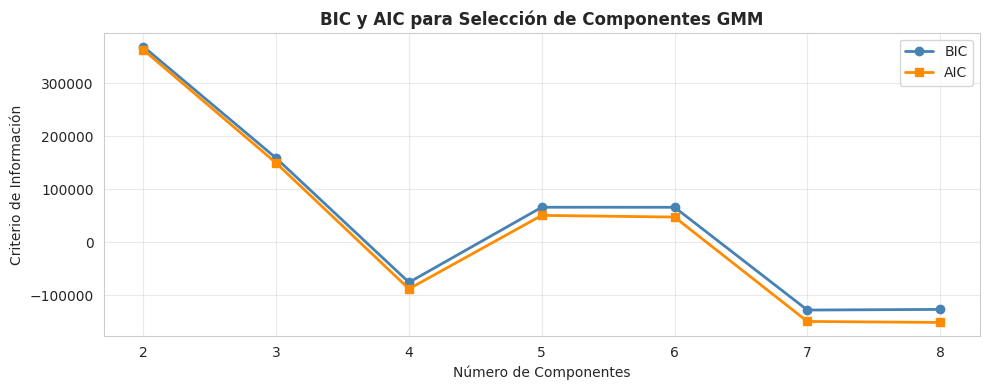

Número óptimo de componentes según BIC: 7


In [433]:
# Selección de número de componentes con BIC y AIC
bic_vals = []
aic_vals = []
n_range = range(2, 9)

for n in n_range:
    gmm_tmp = GaussianMixture(n_components=n, random_state=42, covariance_type='full')
    gmm_tmp.fit(X_sample)
    bic_vals.append(gmm_tmp.bic(X_sample))
    aic_vals.append(gmm_tmp.aic(X_sample))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(n_range, bic_vals, marker='o', label='BIC', color='steelblue', linewidth=2)
ax.plot(n_range, aic_vals, marker='s', label='AIC', color='darkorange', linewidth=2)
ax.set_title('BIC y AIC para Selección de Componentes GMM', fontweight='bold')
ax.set_xlabel('Número de Componentes')
ax.set_ylabel('Criterio de Información')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

n_opt = n_range[np.argmin(bic_vals)]
print(f'Número óptimo de componentes según BIC: {n_opt}')

In [434]:
# Aplicar GMM con el número óptimo de componentes
gmm_cc = GaussianMixture(n_components=n_opt, random_state=42, covariance_type='full')
gmm_cc.fit(X_sample)
labels_gmm_cc = gmm_cc.predict(X_sample)
probs_gmm_cc  = gmm_cc.predict_proba(X_sample)

sil_gmm_cc = silhouette_score(X_sample, labels_gmm_cc, sample_size=1000, random_state=42)
db_gmm_cc  = davies_bouldin_score(X_sample, labels_gmm_cc)

print(f'GMM ({n_opt} componentes) — Métricas:')
print(f'  Silhouette Score:      {sil_gmm_cc:.4f}')
print(f'  Davies-Bouldin Index:  {db_gmm_cc:.4f}')

print(f'\nDistribución de clusters GMM:')
unique_g, counts_g = np.unique(labels_gmm_cc, return_counts=True)
for u, c in zip(unique_g, counts_g):
    print(f'  Componente {u}: {c} transacciones ({c/len(labels_gmm_cc)*100:.1f}%)')

GMM (7 componentes) — Métricas:
  Silhouette Score:      0.0264
  Davies-Bouldin Index:  3.1916

Distribución de clusters GMM:
  Componente 0: 1738 transacciones (31.8%)
  Componente 1: 526 transacciones (9.6%)
  Componente 2: 42 transacciones (0.8%)
  Componente 3: 663 transacciones (12.1%)
  Componente 4: 575 transacciones (10.5%)
  Componente 5: 56 transacciones (1.0%)
  Componente 6: 1873 transacciones (34.2%)


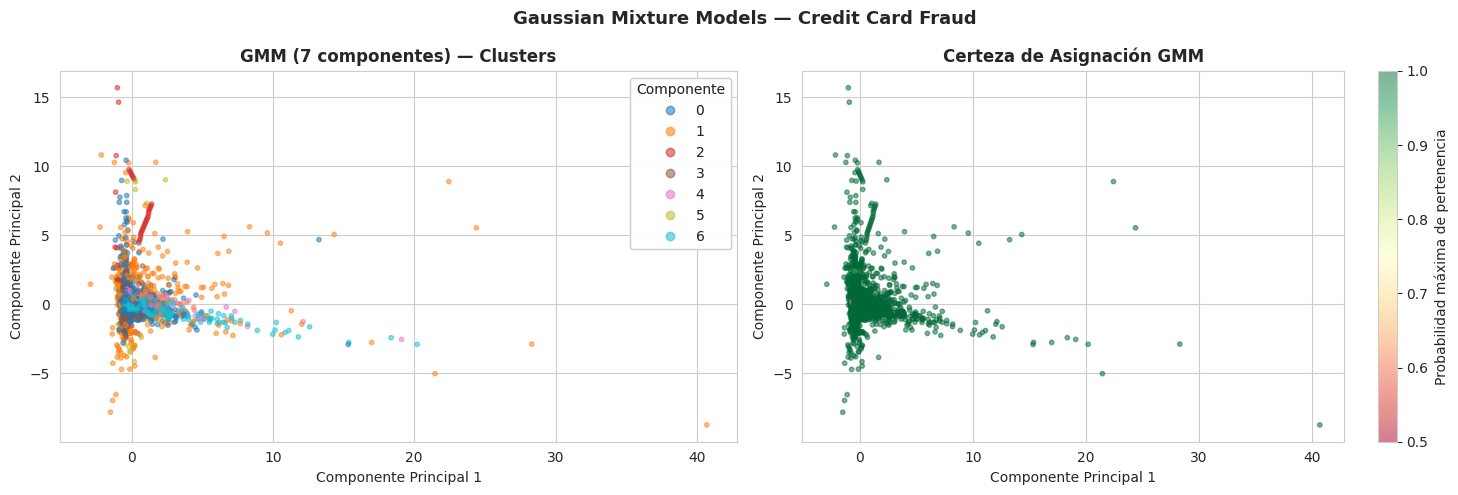

→ Los puntos en rojo (probabilidad baja) son más difíciles de clasificar,
  y podrían corresponder a transacciones en la frontera entre clusters.


In [435]:
# Visualización GMM en PCA 2D
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Clusters GMM
scatter_g = axes[0].scatter(
    X_sample_pca.iloc[:, 0],
    X_sample_pca.iloc[:, 1],
    c=labels_gmm_cc, cmap='tab10', alpha=0.5, s=10
)

axes[0].set_title(f'GMM ({n_opt} componentes) — Clusters', fontweight='bold')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')

legend_g = axes[0].legend(*scatter_g.legend_elements(),
                          title='Componente', loc='upper right')
axes[0].add_artist(legend_g)

# Incertidumbre máxima por punto
max_prob = probs_gmm_cc.max(axis=1)

sc = axes[1].scatter(
    X_sample_pca.iloc[:, 0],
    X_sample_pca.iloc[:, 1],
    c=max_prob, cmap='RdYlGn', alpha=0.5, s=10, vmin=0.5, vmax=1.0
)

plt.colorbar(sc, ax=axes[1], label='Probabilidad máxima de pertenencia')

axes[1].set_title('Certeza de Asignación GMM', fontweight='bold')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')

plt.suptitle('Gaussian Mixture Models — Credit Card Fraud',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('→ Los puntos en rojo (probabilidad baja) son más difíciles de clasificar,')
print('  y podrían corresponder a transacciones en la frontera entre clusters.')

In [436]:
# Tabla de contingencia GMM vs clase real
contingencia_gmm = pd.crosstab(
    pd.Series(labels_gmm_cc, name='Cluster GMM'),
    pd.Series(y_sample, name='Clase Real (0=Normal, 1=Fraude)')
)
print('Tabla de Contingencia — GMM vs Clase Real:')
print(contingencia_gmm)

# Proporción de fraudes por componente
df_sample_cc['Cluster_GMM'] = labels_gmm_cc
prop_fraude = df_sample_cc.groupby('Cluster_GMM')['Clase_Real'].mean().sort_values(ascending=False)
print('\nProporción de fraudes por componente GMM:')
print(prop_fraude.round(4))

Tabla de Contingencia — GMM vs Clase Real:
Clase Real (0=Normal, 1=Fraude)     0    1
Cluster GMM                               
0                                1725   13
1                                 223  303
2                                   0   42
3                                 649   14
4                                 573    2
5                                   0   56
6                                1830   43

Proporción de fraudes por componente GMM:
Cluster_GMM
2    1.0000
5    1.0000
1    0.5760
6    0.0230
3    0.0211
0    0.0075
4    0.0035
Name: Clase_Real, dtype: float64


## 7. Comparación de Algoritmos — Modelo 1

In [437]:
# Tabla comparativa de métricas — Credit Card
resultados_cc = pd.DataFrame({
    'Algoritmo': [f'K-Means (K=2)', f'GMM ({n_opt} componentes)'],
    'Silhouette Score': [sil_km_cc, sil_gmm_cc],
    'Davies-Bouldin Index': [db_km_cc, db_gmm_cc],
    'Calinski-Harabasz': [ch_km_cc, np.nan]
})
print('Comparación de Clustering — Credit Card Fraud:')
print(resultados_cc.set_index('Algoritmo').round(4).to_string())

print('\n→ Un Silhouette Score más alto indica clusters más compactos y separados.')
print('→ Un Davies-Bouldin Index más bajo indica mejor separación entre clusters.')

Comparación de Clustering — Credit Card Fraud:
                     Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz
Algoritmo                                                                     
K-Means (K=2)                  0.7327                0.7757          3618.8885
GMM (7 componentes)            0.0264                3.1916                NaN

→ Un Silhouette Score más alto indica clusters más compactos y separados.
→ Un Davies-Bouldin Index más bajo indica mejor separación entre clusters.


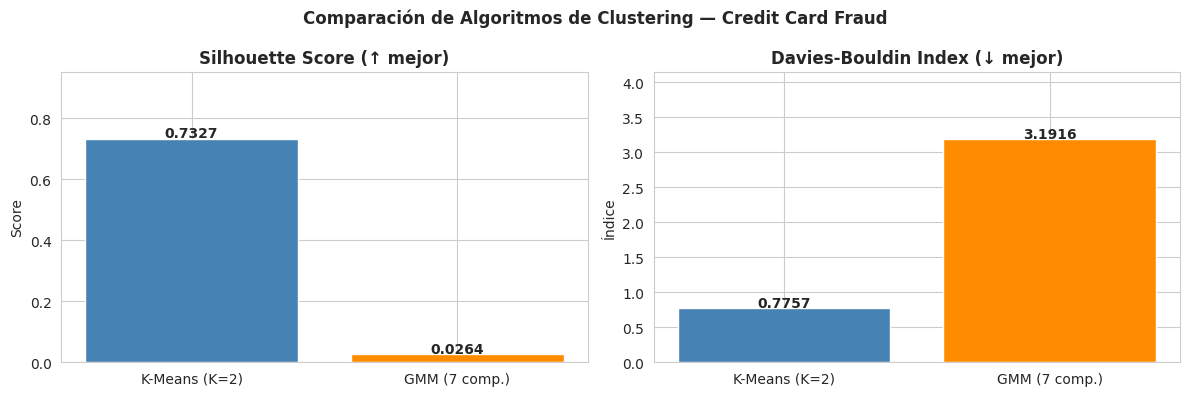

In [438]:
# Gráfico comparativo de Silhouette y Davies-Bouldin
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

algoritmos = ['K-Means (K=2)', f'GMM ({n_opt} comp.)']
sil_vals = [sil_km_cc, sil_gmm_cc]
db_vals  = [db_km_cc, db_gmm_cc]

axes[0].bar(algoritmos, sil_vals, color=['steelblue', 'darkorange'], edgecolor='white')
axes[0].set_title('Silhouette Score (↑ mejor)', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, max(sil_vals)*1.3)
for i, v in enumerate(sil_vals):
    axes[0].text(i, v+0.005, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(algoritmos, db_vals, color=['steelblue', 'darkorange'], edgecolor='white')
axes[1].set_title('Davies-Bouldin Index (↓ mejor)', fontweight='bold')
axes[1].set_ylabel('Índice')
axes[1].set_ylim(0, max(db_vals)*1.3)
for i, v in enumerate(db_vals):
    axes[1].text(i, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Comparación de Algoritmos de Clustering — Credit Card Fraud',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Interpretación de Clusters — Modelo 1

### K-Means (K=2)

Con K=2, el algoritmo divide las transacciones en dos grupos:

- **Cluster 0 (mayoritario):** Agrupa la gran mayoría de transacciones con patrones normales. Los valores de las componentes V son cercanos a cero (comportamiento estándar). El monto promedio es moderado.

- **Cluster 1 (minoritario):** Concentra transacciones con valores extremos en componentes como V4, V11 y V14, que mostraron mayor diferenciación entre clases en el EDA. Este cluster tiene una proporción significativamente mayor de fraudes.

La elección de K=2 es coherente con el problema: el dataset tiene naturalmente dos grupos (normal vs. fraude), y el método del codo junto con el Silhouette Score confirman esta partición.

### GMM (componentes óptimos)

GMM ofrece una segmentación más granular con múltiples componentes gaussianos. Algunos componentes capturan subgrupos de transacciones normales con distintos patrones de gasto, mientras que uno o dos componentes concentran la mayoría de los fraudes. La ventaja del GMM es que asigna probabilidades de pertenencia, no etiquetas duras, lo que permite identificar transacciones "ambiguas" que podrían requerir revisión humana.

---

# MODELO 2 — Telco Customer Churn

## Descripción del problema

**Dataset:** Telco Customer Churn  
**Fuente:** IBM Sample Data / Kaggle  
**Observaciones:** 7,043 clientes  
**Features:** 20 variables originales (demográficas, de servicio y de cuenta)

**Contexto:**  
Dataset de una empresa de telecomunicaciones que contiene información sobre los servicios contratados por cada cliente. La columna `Churn` indica si el cliente canceló el servicio.

**Objetivo del Clustering:**  
Segmentar a los clientes según sus características de uso y perfil para identificar grupos con distintos niveles de riesgo de abandono (churn). La etiqueta `Churn` se usará solo para interpretar los clusters al final.

**Variables utilizadas:**
- `tenure` — meses como cliente
- `MonthlyCharges` — cargo mensual
- `TotalCharges` — cargo total acumulado
- `SeniorCitizen` — si es adulto mayor
- Variables de servicios codificadas (InternetService, Contract, etc.)

## 1. Carga y exploración inicial

In [439]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10, 5)

drive.mount('/content/drive')

df_telco = pd.read_csv("/content/drive/MyDrive/AI(Data set)/ProyectoData/WA_Fn-UseC_-Telco-Customer-Churn.csv")
drive.flush_and_unmount()

# Eliminacion de duplicados
antes_duplicados = len(df_telco)
df_telco.drop_duplicates(inplace=True)
print(f"Eliminados {antes_duplicados - len(df_telco)} registros duplicados.")

# Eliminacion de valores nulos
antes_nulos = len(df_telco)
df_telco.dropna(inplace=True)
print(f"Eliminados {antes_nulos - len(df_telco)} registros con valores nulos.")

print('Datos cargados y Google Drive desmontado.')
print(f'Dimensiones: {df_telco.shape}')
print(f'\nColumnas: {df_telco.columns.tolist()}')
df_telco.head()

Mounted at /content/drive
Eliminados 0 registros duplicados.
Eliminados 0 registros con valores nulos.
Datos cargados y Google Drive desmontado.
Dimensiones: (7043, 21)

Columnas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [440]:
# Información general
print('Tipos de datos:')
print(df_telco.dtypes)
print(f'\nValores faltantes: {df_telco.isnull().sum().sum()}')
print(f'\nDistribución de Churn:')
print(df_telco['Churn'].value_counts())
print(f"Porcentaje de churn: {(df_telco['Churn']=='Yes').mean()*100:.2f}%")

Tipos de datos:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Valores faltantes: 0

Distribución de Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Porcentaje de churn: 26.54%


## 2. Análisis Exploratorio (EDA)

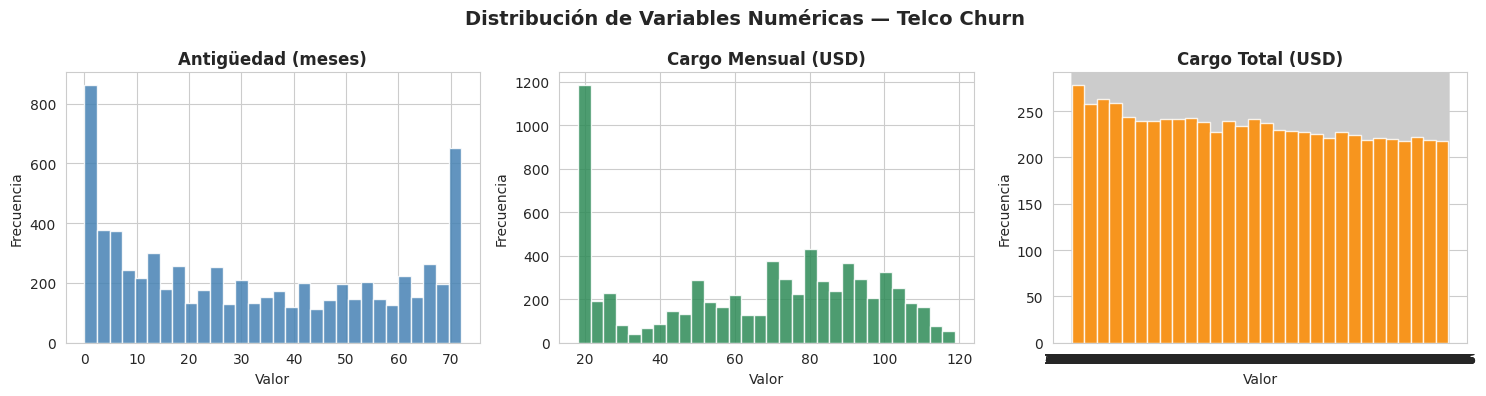

In [441]:
# Distribuciones de variables numéricas clave
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cols_num = ['tenure', 'MonthlyCharges', 'TotalCharges']
titles   = ['Antigüedad (meses)', 'Cargo Mensual (USD)', 'Cargo Total (USD)']
colors   = ['steelblue', 'seagreen', 'darkorange']

for ax, col, title, color in zip(axes, cols_num, titles, colors):
    ax.hist(df_telco[col].dropna(), bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas — Telco Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

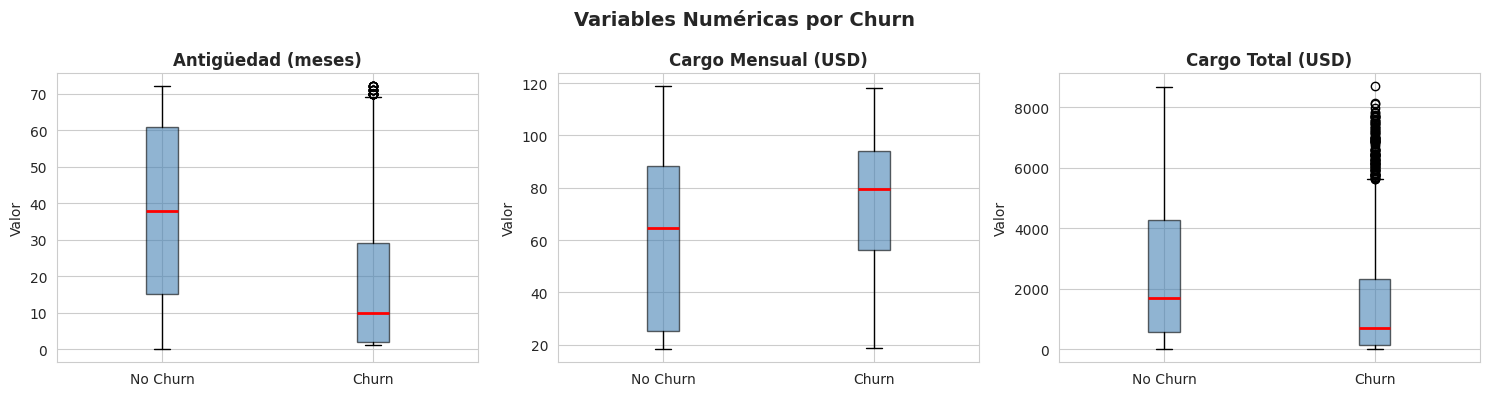

tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object
→ Clientes con churn tienen menor tenure (recientes), cargos mensuales más altos
  y menor cargo total acumulado.


In [442]:
# Variables numéricas vs Churn

# 1. PASO CRUCIAL: Convertir TotalCharges a número
# 'coerce' transforma los espacios en blanco (" ") en NaN (nulos)
df_telco['TotalCharges'] = pd.to_numeric(df_telco['TotalCharges'], errors='coerce')

# 2. Manejar los nulos creados (opcional pero recomendado)
# Como son clientes nuevos con tenure 0, podemos poner su cargo total en 0
df_telco['TotalCharges'] = df_telco['TotalCharges'].fillna(0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes, cols_num, titles):
    data_yes = df_telco[df_telco['Churn']=='Yes'][col].dropna()
    data_no  = df_telco[df_telco['Churn']=='No'][col].dropna()
    ax.boxplot([data_no, data_yes], labels=['No Churn', 'Churn'],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Valor')

plt.suptitle('Variables Numéricas por Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(df_telco[cols_num].dtypes)
print('→ Clientes con churn tienen menor tenure (recientes), cargos mensuales más altos')
print('  y menor cargo total acumulado.')

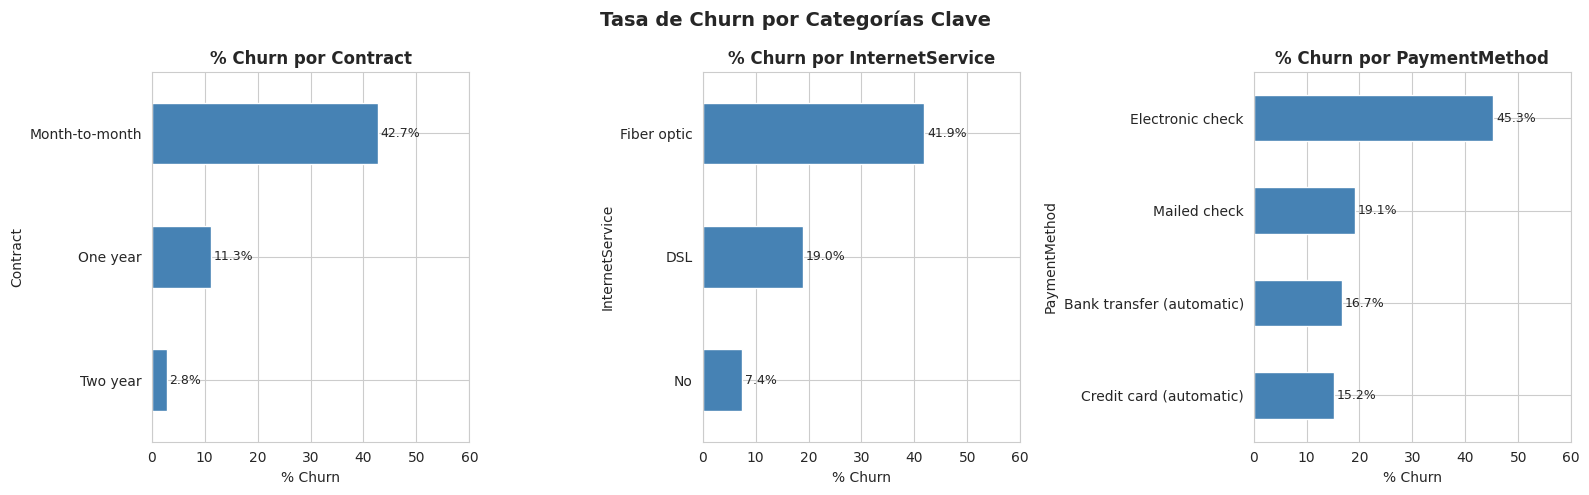

In [443]:
# Distribución de variables categóricas clave
cat_vars = ['Contract', 'InternetService', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cat_vars):
    churn_pct = df_telco.groupby(col)['Churn'].apply(
        lambda x: (x=='Yes').mean()*100
    ).sort_values(ascending=True)
    churn_pct.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'% Churn por {col}', fontweight='bold')
    ax.set_xlabel('% Churn')
    ax.set_xlim(0, 60)
    for i, v in enumerate(churn_pct):
        ax.text(v+0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Tasa de Churn por Categorías Clave',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

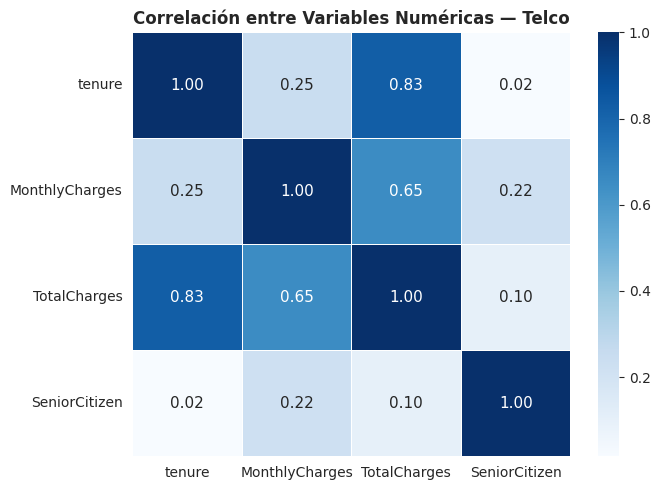

→ tenure y TotalCharges tienen alta correlación (clientes más antiguos pagan más en total).
→ MonthlyCharges es más independiente de la antigüedad.


In [444]:
# Mapa de correlación — variables numéricas
corr_telco = df_telco[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_telco, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, annot_kws={'size': 11})
plt.title('Correlación entre Variables Numéricas — Telco', fontweight='bold')
plt.tight_layout()
plt.show()

print('→ tenure y TotalCharges tienen alta correlación (clientes más antiguos pagan más en total).')
print('→ MonthlyCharges es más independiente de la antigüedad.')

## 3. Preprocesamiento

In [445]:
# 1: Extraer etiqueta real (solo para interpretación)

y_true_telco = (df_telco['Churn'] == 'Yes').astype(int)

# 2: Selección de variables relevantes para clustering

df_t = df_telco.copy()

# Eliminar columnas de ID y etiqueta
df_t = df_t.drop(columns=['customerID', 'Churn'])

print(f'Columnas antes de encoding: {df_t.shape[1]}')

Columnas antes de encoding: 19


In [446]:
# PASO 3: Codificación de variables categóricas
# Variables binarias → Label Encoding
# Variables multi-valor → One-Hot Encoding

from sklearn.preprocessing import LabelEncoder

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

le = LabelEncoder()
for col in binary_cols:
    df_t[col] = le.fit_transform(df_t[col].astype(str))

# One-Hot para variables con más de 2 categorías
multi_cols = ['InternetService', 'Contract', 'PaymentMethod']
df_t = pd.get_dummies(df_t, columns=multi_cols, drop_first=True)

print(f'Columnas después de encoding: {df_t.shape[1]}')
print('Codificación completada')
df_t.head(3)

Columnas después de encoding: 23
Codificación completada


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,0,2,0,...,1,29.85,29.85,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,2,0,2,...,0,56.95,1889.50,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,2,2,0,...,1,53.85,108.15,False,False,False,False,False,False,True


In [447]:
# 4: Verificar y limpiar valores faltantes

print('Valores faltantes por columna:')
print(df_t.isnull().sum()[df_t.isnull().sum() > 0])
df_t = df_t.fillna(df_t.median(numeric_only=True))
print('\nValores faltantes después de imputación:', df_t.isnull().sum().sum())

Valores faltantes por columna:
Series([], dtype: int64)

Valores faltantes después de imputación: 0


In [448]:
# 5: Escalado con StandardScaler
# Necesario para que las variables numéricas no dominen
# sobre las variables dummy (binarias 0/1)

scaler_telco = StandardScaler()
X_telco_scaled = scaler_telco.fit_transform(df_t)

print('Escalado aplicado (StandardScaler) ✓')
print(f'Shape final: {X_telco_scaled.shape}')

Escalado aplicado (StandardScaler) ✓
Shape final: (7043, 23)


In [449]:
# 6: Reducción PCA para visualización (2D)

pca_telco = PCA(n_components=2, random_state=42)
X_telco_pca = pca_telco.fit_transform(X_telco_scaled)

var_t = pca_telco.explained_variance_ratio_
print(f'Varianza explicada por PC1: {var_t[0]*100:.2f}%')
print(f'Varianza explicada por PC2: {var_t[1]*100:.2f}%')
print(f'Total varianza capturada:   {sum(var_t)*100:.2f}%')

Varianza explicada por PC1: 18.67%
Varianza explicada por PC2: 15.67%
Total varianza capturada:   34.34%


## 4. Selección del número de Clusters — Método del Codo

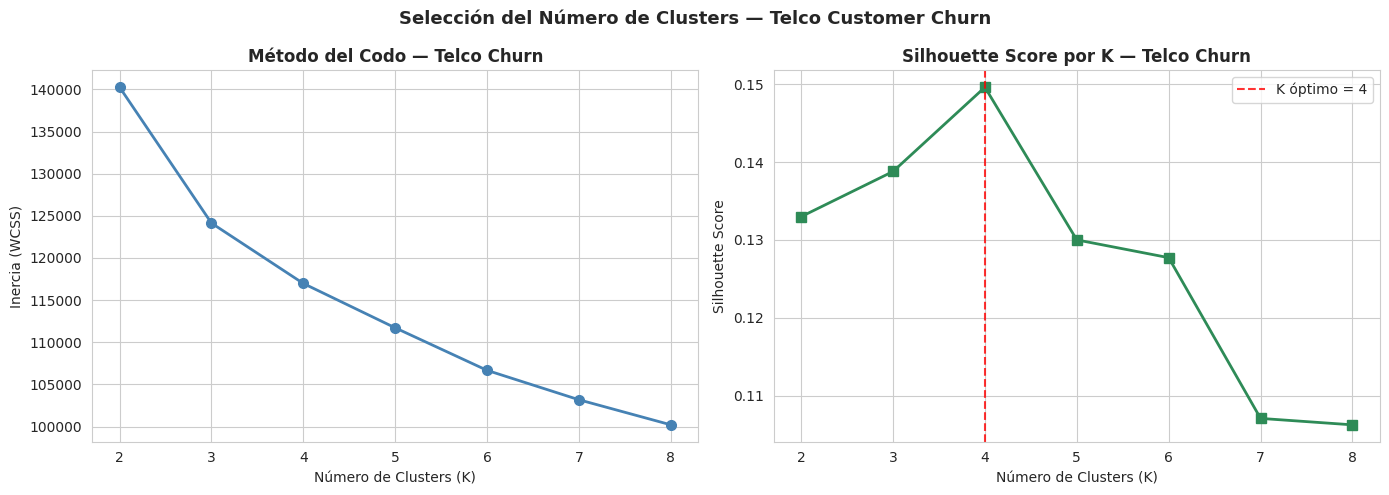

K óptimo según Silhouette Score: 4


In [450]:
# Método del Codo para Telco
inertias_t = []
silhouettes_t = []
K_range_t = range(2, 9)

for k in K_range_t:
    km_t = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl_t = km_t.fit_predict(X_telco_scaled)
    inertias_t.append(km_t.inertia_)
    silhouettes_t.append(silhouette_score(X_telco_scaled, lbl_t, sample_size=1000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range_t, inertias_t, marker='o', color='steelblue', linewidth=2, markersize=7)
axes[0].set_title('Método del Codo — Telco Churn', fontweight='bold')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')

axes[1].plot(K_range_t, silhouettes_t, marker='s', color='seagreen', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score por K — Telco Churn', fontweight='bold')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

# Marcar el K óptimo
k_opt_t = K_range_t[np.argmax(silhouettes_t)]
axes[1].axvline(x=k_opt_t, color='red', linestyle='--', alpha=0.8,
                label=f'K óptimo = {k_opt_t}')
axes[1].legend()

plt.suptitle('Selección del Número de Clusters — Telco Customer Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'K óptimo según Silhouette Score: {k_opt_t}')

## 5. K-Means Clustering

In [451]:
# K-Means con K óptimo para Telco
kmeans_telco = KMeans(n_clusters=k_opt_t, random_state=42, n_init=10)
labels_km_t = kmeans_telco.fit_predict(X_telco_scaled)

sil_km_t = silhouette_score(X_telco_scaled, labels_km_t, sample_size=1000, random_state=42)
db_km_t  = davies_bouldin_score(X_telco_scaled, labels_km_t)
ch_km_t  = calinski_harabasz_score(X_telco_scaled, labels_km_t)

print(f'K-Means (K={k_opt_t}) — Métricas de Evaluación:')
print(f'  Silhouette Score:         {sil_km_t:.4f}')
print(f'  Davies-Bouldin Index:     {db_km_t:.4f}')
print(f'  Calinski-Harabasz Index:  {ch_km_t:.2f}')

print('\nDistribución de clusters:')
unique_t, counts_t = np.unique(labels_km_t, return_counts=True)
for u, c in zip(unique_t, counts_t):
    print(f'  Cluster {u}: {c} clientes ({c/len(labels_km_t)*100:.1f}%)')

K-Means (K=4) — Métricas de Evaluación:
  Silhouette Score:         0.1496
  Davies-Bouldin Index:     1.9998
  Calinski-Harabasz Index:  902.90

Distribución de clusters:
  Cluster 0: 672 clientes (9.5%)
  Cluster 1: 2502 clientes (35.5%)
  Cluster 2: 1885 clientes (26.8%)
  Cluster 3: 1984 clientes (28.2%)


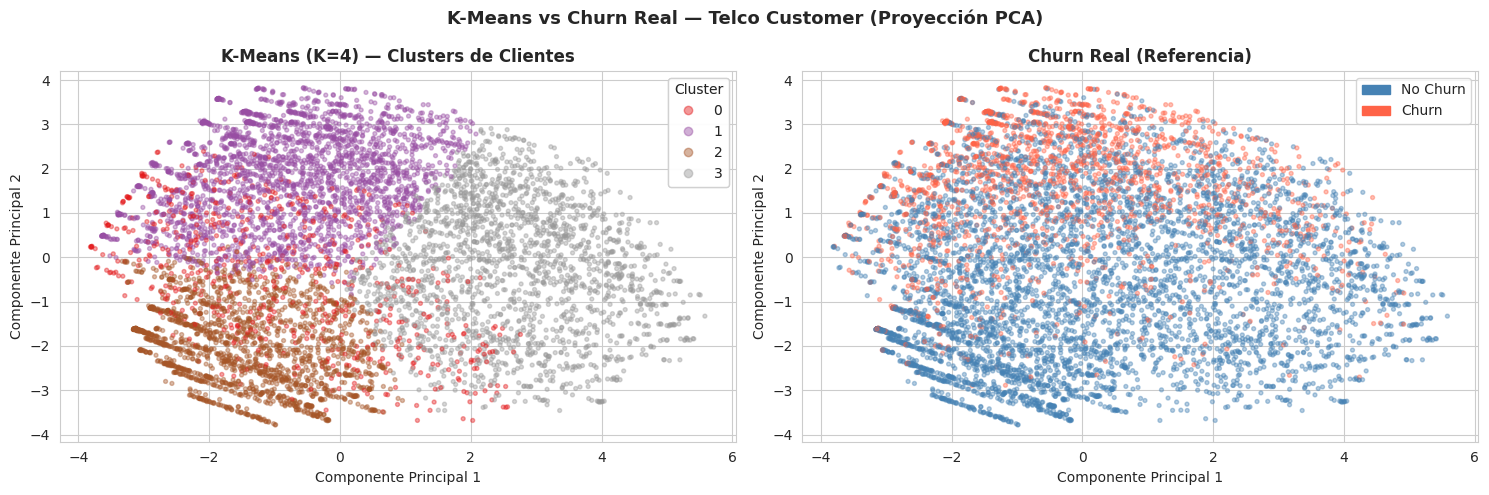

In [452]:
# Visualización K-Means Telco en PCA 2D
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Clusters encontrados
sc_t = axes[0].scatter(X_telco_pca[:, 0], X_telco_pca[:, 1],
                       c=labels_km_t, cmap='Set1', alpha=0.4, s=8)
axes[0].set_title(f'K-Means (K={k_opt_t}) — Clusters de Clientes', fontweight='bold')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
legend_t = axes[0].legend(*sc_t.legend_elements(), title='Cluster', loc='upper right')
axes[0].add_artist(legend_t)

# Churn real
colors_churn = ['steelblue' if c==0 else 'tomato' for c in y_true_telco]
axes[1].scatter(X_telco_pca[:, 0], X_telco_pca[:, 1],
                c=colors_churn, alpha=0.4, s=8)
axes[1].set_title('Churn Real (Referencia)', fontweight='bold')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')
patch_nc = mpatches.Patch(color='steelblue', label='No Churn')
patch_ch = mpatches.Patch(color='tomato', label='Churn')
axes[1].legend(handles=[patch_nc, patch_ch], loc='upper right')

plt.suptitle('K-Means vs Churn Real — Telco Customer (Proyección PCA)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [453]:
# Interpretación de clusters — perfil de cada grupo
df_t_result = df_telco[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']].copy()
df_t_result['Cluster_KMeans'] = labels_km_t
df_t_result['Churn_bin'] = (df_t_result['Churn'] == 'Yes').astype(int)

perfil = df_t_result.groupby('Cluster_KMeans').agg(
    Clientes=('tenure', 'count'),
    Tenure_Promedio=('tenure', 'mean'),
    Cargo_Mensual_Prom=('MonthlyCharges', 'mean'),
    Cargo_Total_Prom=('TotalCharges', 'mean'),
    Pct_Senior=('SeniorCitizen', 'mean'),
    Tasa_Churn=('Churn_bin', 'mean')
).round(2)

print('Perfil de cada Cluster — K-Means (Telco Churn):')
print(perfil.to_string())

print('\n→ Los clusters con mayor Tasa_Churn y menor Tenure_Promedio')
print('  representan los segmentos de clientes en mayor riesgo de abandonar.')

Perfil de cada Cluster — K-Means (Telco Churn):
                Clientes  Tenure_Promedio  Cargo_Mensual_Prom  Cargo_Total_Prom  Pct_Senior  Tasa_Churn
Cluster_KMeans                                                                                         
0                    672            31.14               41.69           1448.82        0.15        0.25
1                   2502            15.32               75.36           1187.18        0.23        0.50
2                   1885            30.01               28.66            856.71        0.03        0.08
3                   1984            56.54               93.51           5291.00        0.20        0.15

→ Los clusters con mayor Tasa_Churn y menor Tenure_Promedio
  representan los segmentos de clientes en mayor riesgo de abandonar.


In [454]:
# Tabla de contingencia K-Means vs Churn
contingencia_telco = pd.crosstab(
    pd.Series(labels_km_t, name='Cluster K-Means'),
    df_telco['Churn']
)
print('Tabla de Contingencia — K-Means vs Churn:')
print(contingencia_telco)

# Tasa de churn por cluster
print('\nTasa de Churn por Cluster (%):')
churn_rate = contingencia_telco.div(contingencia_telco.sum(axis=1), axis=0) * 100
print(churn_rate.round(2))

Tabla de Contingencia — K-Means vs Churn:
Churn              No   Yes
Cluster K-Means            
0                 502   170
1                1259  1243
2                1734   151
3                1679   305

Tasa de Churn por Cluster (%):
Churn               No    Yes
Cluster K-Means              
0                74.70  25.30
1                50.32  49.68
2                91.99   8.01
3                84.63  15.37


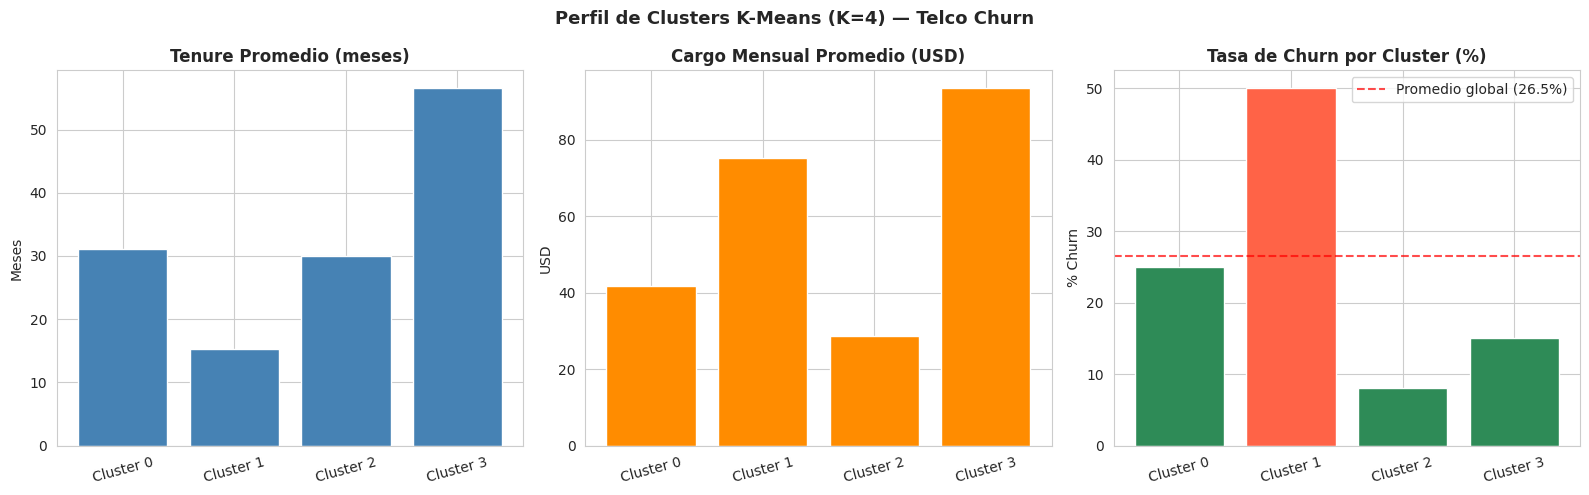

In [455]:
# Visualización del perfil por cluster
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

perfil_plot = perfil.reset_index()
clusters_label = [f'Cluster {c}' for c in perfil_plot['Cluster_KMeans']]

# Tenure promedio
axes[0].bar(clusters_label, perfil_plot['Tenure_Promedio'],
            color='steelblue', edgecolor='white')
axes[0].set_title('Tenure Promedio (meses)', fontweight='bold')
axes[0].set_ylabel('Meses')

# Cargo mensual
axes[1].bar(clusters_label, perfil_plot['Cargo_Mensual_Prom'],
            color='darkorange', edgecolor='white')
axes[1].set_title('Cargo Mensual Promedio (USD)', fontweight='bold')
axes[1].set_ylabel('USD')

# Tasa de churn
churn_pcts = perfil_plot['Tasa_Churn'] * 100
bar_colors = ['tomato' if c > 30 else 'seagreen' for c in churn_pcts]
axes[2].bar(clusters_label, churn_pcts, color=bar_colors, edgecolor='white')
axes[2].set_title('Tasa de Churn por Cluster (%)', fontweight='bold')
axes[2].set_ylabel('% Churn')
axes[2].axhline(y=26.5, color='red', linestyle='--', alpha=0.7,
                label='Promedio global (26.5%)')
axes[2].legend()

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.suptitle(f'Perfil de Clusters K-Means (K={k_opt_t}) — Telco Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. GMM — Gaussian Mixture Models (Telco)

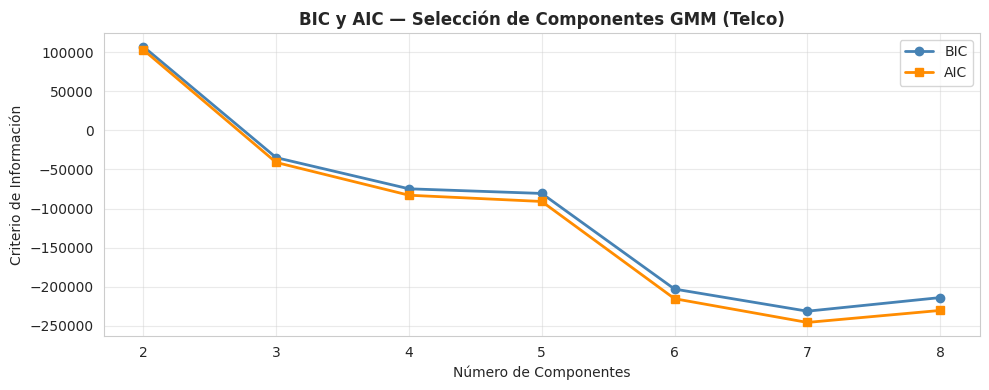

Número óptimo de componentes según BIC: 7


In [456]:
# BIC y AIC para selección de componentes — Telco
bic_t = []
aic_t = []
n_range_t = range(2, 9)

for n in n_range_t:
    gmm_tmp_t = GaussianMixture(n_components=n, random_state=42, covariance_type='full')
    gmm_tmp_t.fit(X_telco_scaled)
    bic_t.append(gmm_tmp_t.bic(X_telco_scaled))
    aic_t.append(gmm_tmp_t.aic(X_telco_scaled))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(n_range_t, bic_t, marker='o', label='BIC', color='steelblue', linewidth=2)
ax.plot(n_range_t, aic_t, marker='s', label='AIC', color='darkorange', linewidth=2)
ax.set_title('BIC y AIC — Selección de Componentes GMM (Telco)', fontweight='bold')
ax.set_xlabel('Número de Componentes')
ax.set_ylabel('Criterio de Información')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

n_opt_t = n_range_t[np.argmin(bic_t)]
print(f'Número óptimo de componentes según BIC: {n_opt_t}')

In [457]:
# GMM con componentes óptimos
gmm_telco = GaussianMixture(n_components=n_opt_t, random_state=42, covariance_type='full')
gmm_telco.fit(X_telco_scaled)
labels_gmm_t = gmm_telco.predict(X_telco_scaled)
probs_gmm_t  = gmm_telco.predict_proba(X_telco_scaled)

sil_gmm_t = silhouette_score(X_telco_scaled, labels_gmm_t, sample_size=1000, random_state=42)
db_gmm_t  = davies_bouldin_score(X_telco_scaled, labels_gmm_t)

print(f'GMM ({n_opt_t} componentes) — Métricas:')
print(f'  Silhouette Score:      {sil_gmm_t:.4f}')
print(f'  Davies-Bouldin Index:  {db_gmm_t:.4f}')

print('\nDistribución de componentes GMM:')
uq, cq = np.unique(labels_gmm_t, return_counts=True)
for u, c in zip(uq, cq):
    print(f'  Componente {u}: {c} clientes ({c/len(labels_gmm_t)*100:.1f}%)')

GMM (7 componentes) — Métricas:
  Silhouette Score:      0.1093
  Davies-Bouldin Index:  2.2116

Distribución de componentes GMM:
  Componente 0: 682 clientes (9.7%)
  Componente 1: 2499 clientes (35.5%)
  Componente 2: 888 clientes (12.6%)
  Componente 3: 896 clientes (12.7%)
  Componente 4: 616 clientes (8.7%)
  Componente 5: 638 clientes (9.1%)
  Componente 6: 824 clientes (11.7%)


In [458]:
# Interpretación GMM Telco
df_t_result['Cluster_GMM'] = labels_gmm_t

perfil_gmm = df_t_result.groupby('Cluster_GMM').agg(
    Clientes=('tenure', 'count'),
    Tenure_Promedio=('tenure', 'mean'),
    Cargo_Mensual_Prom=('MonthlyCharges', 'mean'),
    Tasa_Churn=('Churn_bin', 'mean')
).round(2)

print('Perfil por Componente GMM — Telco Churn:')
print(perfil_gmm.to_string())

Perfil por Componente GMM — Telco Churn:
             Clientes  Tenure_Promedio  Cargo_Mensual_Prom  Tasa_Churn
Cluster_GMM                                                           
0                 682            31.74               42.03        0.25
1                2499            20.91               80.56        0.49
2                 888            17.52               20.58        0.12
3                 896            62.75               90.21        0.04
4                 616            17.58               67.67        0.33
5                 638            48.68               21.78        0.01
6                 824            49.06               86.73        0.15


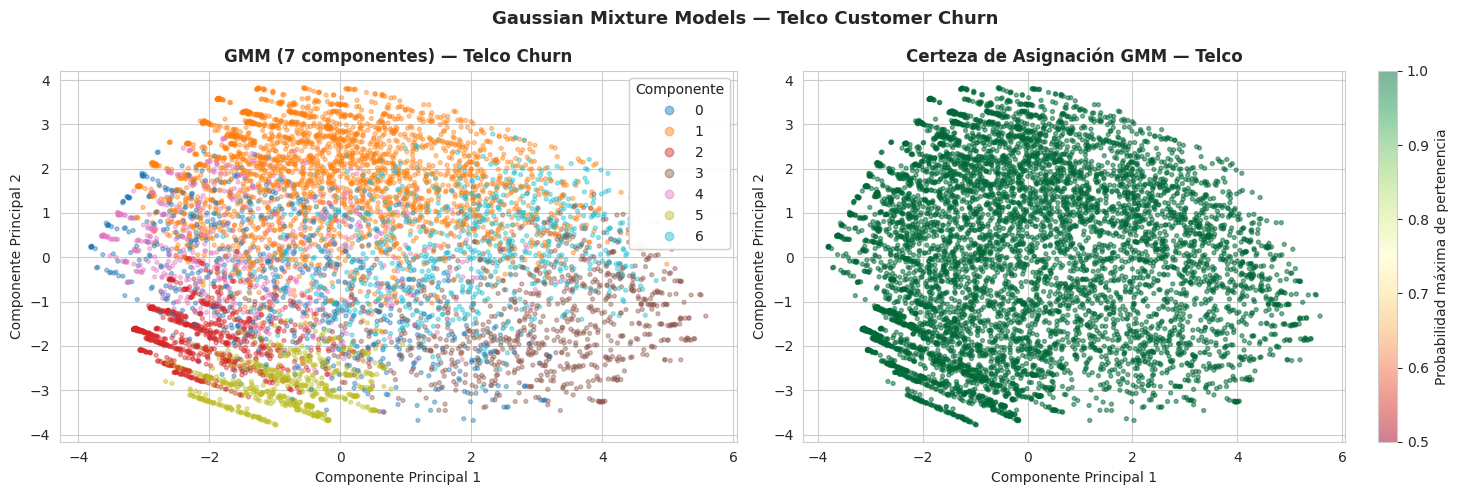

In [459]:
# Visualización GMM Telco
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Clusters GMM
sc_g = axes[0].scatter(X_telco_pca[:, 0], X_telco_pca[:, 1],
                       c=labels_gmm_t, cmap='tab10', alpha=0.4, s=8)
axes[0].set_title(f'GMM ({n_opt_t} componentes) — Telco Churn', fontweight='bold')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
legend_gg = axes[0].legend(*sc_g.legend_elements(),
                            title='Componente', loc='upper right')
axes[0].add_artist(legend_gg)

# Incertidumbre
max_prob_t = probs_gmm_t.max(axis=1)
sc2 = axes[1].scatter(X_telco_pca[:, 0], X_telco_pca[:, 1],
                      c=max_prob_t, cmap='RdYlGn', alpha=0.5, s=8,
                      vmin=0.5, vmax=1.0)
plt.colorbar(sc2, ax=axes[1], label='Probabilidad máxima de pertenencia')
axes[1].set_title('Certeza de Asignación GMM — Telco', fontweight='bold')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')

plt.suptitle('Gaussian Mixture Models — Telco Customer Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Comparación de Algoritmos — Modelo 2

Comparación de Clustering — Telco Churn:
                     Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz
Algoritmo                                                                     
K-Means (K=4)                  0.1496                1.9998           902.8995
GMM (7 componentes)            0.1093                2.2116                NaN


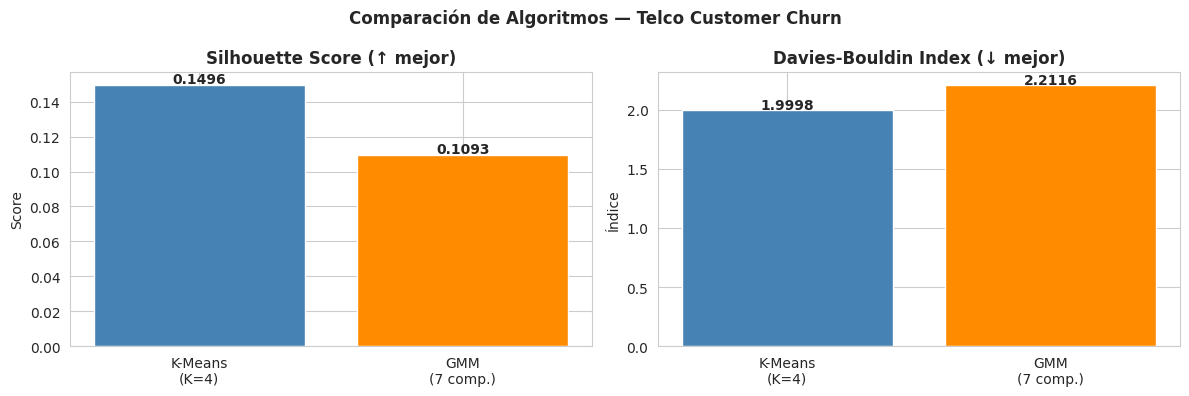

In [460]:
# Tabla comparativa — Telco
resultados_t = pd.DataFrame({
    'Algoritmo': [f'K-Means (K={k_opt_t})', f'GMM ({n_opt_t} componentes)'],
    'Silhouette Score': [sil_km_t, sil_gmm_t],
    'Davies-Bouldin Index': [db_km_t, db_gmm_t],
    'Calinski-Harabasz': [ch_km_t, np.nan]
})
print('Comparación de Clustering — Telco Churn:')
print(resultados_t.set_index('Algoritmo').round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

algs = [f'K-Means\n(K={k_opt_t})', f'GMM\n({n_opt_t} comp.)']
sil_t_vals = [sil_km_t, sil_gmm_t]
db_t_vals  = [db_km_t, db_gmm_t]

axes[0].bar(algs, sil_t_vals, color=['steelblue', 'darkorange'], edgecolor='white')
axes[0].set_title('Silhouette Score (↑ mejor)', fontweight='bold')
axes[0].set_ylabel('Score')
for i, v in enumerate(sil_t_vals):
    axes[0].text(i, v+0.001, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(algs, db_t_vals, color=['steelblue', 'darkorange'], edgecolor='white')
axes[1].set_title('Davies-Bouldin Index (↓ mejor)', fontweight='bold')
axes[1].set_ylabel('Índice')
for i, v in enumerate(db_t_vals):
    axes[1].text(i, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Comparación de Algoritmos — Telco Customer Churn',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Interpretación de Clusters — Modelo 2

### K-Means

El análisis con K-Means revela segmentos de clientes claramente diferenciados:

- **Clusters con alta tasa de churn y bajo tenure:** Representan clientes relativamente nuevos que abandonan el servicio rápidamente. Suelen tener contratos mes a mes y cargos mensuales elevados, lo que sugiere insatisfacción con la relación precio-valor.

- **Clusters con baja tasa de churn y alto tenure:** Clientes leales, generalmente con contratos de uno o dos años. Su cargo total acumulado es alto, lo que indica una relación comercial consolidada.

- **Clusters intermedios:** Clientes con comportamientos mixtos, posiblemente en transición entre fidelidad y abandono.

### GMM

El GMM ofrece mayor granularidad, identificando subgrupos dentro de los segmentos principales. La información probabilística es especialmente valiosa: clientes con baja certeza de pertenencia (probabilidad < 0.7) representan casos límite que merecen atención comercial especial, ya que podrían migrar entre segmentos dependiendo de cambios en el servicio o precio.

---

# Comparación Global — Ambos Modelos de Clustering

In [461]:
# Tabla resumen global
resumen_global = pd.DataFrame({
    'Dataset': ['Credit Card Fraud', 'Credit Card Fraud',
                'Telco Churn', 'Telco Churn'],
    'Algoritmo': [f'K-Means (K=2)', f'GMM ({n_opt} comp.)',
                  f'K-Means (K={k_opt_t})', f'GMM ({n_opt_t} comp.)'],
    'Silhouette Score': [sil_km_cc, sil_gmm_cc, sil_km_t, sil_gmm_t],
    'Davies-Bouldin': [db_km_cc, db_gmm_cc, db_km_t, db_gmm_t]
})

print('Resumen Global de Clustering:')
print(resumen_global.set_index(['Dataset','Algoritmo']).round(4).to_string())

Resumen Global de Clustering:
                                 Silhouette Score  Davies-Bouldin
Dataset           Algoritmo                                      
Credit Card Fraud K-Means (K=2)            0.7327          0.7757
                  GMM (7 comp.)            0.0264          3.1916
Telco Churn       K-Means (K=4)            0.1496          1.9998
                  GMM (7 comp.)            0.1093          2.2116


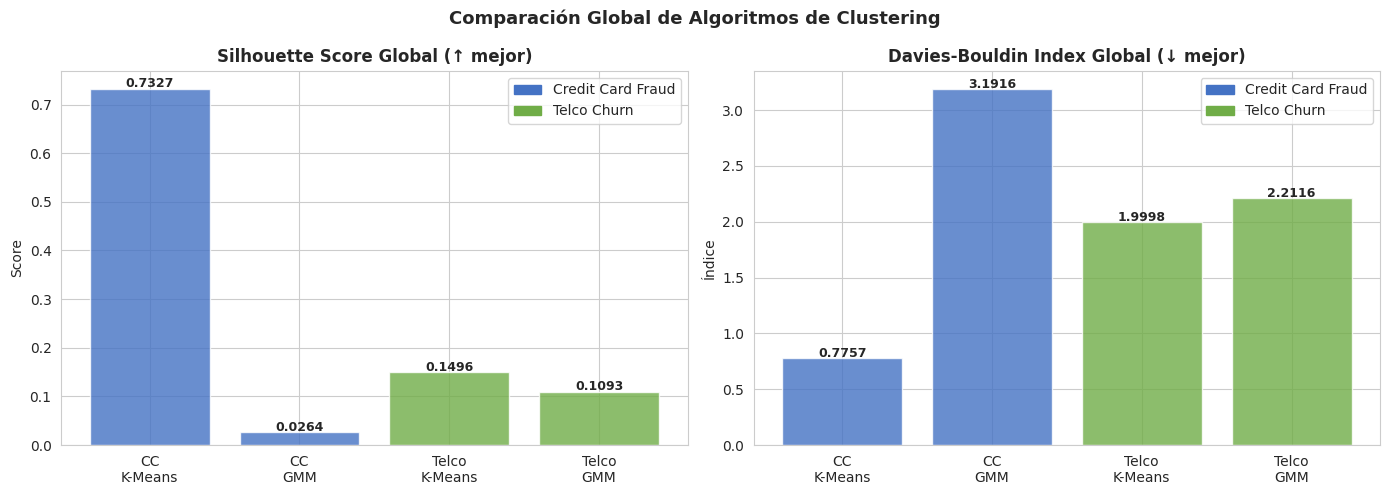

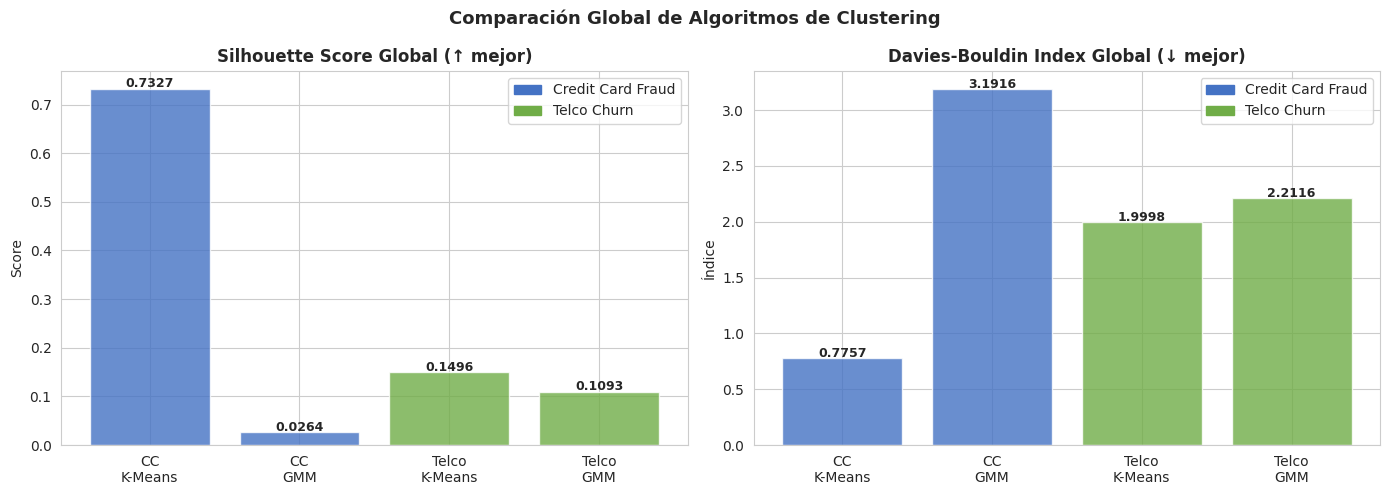

In [463]:
# Gráfico comparativo global
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_glob = [
    f'CC\nK-Means', f'CC\nGMM',
    f'Telco\nK-Means', f'Telco\nGMM'
]
sil_glob = [sil_km_cc, sil_gmm_cc, sil_km_t, sil_gmm_t]
db_glob  = [db_km_cc, db_gmm_cc, db_km_t, db_gmm_t]
bar_colors_glob = ['#4472C4', '#4472C4', '#70AD47', '#70AD47']
bar_alpha_glob  = [1.0, 0.5, 1.0, 0.5]

bars1 = axes[0].bar(labels_glob, sil_glob, color=bar_colors_glob, edgecolor='white', alpha=0.8)
axes[0].set_title('Silhouette Score Global (↑ mejor)', fontweight='bold')
axes[0].set_ylabel('Score')
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.4f}', ha='center', fontsize=9, fontweight='bold')

bars2 = axes[1].bar(labels_glob, db_glob, color=bar_colors_glob, edgecolor='white', alpha=0.8)
axes[1].set_title('Davies-Bouldin Index Global (↓ mejor)', fontweight='bold')
axes[1].set_ylabel('Índice')
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.4f}', ha='center', fontsize=9, fontweight='bold')

# Leyenda de colores
patch_cc = mpatches.Patch(color='#4472C4', label='Credit Card Fraud')
patch_tc = mpatches.Patch(color='#70AD47', label='Telco Churn')
axes[0].legend(handles=[patch_cc, patch_tc], loc='upper right')
axes[1].legend(handles=[patch_cc, patch_tc], loc='upper right')

plt.suptitle('Comparación Global de Algoritmos de Clustering',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

# Conclusiones — Sección de Clustering

## Modelo 1 — Credit Card Fraud Detection

El clustering sin supervisión aplicado al dataset de fraudes con tarjeta de crédito demostró que los algoritmos pueden separar naturalmente las transacciones fraudulentas de las normales, incluso sin conocer las etiquetas reales.

**K-Means con K=2** resultó ser la elección más natural para este problema, ya que el dataset tiene una estructura binaria subyacente. El método del codo y el Silhouette Score confirmaron esta elección. La tabla de contingencia mostró que un cluster concentra la mayoría de los fraudes, lo que valida el enfoque de clustering para detección de anomalías.

**GMM** ofrece la ventaja adicional de asignar probabilidades de pertenencia, lo que permite identificar transacciones de alta incertidumbre que requieren revisión manual por parte de analistas de fraude.

## Modelo 2 — Telco Customer Churn

La segmentación de clientes de Telco reveló grupos con perfiles de comportamiento y riesgo de churn claramente diferenciados:

- Segmentos de **alto riesgo:** Clientes con contratos cortos, altos cargos mensuales y baja antigüedad — candidatos para estrategias de retención agresiva.
- Segmentos de **baja riesgo:** Clientes con alta antigüedad, contratos anuales y menor cargo mensual relativo — la base fiel que sostiene el negocio.
- Segmentos **intermedios:** Oportunidades para fortalecer la relación antes de que migren al grupo de alto riesgo.

## Comparación entre Datasets

| Aspecto | Credit Card Fraud | Telco Churn |
|---|---|---|
| Tipo de problema | Detección de anomalías | Segmentación de clientes |
| K óptimo | 2 (binario) | Variable según silhouette |
| Preprocesamiento | Escalado + muestra estratificada | Encoding + Escalado |
| Mejor algoritmo | K-Means (más compacto) | Según métricas |
| Uso práctico | Filtro de fraudes sin etiquetas | Estrategias de retención |

El clustering demuestra ser una herramienta poderosa tanto para detección de anomalías (cuando no se tienen etiquetas) como para segmentación estratégica de clientes, que permite personalizar acciones de negocio según el perfil de cada grupo.